# DASIT Sreen Figures



In [1]:
import sys
sys.executable


'/home/hcevasco/.conda/envs/analysis_env/bin/python'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import warnings
import os
import functools
import upsetplot
import sklearn
from pathlib import Path
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter
plt.rcParams['figure.dpi'] = 300



warnings.filterwarnings('ignore')
#plt.rc('font', family='Helvetica')
OUTDIR = Path("/net/bmc-lab2/data/lab/sanchezrivera/hcevasco/DASIT/251212San")

# Skew ratios
## Calculate the 90:10 skew ratios
This uses the raw counts to calculate the ratio between the 90th and 10th percentile guides and ideally for in vitro screens this should be < 10 to show there's no massive shift in one direction 

In [3]:
def compute_skew_df(count_df, condition_label):
    """
    count_df: dataframe with sgRNAs as rows, samples as columns
    condition_label: 'puro' or 'noPuro'
    """
    records = []

    for sample in count_df.columns:
        d = np.sort(count_df[sample].to_numpy())
        ten = int(0.1 * len(d))
        ninety = int(0.9 * len(d))

        skew = d[ninety] / d[ten]

        # extract timepoint from sample name
        timepoint = (
            pd.Series(sample)
            .str.extract("(d0|d5|d15)", expand=False)
            .str.upper()
            .iloc[0]
        )

        records.append({
            "Sample": sample,
            "Timepoint": timepoint,
            "90/10 Skew Ratio": skew,
            "Condition": condition_label
        })

    return pd.DataFrame(records)


In [4]:
puro_counts = pd.read_csv(OUTDIR / "guide_counts_puro.txt", sep="\t")
noPuro_counts = pd.read_csv(OUTDIR / "guide_counts_noPuro.txt", sep="\t")

# drop sgRNA + gene columns
puro_counts = puro_counts.iloc[:, 2:]
noPuro_counts = noPuro_counts.iloc[:, 2:]

puro_skew_df = compute_skew_df(puro_counts, "puro")
noPuro_skew_df = compute_skew_df(noPuro_counts, "noPuro")

skew_df = pd.concat([noPuro_skew_df, puro_skew_df], ignore_index=True)

order = ["D0", "D5", "D15"]


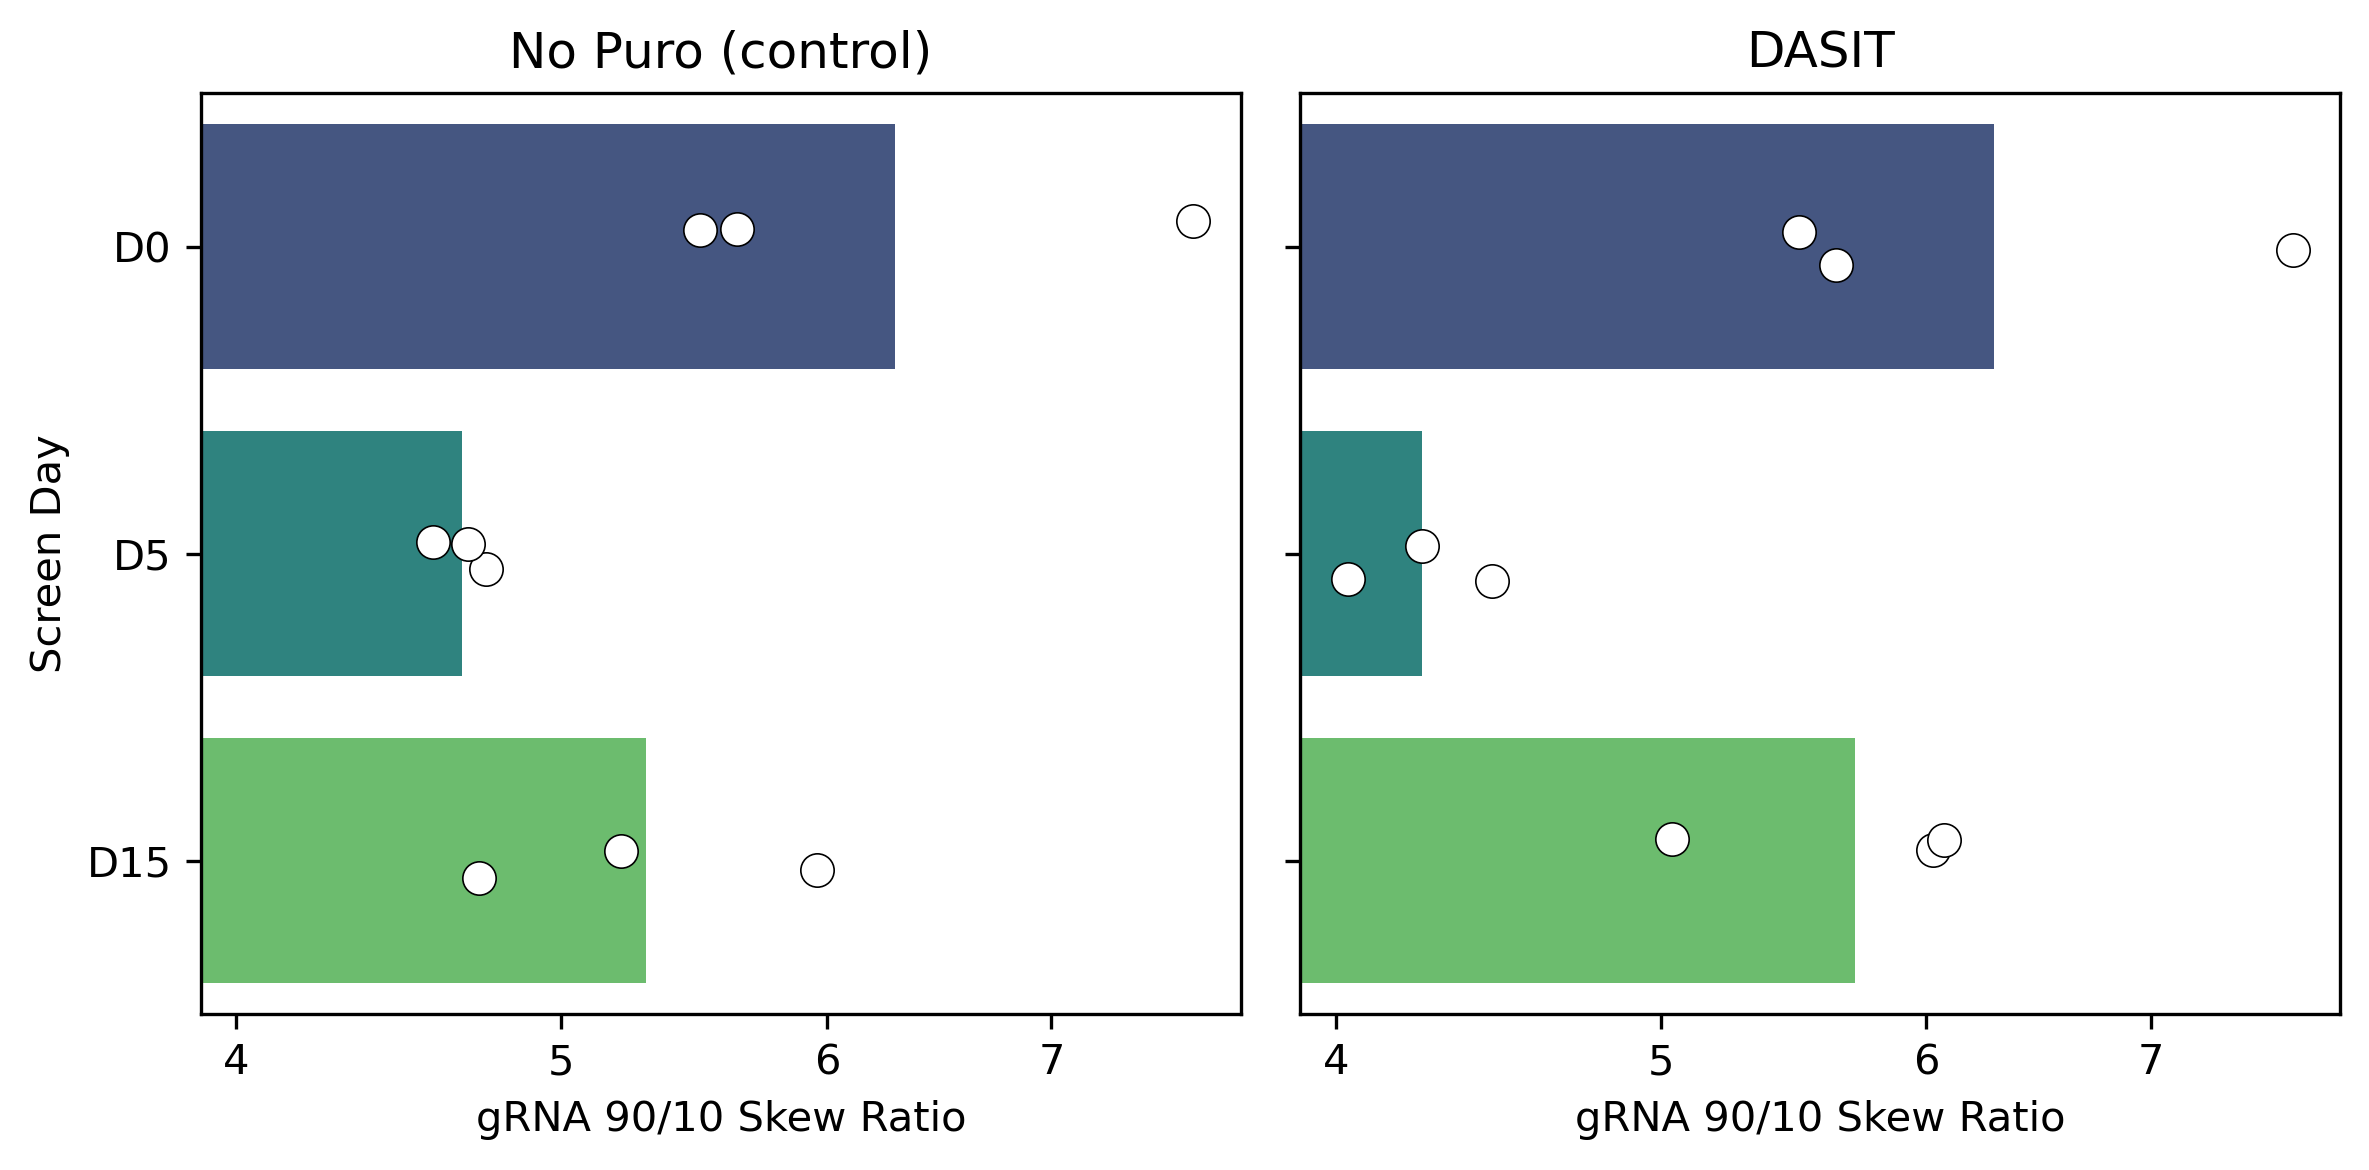

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, sharex=True)
palette = 'viridis'


sns.barplot(
    data=skew_df[skew_df.Condition == "noPuro"],
    y="Timepoint",
    x="90/10 Skew Ratio",
    order=order,
    ax=ax[0],
    palette=palette,
    ci=None
)

sns.stripplot(
    data=skew_df[skew_df.Condition == "noPuro"],
    y="Timepoint",
    x="90/10 Skew Ratio",
    order=order,
    ax=ax[0],
    color='white',
    edgecolor='black',
    linewidth=0.4,
    size=8
)

sns.barplot(
    data=skew_df[skew_df.Condition == "puro"],
    y="Timepoint",
    x="90/10 Skew Ratio",
    order=order,
    ax=ax[1],
    palette=palette,
    ci=None
)

sns.stripplot(
    data=skew_df[skew_df.Condition == "puro"],
    y="Timepoint",
    x="90/10 Skew Ratio",
    order=order,
    ax=ax[1],
    color='white',
    edgecolor='black',
    linewidth=0.4,
    size=8
)

for a in ax:
    a.set_xscale("log")
    a.set_xticks([4, 5, 6, 7])
    a.set_xticklabels(["4", "5", "6", "7"])
    a.set_xlabel("gRNA 90/10 Skew Ratio")
    


ax[0].set_title("No Puro (control)")
ax[1].set_title("DASIT")
ax[0].set_ylabel("Screen Day")

fig.tight_layout()


Same data plotted below just condensed into one graph

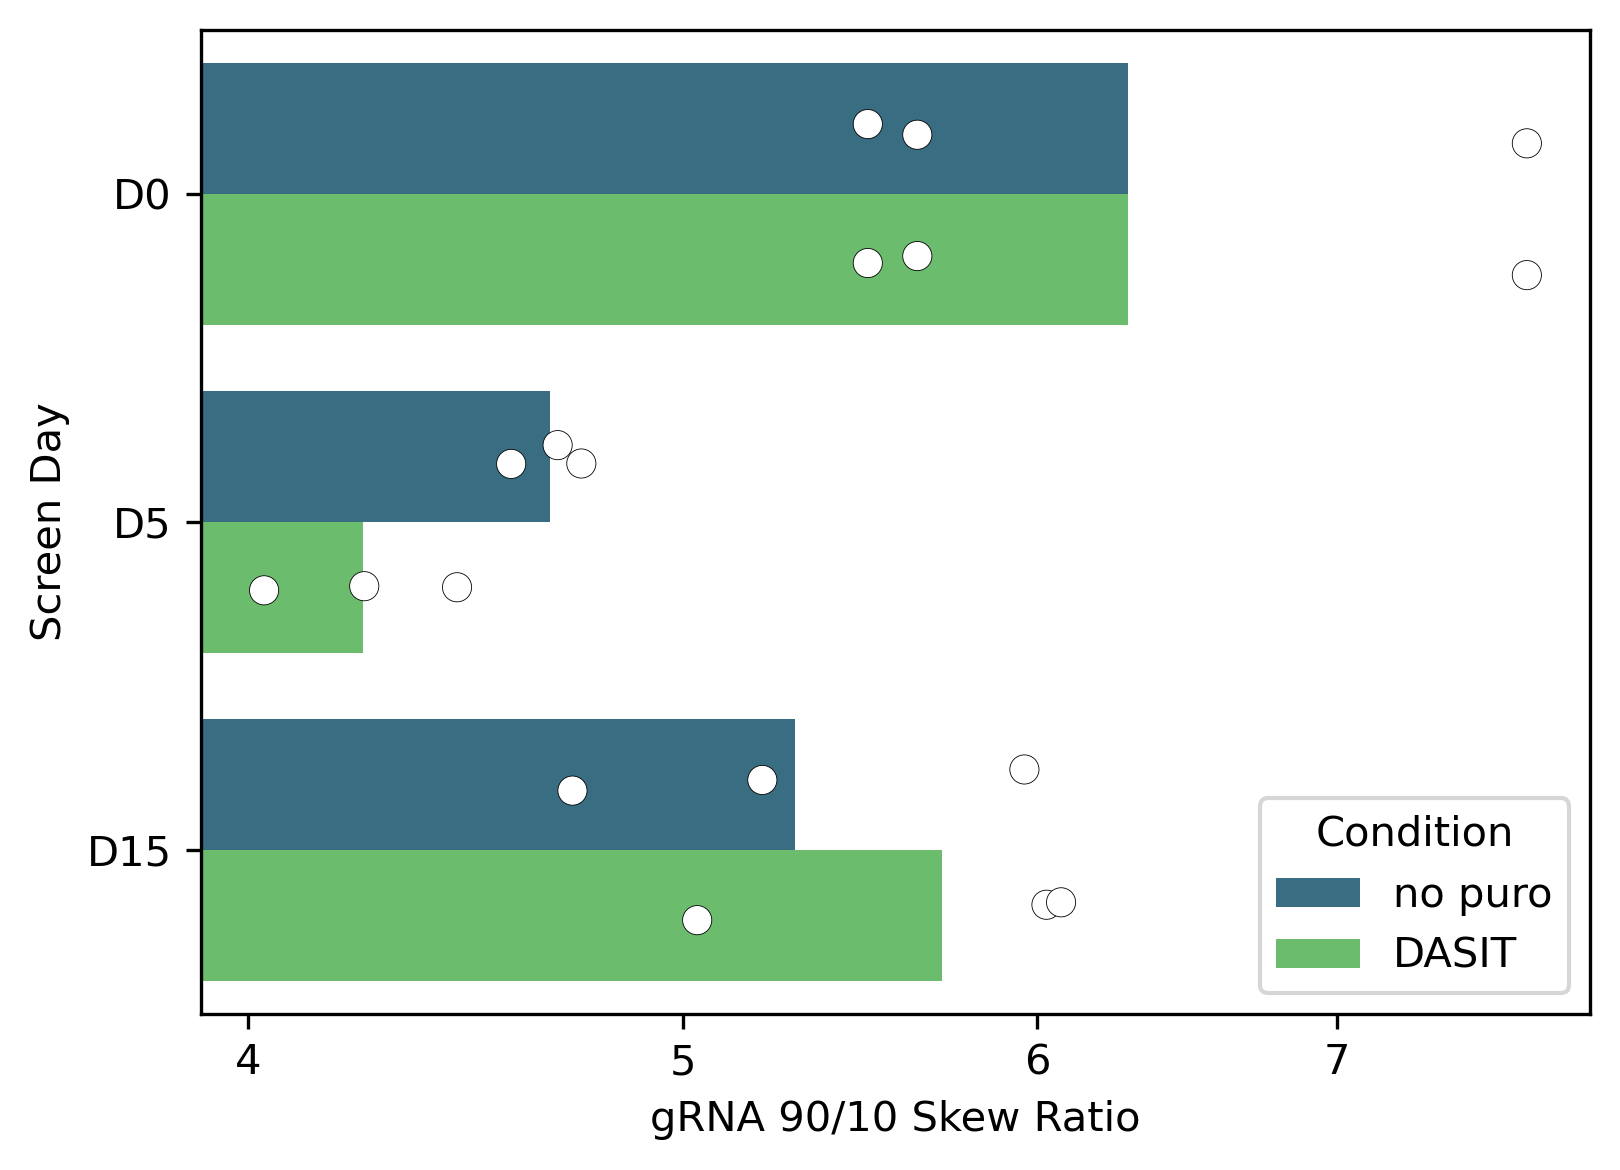

In [6]:

fig, ax = plt.subplots(figsize=(5.5, 4))
palette = sns.color_palette("viridis", 7)
colors = [palette[2], palette[5]] 


sns.barplot(
    data=skew_df,
    y="Timepoint",
    x="90/10 Skew Ratio",
    hue="Condition",
    order=order,
    palette=colors,
    ci=None,
    ax=ax
)

sns.stripplot(
    data=skew_df,
    y="Timepoint",
    x="90/10 Skew Ratio",
    hue="Condition",
    order=order,
    dodge=True,
    palette = ["white", "white"],
    edgecolor="black",
    linewidth=0.2,
    size=7,
    legend=False,
    ax=ax
)

# clean up duplicated legends from bar + strip
handles, labels = ax.get_legend_handles_labels()

label_map = {
    "noPuro": "no puro",
    "puro": "DASIT"
}

new_labels = [label_map[l] for l in labels]

ax.legend(handles, new_labels, title="Condition")

# axis formatting
ax.set_xscale("log")
ax.set_xticks([4, 5, 6, 7])
ax.set_xticklabels(["4", "5", "6", "7"])
ax.set_xlabel("gRNA 90/10 Skew Ratio")
ax.set_ylabel("Screen Day")

#ax.set_title("Library representation skew over time")
#ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()


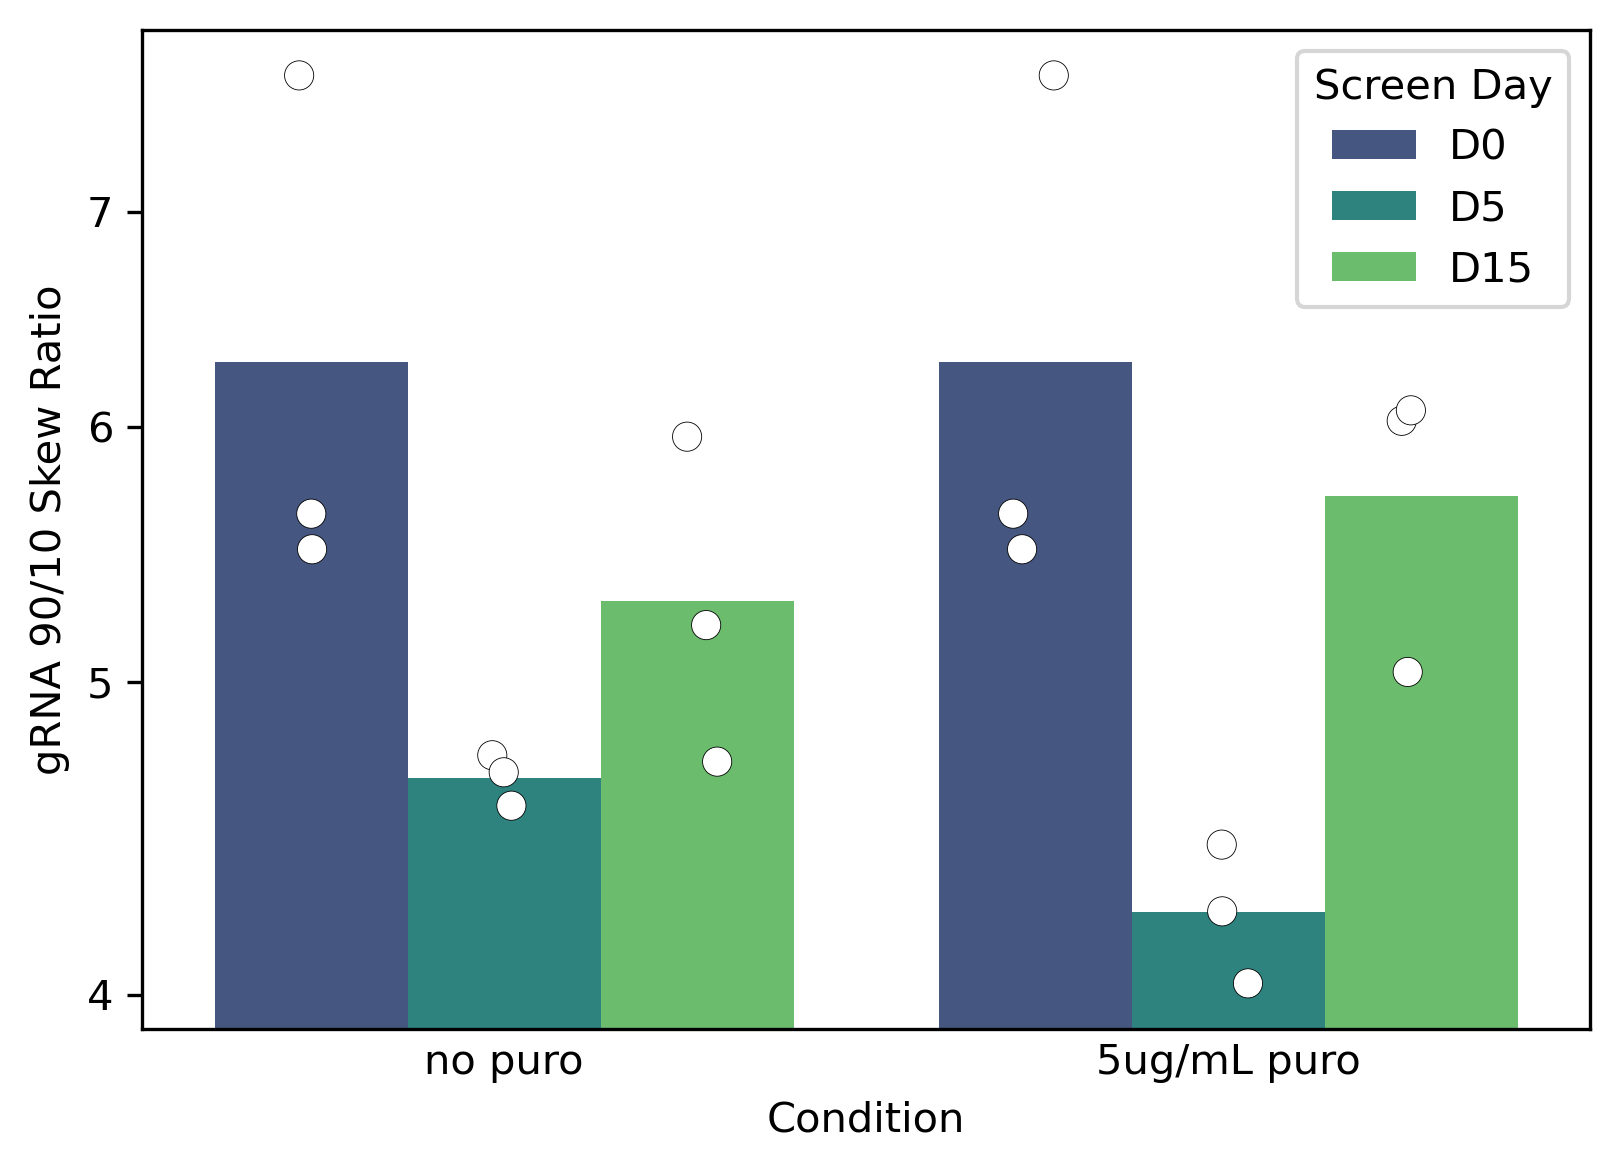

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4))

# viridis colors for timepoints
palette = sns.color_palette("viridis", 7)
timepoint_palette = {
    "D0": palette[1],
    "D5": palette[3],
    "D15": palette[5],
}

# ---- BARPLOT ----
sns.barplot(
    data=skew_df,
    x="Condition",
    y="90/10 Skew Ratio",
    hue="Timepoint",
    hue_order=["D0", "D5", "D15"],
    palette=timepoint_palette,
    ci=None,
    ax=ax
)

# ---- STRIPPLOT (replicates) ----
sns.stripplot(
    data=skew_df,
    x="Condition",
    y="90/10 Skew Ratio",
    hue="Timepoint",
    hue_order=["D0", "D5", "D15"],
    dodge=True,
    palette=["white"] * 3,
    edgecolor="black",
    linewidth=0.2,
    size=7,
    legend=False,
    ax=ax
)

# ---- LEGEND (clean, single) ----
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:3],
    labels[:3],
    title="Screen Day",
    frameon=True
)

# ---- AXIS FORMATTING ----
ax.set_yscale("log")
ax.set_yticks([4, 5, 6, 7])
ax.set_yticklabels(["4", "5", "6", "7"])

ax.set_ylabel("gRNA 90/10 Skew Ratio")
ax.set_xlabel("Condition")
ax.tick_params(axis="x", length=0)

label_map = {
    "noPuro": "no puro",
    "puro": "5ug/mL puro"
}
ax.set_xticklabels([label_map[t.get_text()] for t in ax.get_xticklabels()])

#ax.set_title("Library representation skew over time")
#ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()


KeyError: 'noPuro_D0'

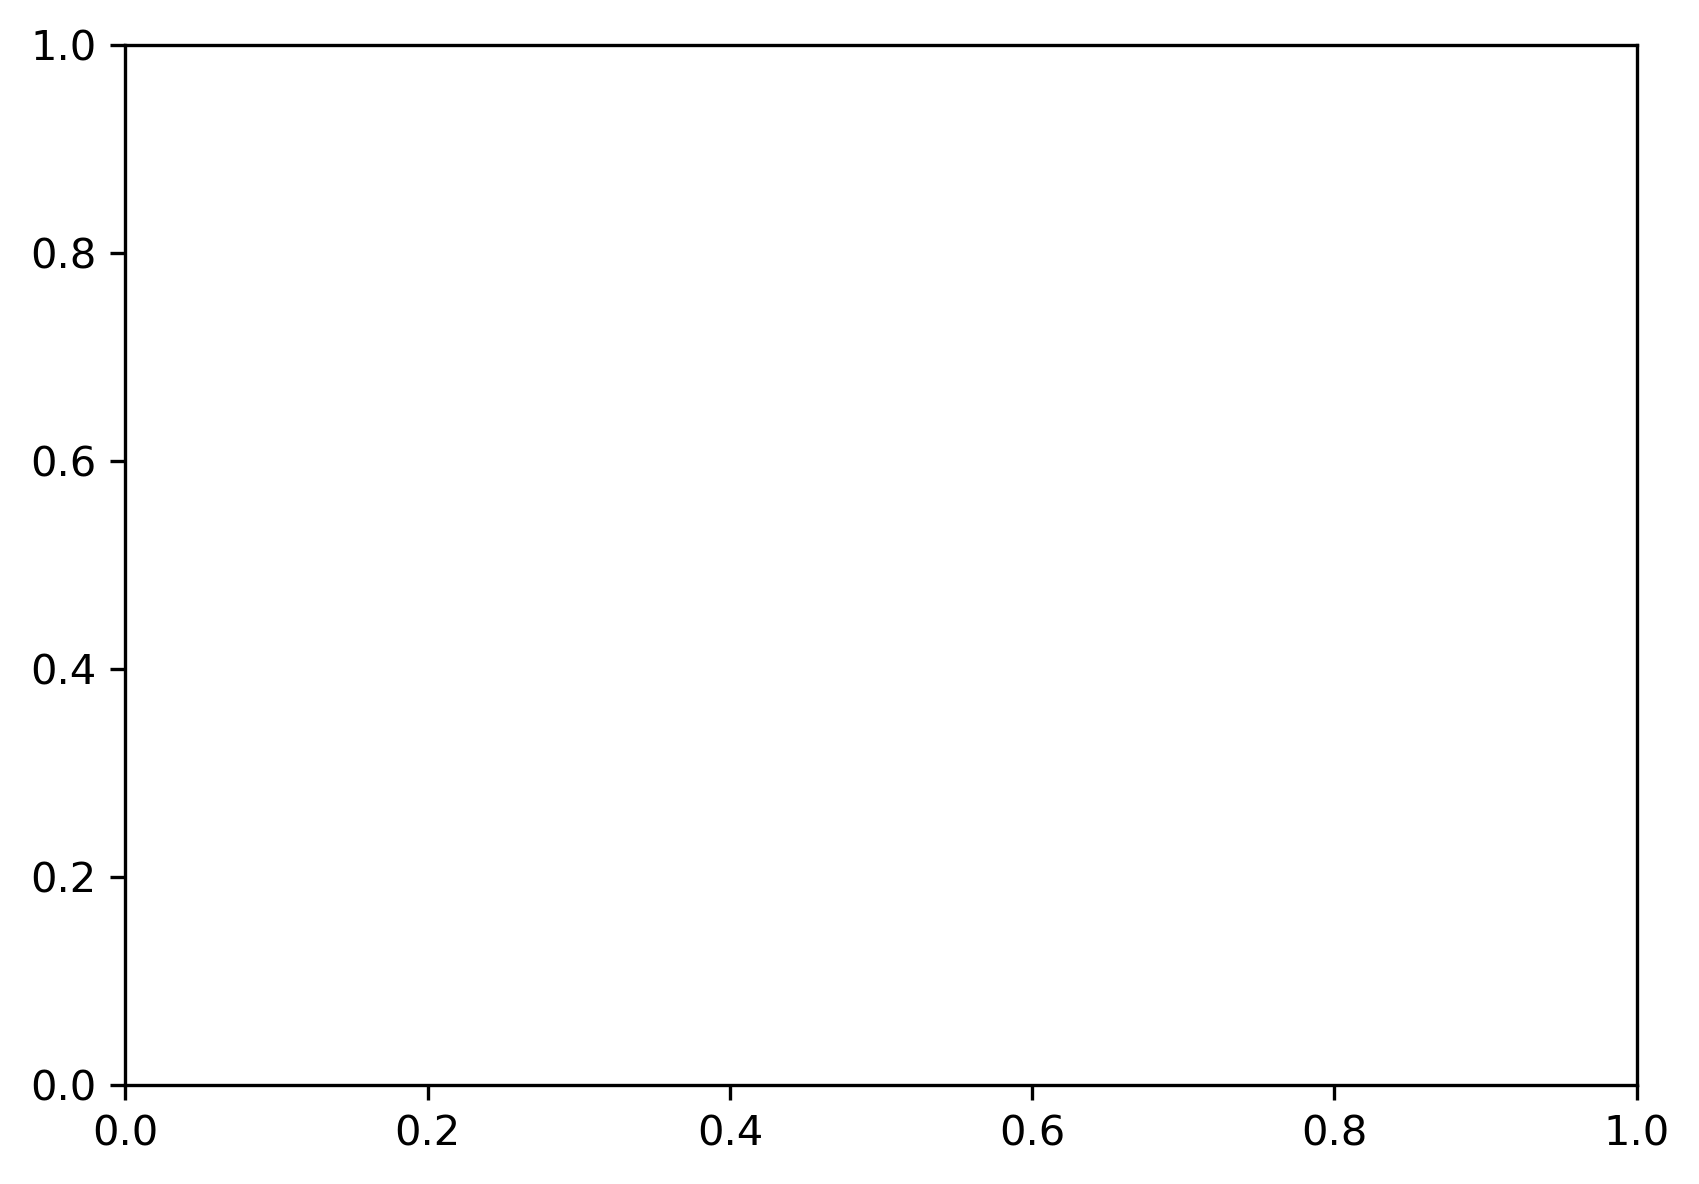

In [8]:
import matplotlib.cm as cm

# -----------------------------
# Assumes plot_df already exists with columns:
# ["PlotGroup", "90/10 Skew Ratio"]
#
# PlotGroup values:
#   "D0"
#   "noPuro_D5", "puro_D5"
#   "noPuro_D15", "puro_D15"
# -----------------------------

fig, ax = plt.subplots(figsize=(6.5, 4.5))

# -----------------------------
# Color setup (viridis)
# -----------------------------
from matplotlib.colors import to_rgb

def desaturate(color, factor=0.85):
    """
    factor = 1   → original color
    factor < 1   → desaturated (mixed with white)
    """
    r, g, b = to_rgb(color)
    return (
        r * factor + (1 - factor),
        g * factor + (1 - factor),
        b * factor + (1 - factor),
    )
palette = sns.color_palette("viridis", n_colors=4)
vir = cm.get_cmap("viridis")
color_map = {
    "D0": "darkgray",
    "noPuro_D5": "#2B5E6F",
    "puro_D5": "#2B5E6F",
    "noPuro_D15": "#5CB25B",
    "puro_D15": "#5CB25B",
}

# -----------------------------
# Custom x positions
#   - D5 bars close together
#   - extra gap before D15
# -----------------------------
x_pos = {
    "D0": 0.0,
    "noPuro_D5": 0.4,
    "puro_D5": 0.7,
    "noPuro_D15": 1.1,
    "puro_D15": 1.4,
}

# -----------------------------
# Split D0 vs non-D0
# -----------------------------
d0_df = skew_df[skew_df["Timepoint"] == "D0"]
non_d0_df = skew_df[skew_df["Timepoint"] != "D0"]

# -----------------------------
# BARPLOT with SD error bars
# -----------------------------
for (cond, tp), subdf in skew_df.groupby(["Condition", "Timepoint"]):

    key = f"{cond}_{tp}"

    ax.bar(
        x_pos[key],
        subdf["90/10 Skew Ratio"].mean(),
        yerr=subdf["90/10 Skew Ratio"].std(),
        width=0.28,
        color=color_map[cond],
        capsize=6,
        zorder=2
    )

# -----------------------------
# STRIP PLOT (non-D0 only)
# -----------------------------
for group, subdf in non_d0_df.groupby("Timepoint"):
    ax.scatter(
        [x_pos[group]] * len(subdf),
        subdf["90/10 Skew Ratio"],
        s=90,
        facecolors="white",
        edgecolors="black",
        linewidth=0.4,
        zorder=3
    )

# -----------------------------
# D0 STRIP POINTS (once only)
# -----------------------------
ax.scatter(
    [x_pos["D0"]] * len(d0_df),
    d0_df["90/10 Skew Ratio"],
    s=90,
    facecolors="white",
    edgecolors="black",
    linewidth=0.6,
    zorder=3
)

# -----------------------------
# Axis formatting
# -----------------------------
ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels([
    "D0",
    "no puro\nD5",
    "5 µg/mL puro\nD5",
    "no puro\nD15",
    "5 µg/mL puro\nD15",
])

ax.set_ylabel("gRNA 90/10 Skew Ratio")
ax.set_xlabel("")



# Optional y-limits if you want consistency
# ax.set_ylim(4, 8)

fig.tight_layout()
plt.show()


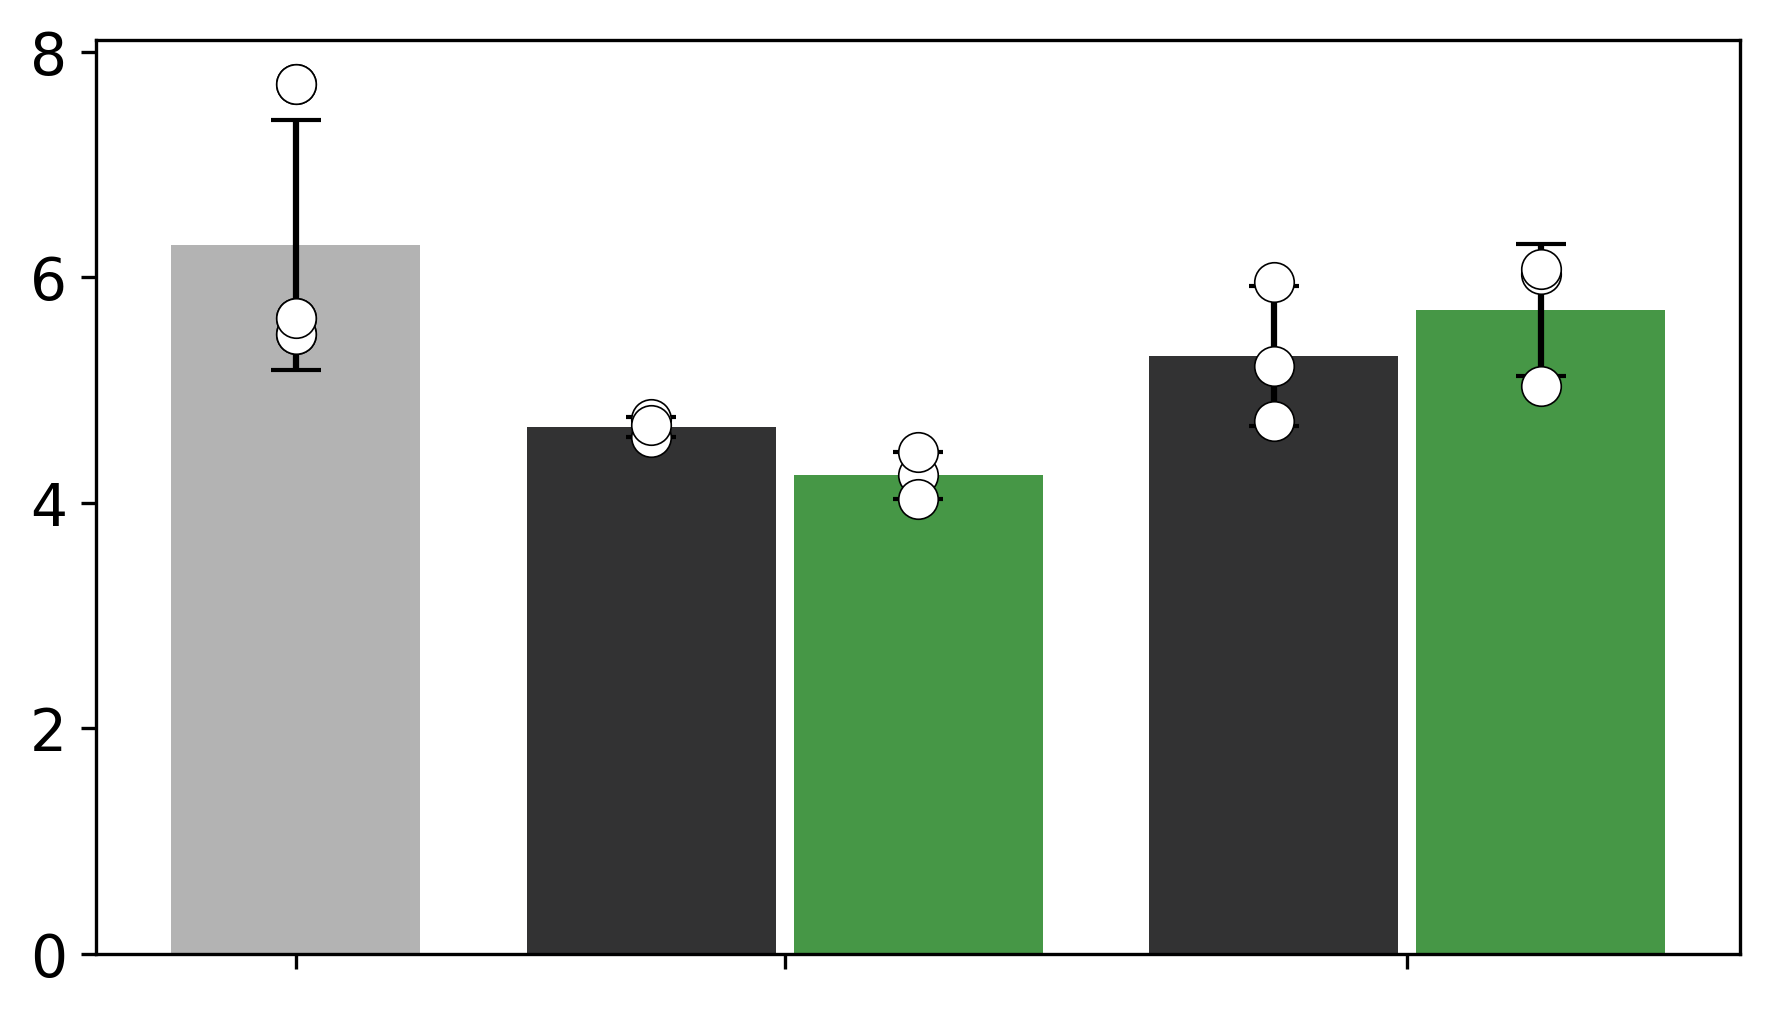

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SPLIT DATA
# -----------------------------
d0_df = skew_df[skew_df["Timepoint"] == "D0"]
post_df = skew_df[skew_df["Timepoint"] != "D0"]

# -----------------------------
# X POSITIONS (explicit + clear)
# -----------------------------
x_pos = {
    "D0": 0.0,
    "noPuro_D5": 0.4,
    "puro_D5": 0.7,
    "noPuro_D15": 1.1,
    "puro_D15": 1.4,
}

# -----------------------------
# COLORS
# -----------------------------
color_map = {
    "noPuro": "#323233",   # gray
    "puro": "#469746",     # green
}

# -----------------------------
# FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 3.5))

# =============================
# D0 BAR (single condition)
# =============================
d0_mean = d0_df["90/10 Skew Ratio"].mean()
d0_sd = d0_df["90/10 Skew Ratio"].std()

ax.bar(
    x_pos["D0"],
    d0_mean,
    yerr=d0_sd,
    width=0.28,
    color="0.7",
    edgecolor="none",
    capsize=6,
    zorder=2
)

ax.scatter(
    np.repeat(x_pos["D0"], len(d0_df)),
    d0_df["90/10 Skew Ratio"],
    s=90,
    facecolors="white",
    edgecolors="black",
    linewidth=0.4,
    zorder=3
)

# =============================
# D5 / D15 BARS (Condition × Timepoint)
# =============================
for (cond, tp), subdf in post_df.groupby(["Condition", "Timepoint"]):

    key = f"{cond}_{tp}"

    mean = subdf["90/10 Skew Ratio"].mean()
    sd = subdf["90/10 Skew Ratio"].std()

    ax.bar(
        x_pos[key],
        mean,
        yerr=sd,
        width=0.28,
        color=color_map[cond],
        edgecolor="none",
        capsize=6,
        zorder=2
    )

    ax.scatter(
        np.repeat(x_pos[key], len(subdf)),
        subdf["90/10 Skew Ratio"],
        s=90,
        facecolors="white",
        edgecolors="black",
        linewidth=0.4,
        zorder=3
    )

# -----------------------------
# AXES / LABELS
# -----------------------------
#ax.set_ylabel("gRNA 90/10 Skew Ratio")
ax.set_ylim(0, None)

ax.set_xticks([
    x_pos["D0"],
    np.mean([x_pos["noPuro_D5"], x_pos["puro_D5"]]),
    np.mean([x_pos["noPuro_D15"], x_pos["puro_D15"]]),
])
ax.tick_params(axis='y', labelsize = 14)
ax.set_xticklabels(["", "", ""])



plt.tight_layout()
plt.show()

# Guide distribution
## What was the distribution of the guides in the noPuro vs DASIT conditions at D5 just based on the counts?
Do a correlation between the RPM guide counts using a spearman correlation 

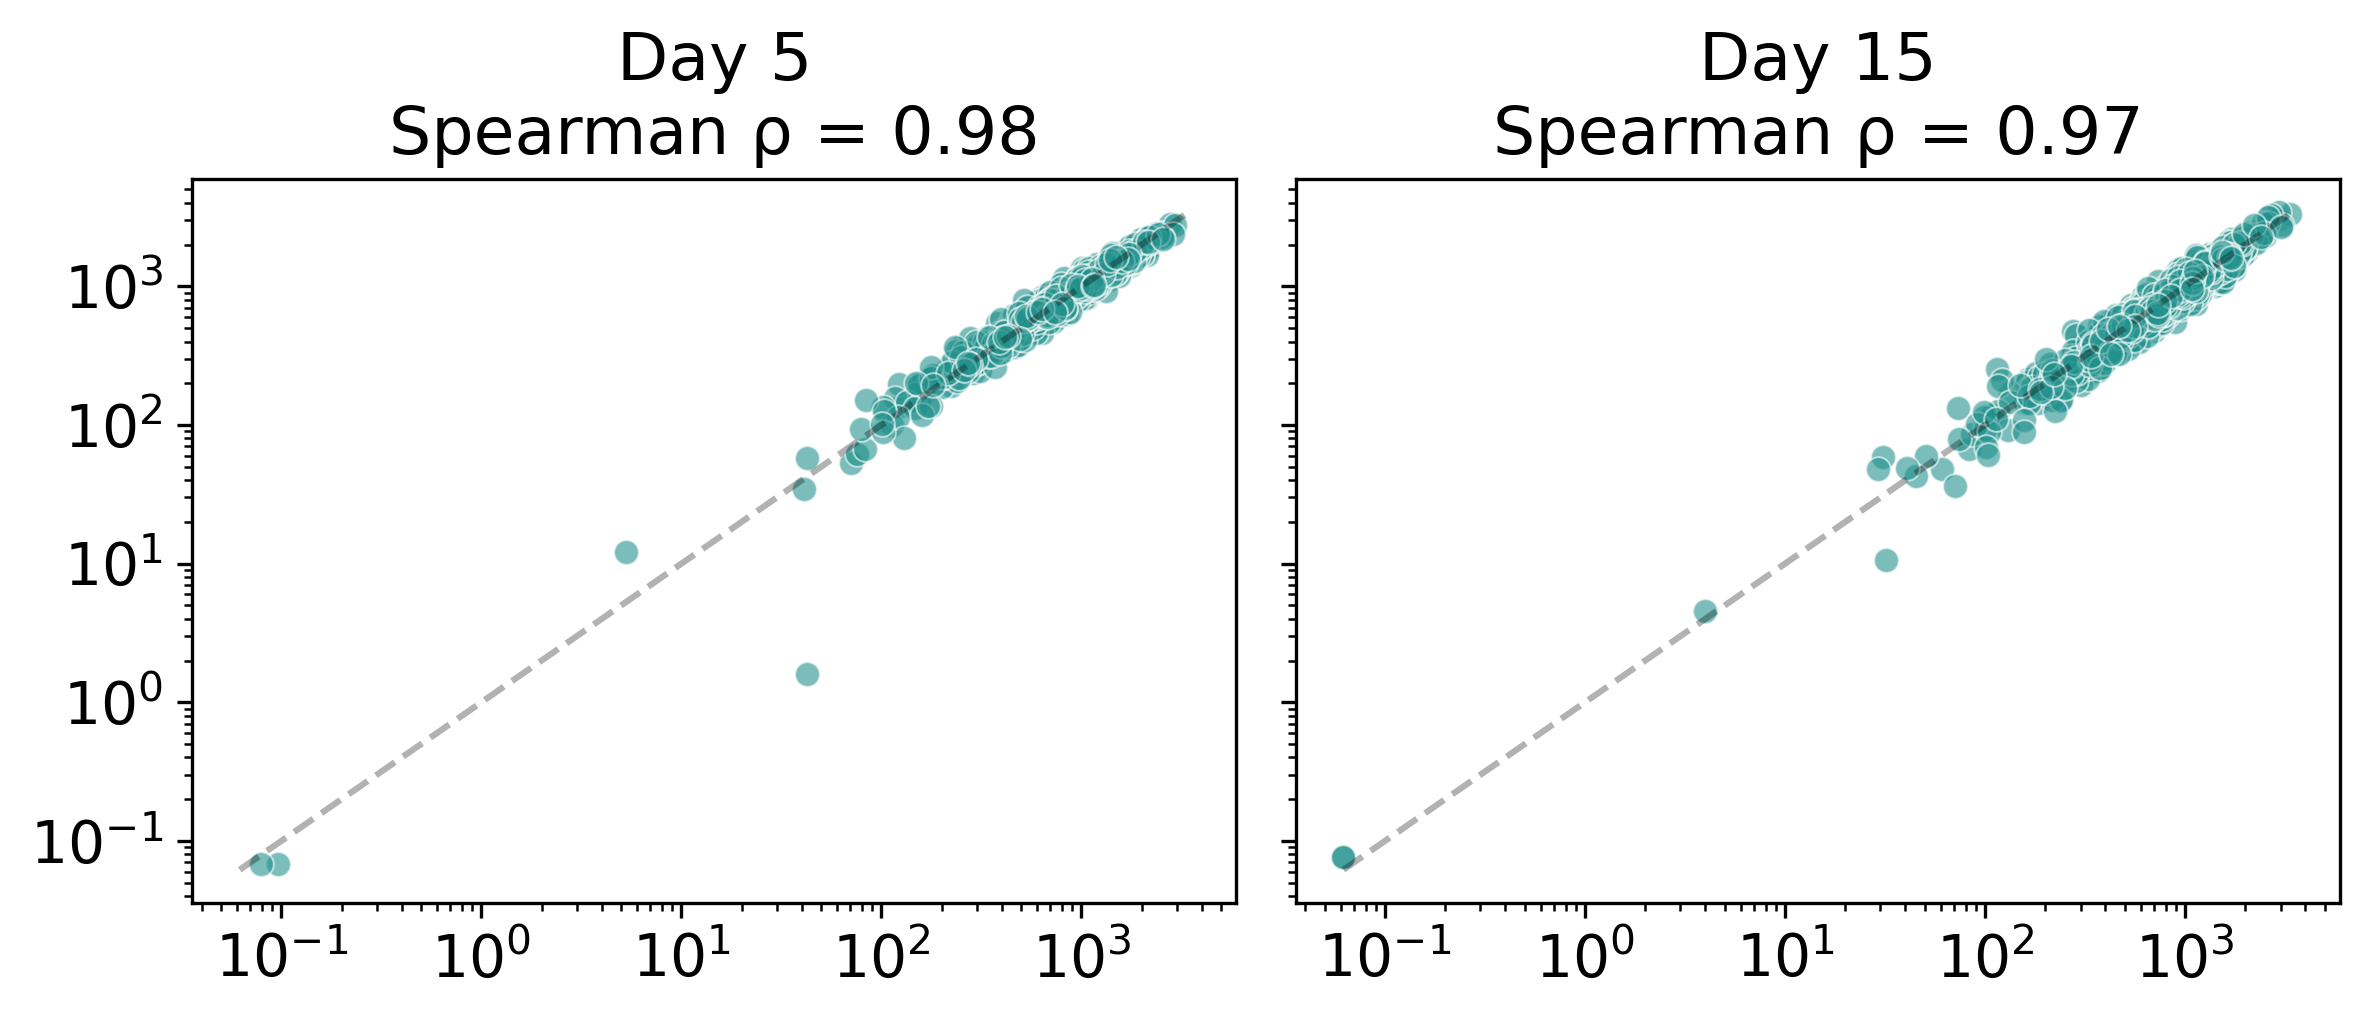

In [21]:
noPuro = pd.read_csv(OUTDIR / "noPuro_RPM", sep="\t").set_index("sgRNA")
puro   = pd.read_csv(OUTDIR / "puro_RPM", sep="\t").set_index("sgRNA")

noPuro["d5_mean"]  = noPuro[["d5_rep1","d5_rep2","d5_rep3"]].mean(axis=1)
noPuro["d15_mean"] = noPuro[["d15_rep1","d15_rep2","d15_rep3"]].mean(axis=1)

puro["d5_mean"]  = puro[["d5_rep1","d5_rep2","d5_rep3"]].mean(axis=1)
puro["d15_mean"] = puro[["d15_rep1","d15_rep2","d15_rep3"]].mean(axis=1)

aligned_d5 = pd.DataFrame({
    "noPuro": noPuro["d5_mean"],
    "puro":   puro["d5_mean"],
}).dropna()

aligned_d15 = pd.DataFrame({
    "noPuro": noPuro["d15_mean"],
    "puro":   puro["d15_mean"],
}).dropna()

plot_d5 = aligned_d5[
    (aligned_d5["noPuro"] > 0) &
    (aligned_d5["puro"] > 0)
]

plot_d15 = aligned_d15[
    (aligned_d15["noPuro"] > 0)  
    & (aligned_d15["puro"] > 0)
]

rho_d5, _  = spearmanr(plot_d5["noPuro"], plot_d5["puro"])
rho_d15, _ = spearmanr(plot_d15["noPuro"], plot_d15["puro"])

lims = (
    min(plot_d5.min().min(), plot_d15.min().min()),
    max(plot_d5.max().max(), plot_d15.max().max())
)

plt.rcParams["figure.dpi"] = 300
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharex=True, sharey=True)

# ---- Day 5 ----
sns.scatterplot(
    ax=axes[0],
    x=plot_d5["noPuro"],
    y=plot_d5["puro"],
    s=35,
    color = sns.color_palette("viridis", 1)[0],
    alpha=0.6
)
axes[0].plot(lims, lims, "--", color="black", alpha=0.3)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("")
axes[0].set_title(f"Day 5\nSpearman ρ = {rho_d5:.2f}", fontsize = 16)
axes[0].set_ylabel("DASIT puro mean RPM")
axes[0].tick_params(axis='x', labelsize = 14)
axes[0].tick_params(axis='y', labelsize = 14)

# ---- Day 15 ----
sns.scatterplot(
    ax=axes[1],
    x=plot_d15["noPuro"],
    y=plot_d15["puro"],
    s=35,
    color = sns.color_palette("viridis", 1)[0],
    alpha=0.6
)
axes[1].plot(lims, lims, "--", color="black", alpha=0.3)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("")
axes[1].set_title(f"Day 15\nSpearman ρ = {rho_d15:.2f}", fontsize =16)
axes[1].tick_params(axis='x', labelsize = 14)

#fig.supxlabel("DASIT no puro (control) gRNA mean RPM")
#fig.suptitle(
#    "gRNA RPM correlation between DASIT and control",
#    y=0.97
#)

#removes all axes for AI figure
for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    #ax.set_title("")
    

plt.tight_layout()
plt.show()


# Active editing comparison
## What percentage of the guides have active editing at D5 in DASIT vs noPuro conditions based on target editing thresholds?

The DASIT condition selected for GFP+ cells, so in theory DASIT should have a higher percentage of edited target sensors

In [49]:
noPuro_LFC = pd.read_csv(OUTDIR / "noPuro_LFC_FDR_df.csv")
puro_LFC = pd.read_csv(OUTDIR / "puro_LFC_FDR_df.csv")

thresholds = [80,90,95,98]



In [50]:
def percent_above_threshold(df, thresholds, condition):
    total = len(df)
    records = []

    for t in thresholds:
        pct = (df["target_base_edit_perc"] >= t).sum() / total * 100
        records.append({
            "Threshold": f"{t}%",
            "Percent_guides_above_threshold": pct,
            "Condition": condition
        })
    return pd.DataFrame(records)

In [51]:
noPuro_editing = percent_above_threshold(noPuro_LFC, thresholds, "no puro")
puro_editing = percent_above_threshold(puro_LFC, thresholds, "DASIT")

plot_df = pd.concat([noPuro_editing, puro_editing], ignore_index=True)
plot_df

,Threshold,Percent_guides_above_threshold,Condition
0,80%,23.084112,no puro
1,90%,8.224299,no puro
2,95%,2.056075,no puro
3,98%,0.186916,no puro
4,80%,29.719626,DASIT
5,90%,14.579439,DASIT
6,95%,4.112150,DASIT
7,98%,0.654206,DASIT


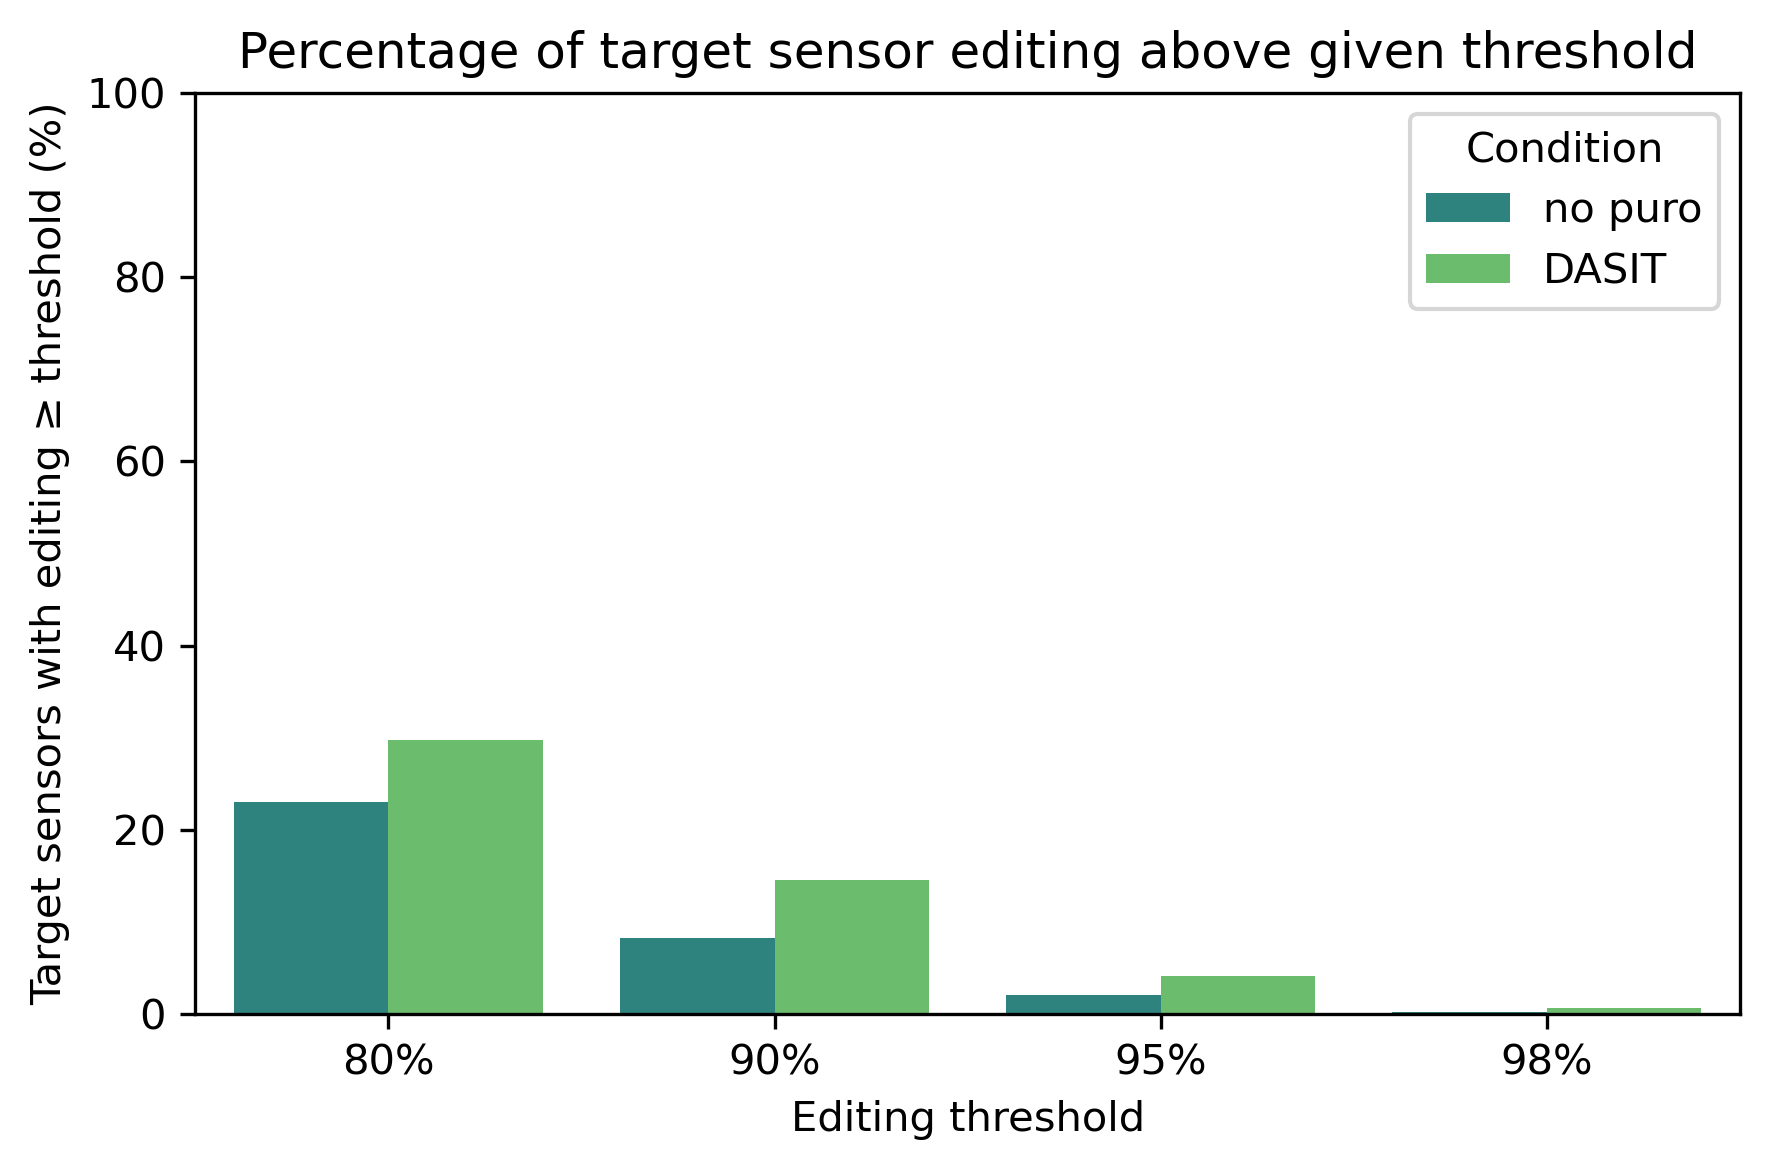

In [52]:
plt.figure(figsize=(6,4))
palette = sns.color_palette("viridis", 7)
colors = [palette[3], palette[5]]  # blue → green
sns.barplot(
    data=plot_df,
    x="Threshold",
    y="Percent_guides_above_threshold",
    hue="Condition",
    palette = colors
    
)

plt.ylabel("Target sensors with editing ≥ threshold (%)")
plt.xlabel("Editing threshold")
plt.title("Percentage of target sensor editing above given threshold")
plt.ylim(0, 100)
plt.legend(title="Condition")
plt.tight_layout()
plt.show()


# LFC comparison
# QUESTION: should the median LFC values also be subsetted according to a certain editing threshold for comparison? 
Compare the median LFC values for each guide in the DASIT vs noPuro conditions at the end of the screen (D15)

In [22]:
puro_LFC = pd.read_csv(OUTDIR / "puro_LFC_FDR_df.csv", sep=',')
noPuro_LFC = pd.read_csv(OUTDIR / "noPuro_LFC_FDR_df.csv", sep=',')


# read in the ABE LFC data
ABE_LFC = pd.read_csv(OUTDIR / "OG_ABEscreen/ABE_LFC_FDR_df.csv", sep=',')
#remove irrelevant samples from the OG screen
exclude_terms = ["meninges", "bonemarrow", "spleen", "plasmid"]
ABE_LFC = ABE_LFC.loc[
    :,
    ~ABE_LFC.columns.str.contains("|".join(exclude_terms), case=False, regex=True)
]

In [23]:
puro_guides   = set(puro_LFC["gRNA_id"])
noPuro_guides = set(noPuro_LFC["gRNA_id"])
abe_guides    = set(ABE_LFC["gRNA_id"])

common_all = puro_guides & noPuro_guides & abe_guides

not_common = {
    "puro_only": puro_guides - (noPuro_guides | abe_guides),
    "noPuro_only": noPuro_guides - (puro_guides | abe_guides),
    "ABE_only": abe_guides - (puro_guides | noPuro_guides),
}

for k, v in not_common.items():
    print(f"\n{k} ({len(v)} guides):")
    for g in sorted(v):
        print(g)


puro_only (0 guides):

noPuro_only (0 guides):

ABE_only (0 guides):


In [24]:
print(ABE_LFC.columns.to_list())
print(puro_LFC.columns.to_list())
print(noPuro_LFC.columns.to_list())

['gRNA_id', 'Gene', 'Input_median', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5', 'p_low_unadjusted_d5', 'FDR_high_d5', 'FDR_low_d5', 'FDR_d5', 'p_high_unadjusted_d15', 'p_low_unadjusted_d15', 'FDR_high_d15', 'FDR_low_d15', 'FDR_d15']
['gRNA_id', 'Gene', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'LFC_avg_d5', 'LFC_median_d5', 'Input_median', 'd15_rep1', 'd15_rep2', 'd15_rep3', 'LFC_avg_d15', 'LFC_median_d15', 'sensor_reads', 'corr_perc', 'target_base_edit_perc', 'byproduct_INDEL_perc', 'byproduct_sub_perc', 'gene_name_m_corrected', 'gene_name_h', 'HGVSp_m', 'HGVSp_h', 'classification', 'classification_m', 'p_high_unadjusted_d5', 'p_low_unadjusted_d5', 'FDR_high_d5', 'FDR_low_d5', 'FDR_d5',

In [25]:
puro    = puro_LFC.set_index("gRNA_id")
noPuro  = noPuro_LFC.set_index("gRNA_id")
abe     = ABE_LFC.set_index("gRNA_id")

# align all on the same gRNAs
puro, noPuro = puro.align(noPuro, join="inner", axis=0)
puro, abe    = puro.align(abe, join="inner", axis=0)

In [37]:
def plot_corr(ax, x, y, xlabel, ylabel, title):
    rho = x.corr(y, method="spearman")

    color = sns.color_palette("viridis", 1)[0]


    ax.scatter(x, y, s=7, alpha=0.3, color = color)
    ax.axhline(0, ls="--", c="grey", lw=0.8)
    ax.axvline(0, ls="--", c="grey", lw=0.8)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ticks = list(range(-5, 2))  # -5, -4, -3, -2, -1, 0, 1
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    # tick label size
    ax.tick_params(axis="both", labelsize=14)
    ax.set_title(f"{title}\nSpearman ρ = {rho:.2f}", fontsize =16)

    

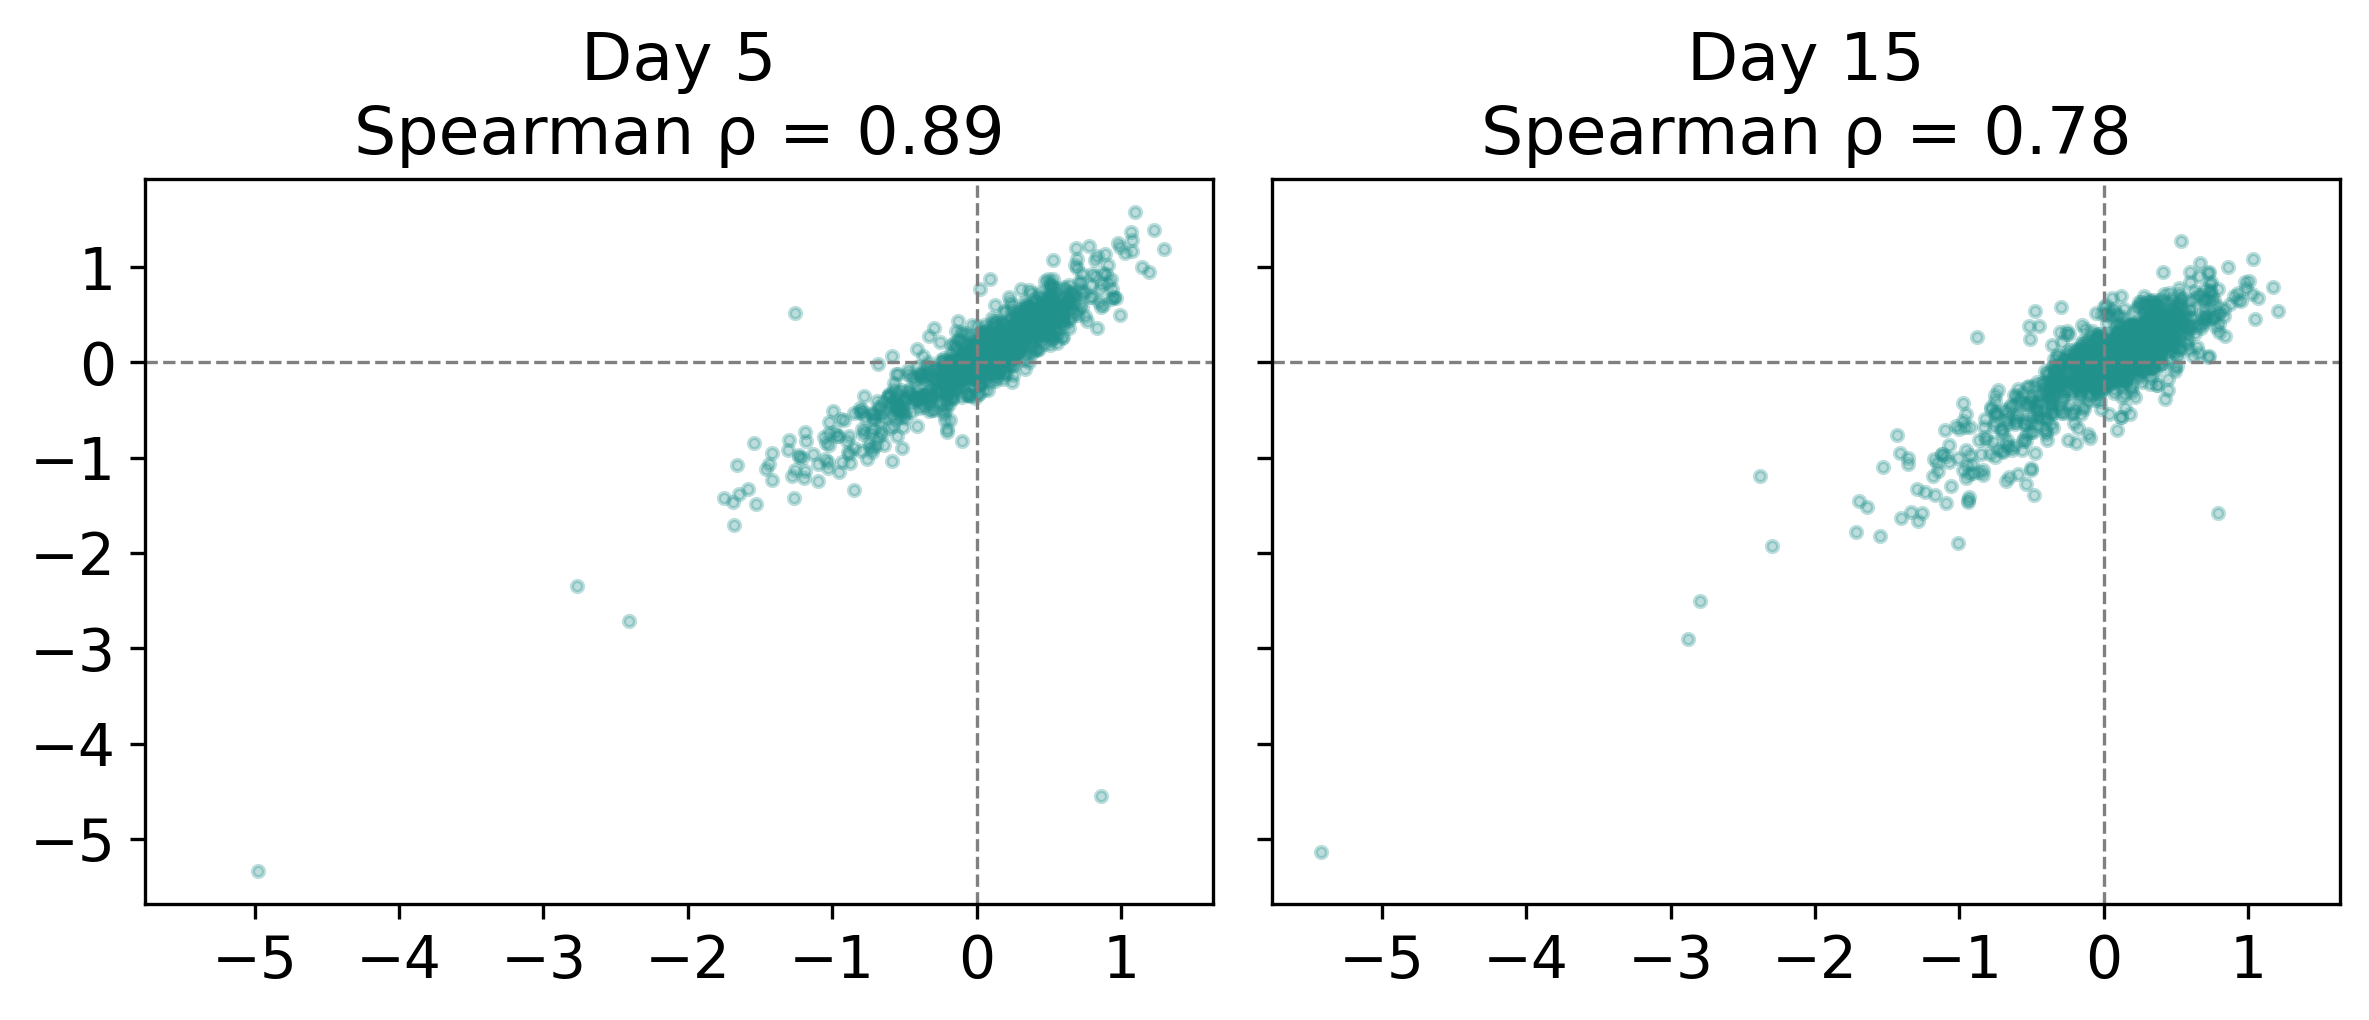

In [38]:
plt.rcParams['figure.dpi'] = 300
fig, axes = plt.subplots(1, 2,
    figsize=(8,3.5),
    sharex=True, sharey=True
)

# ---------- D5 ----------
plot_corr(
    axes[0],
    noPuro["LFC_median_d5"],
    puro["LFC_median_d5"],
    "",
    "",
    "Day 5"
)

# ---------- D15 ----------
plot_corr(
    axes[1],
    noPuro["LFC_median_d15"],
    puro["LFC_median_d15"],
    "",
    "",
    "Day 15"
)

#fig.suptitle(
#    "Guide-level median LFC correlation between DASIT and control (no puro)",
#   fontsize=14,
#    y=0.95
#)
#fig.supxlabel("DASIT no puro (control) gRNA LFC", fontsize=12)
#fig.supylabel("DASIT puro gRNA LFC", fontsize=12)

plt.tight_layout()
plt.show()


# Look at top hits

In [32]:
def get_top_bottom_hits(
    df,
    metric_col,
    gene_col="Gene",
    sgrna_col="sgRNA",
    target_edit_perc = "target_base_edit_perc",
    n=10,
    control_label="controlsgRNA",
    verbose=True
):
    """
    Return and print top and bottom hits by a given metric,
    including gene and sgRNA IDs, and report control positions.
    """

    # sort and reset index so position == rank
    df_sorted = (
        df
        .sort_values(metric_col, ascending=False)
        .reset_index(drop=True)
    )

    # top and bottom hits
    top_hits = df_sorted.head(n)[[gene_col, sgrna_col, metric_col, target_edit_perc]]
    bottom_hits = df_sorted.tail(n)[[gene_col, sgrna_col, metric_col, target_edit_perc]]

    # find control positions
    control_idx = df_sorted.index[df_sorted[gene_col] == control_label].tolist()

    if verbose:
        print("\nTop hits:")
        print(top_hits.to_string(index=True))

        print("\nBottom hits:")
        print(bottom_hits.to_string(index=True))

        if control_idx:
            print(f"\n{control_label} found at positions (0-based): {control_idx}")
        else:
            print(f"\n{control_label} not found in column '{gene_col}'")

    return top_hits, bottom_hits


In [33]:
get_top_bottom_hits(noPuro_LFC, "LFC_median_d15",gene_col="Gene",
    sgrna_col="gRNA_id",
    target_edit_perc = "target_base_edit_perc",
    n=10,
    control_label="controlsgRNA",
    verbose=True)

get_top_bottom_hits(puro_LFC, "LFC_median_d15",gene_col="Gene",
    sgrna_col="gRNA_id",
    target_edit_perc = "target_base_edit_perc",
    n=10,
    control_label="controlsgRNA",
    verbose=True)


Top hits:
     Gene     gRNA_id  LFC_median_d15  target_base_edit_perc
0   CSF3R   gRNA_2384        1.205719              83.333333
1    TP53  gRNA_12597        1.170432              25.591008
2   CSF3R   gRNA_2388        1.070484              66.364313
3  SETBP1  gRNA_11070        1.050893              93.264789
4   LATS1   gRNA_6743        1.031502              92.922128
5  MAP2K1   gRNA_6833        1.026654              95.317579
6   RBM10  gRNA_10547        1.008652              97.238231
7    TP53  gRNA_12601        0.986225              77.067639
8   U2AF1  gRNA_12923        0.977054              61.379720
9   CD79A   gRNA_1977        0.948810              89.418627

Bottom hits:
        Gene     gRNA_id  LFC_median_d15  target_base_edit_perc
1060     ATM   gRNA_1036       -1.532139              94.795784
1061   RUNX1  gRNA_10930       -1.549531              75.851088
1062    IDH2   gRNA_5194       -1.637719              79.825812
1063    GLI1   gRNA_4829       -1.696130        

(     Gene     gRNA_id  LFC_median_d15  target_base_edit_perc
 0   CCND1   gRNA_1929        1.277907              72.416599
 1   LATS1   gRNA_6743        1.084118              93.935937
 2   RBM10  gRNA_10548        1.040157              98.986381
 3  CARD11   gRNA_1726        1.004860              92.215031
 4    TP53  gRNA_12581        0.951685              73.459119
 5    JAK2   gRNA_5769        0.950921              60.365543
 6  NOTCH1   gRNA_7902        0.943441              36.117368
 7    TP53  gRNA_12608        0.939777              56.862193
 8  DNMT3A   gRNA_2785        0.901390              56.625582
 9   RBM10  gRNA_10547        0.849601              98.094673,
         Gene     gRNA_id  LFC_median_d15  target_base_edit_perc
 1060    EZH2   gRNA_3976       -1.577769             100.000000
 1061   STAT3  gRNA_12024       -1.635264              95.250577
 1062   NCOA3   gRNA_7557       -1.661388              93.967836
 1063    BCL2   gRNA_1379       -1.782559              28

In [34]:
def compare_ranked_overlap(
    df1,
    df2,
    metric_col,
    gene_col="Gene",
    sgrna_col=None,
    n=10,
    label1="Dataset_1",
    label2="Dataset_2",
    verbose=True
):
    """
    Compare ranked overlap of top and bottom hits between two datasets.

    Parameters
    ----------
    df1, df2 : pandas.DataFrame
        DataFrames to compare
    metric_col : str
        Column to rank by
    gene_col : str
        Column identifying genes
    sgrna_col : str or None
        If provided, include sgRNA IDs in output
    n : int
        Number of top/bottom hits to compare
    label1, label2 : str
        Names for the datasets (used in output)
    verbose : bool
        Print summary tables if True

    Returns
    -------
    overlap_df : pandas.DataFrame
        Overlapping hits with ranks and metrics
    """

    def prep(df):
        return (
            df
            .sort_values(metric_col, ascending=False)
            .reset_index(drop=True)
            .assign(rank=lambda x: x.index + 1)
        )

    d1 = prep(df1)
    d2 = prep(df2)

    # extract top/bottom
    d1_hits = pd.concat([d1.head(n), d1.tail(n)])
    d2_hits = pd.concat([d2.head(n), d2.tail(n)])

    # select columns
    cols = [gene_col, metric_col, "rank"]
    if sgrna_col:
        cols.insert(1, sgrna_col)

    d1_hits = d1_hits[cols].rename(
        columns={
            metric_col: f"{metric_col}_{label1}",
            "rank": f"rank_{label1}"
        }
    )

    d2_hits = d2_hits[cols].rename(
        columns={
            metric_col: f"{metric_col}_{label2}",
            "rank": f"rank_{label2}"
        }
    )

    # merge on gene (or sgRNA if preferred)
    overlap = pd.merge(
        d1_hits,
        d2_hits,
        on=gene_col,
        how="inner"
    )

    # direction consistency
    overlap["direction_consistent"] = (
        (overlap[f"{metric_col}_{label1}"] > 0)
        == (overlap[f"{metric_col}_{label2}"] > 0)
    )

    if verbose:
        print(f"\nOverlapping hits between {label1} and {label2}:")
        if overlap.empty:
            print("No overlapping top/bottom hits.")
        else:
            print(overlap.sort_values(f"rank_{label1}").to_string(index=False))

    return overlap


In [35]:
compare_ranked_overlap(noPuro_LFC, puro_LFC,metric_col="LFC_median_d15",
    gene_col="Gene",
    sgrna_col="gRNA_id",
    n=10,
    label1="noPuro",
    label2="puro" )


Overlapping hits between noPuro and puro:
  Gene  gRNA_id_x  LFC_median_d15_noPuro  rank_noPuro  gRNA_id_y  LFC_median_d15_puro  rank_puro  direction_consistent
  TP53 gRNA_12597               1.170432            2 gRNA_12581             0.951685          5                  True
  TP53 gRNA_12597               1.170432            2 gRNA_12608             0.939777          8                  True
 LATS1  gRNA_6743               1.031502            5  gRNA_6743             1.084118          2                  True
MAP2K1  gRNA_6833               1.026654            6  gRNA_6837            -1.898868       1066                 False
 RBM10 gRNA_10547               1.008652            7 gRNA_10548             1.040157          3                  True
 RBM10 gRNA_10547               1.008652            7 gRNA_10547             0.849601         10                  True
  TP53 gRNA_12601               0.986225            8 gRNA_12581             0.951685          5                  True
  TP5

,Gene,gRNA_id_x,LFC_median_d15_noPuro,rank_noPuro,gRNA_id_y,LFC_median_d15_puro,rank_puro,direction_consistent
0,TP53,gRNA_12597,1.170432,2,gRNA_12581,0.951685,5,True
1,TP53,gRNA_12597,1.170432,2,gRNA_12608,0.939777,8,True
2,LATS1,gRNA_6743,1.031502,5,gRNA_6743,1.084118,2,True
3,MAP2K1,gRNA_6833,1.026654,6,gRNA_6837,-1.898868,1066,False
4,RBM10,gRNA_10547,1.008652,7,gRNA_10548,1.040157,3,True
5,RBM10,gRNA_10547,1.008652,7,gRNA_10547,0.849601,10,True
6,TP53,gRNA_12601,0.986225,8,gRNA_12581,0.951685,5,True
7,TP53,gRNA_12601,0.986225,8,gRNA_12608,0.939777,8,True
8,RUNX1,gRNA_10930,-1.549531,1062,gRNA_10930,-1.824003,1065,True
9,BCL2,gRNA_1379,-1.719119,1065,gRNA_1379,-1.782559,1064,True


In [36]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_ranked_hits(
    df,
    metric_col,
    gene_col="Gene",
    mutation_col=None,
    sgrna_col=None,
    fdr_col=None,
    n_label=20,
    title=None,
    figsize=(4, 6),
    ylim=None
):
    """
    Ranked scatter plot with fixed annotation boxes for top and bottom hits.
    """

    # ---- prepare ranked dataframe ----
    df_ranked = (
        df
        .sort_values(metric_col, ascending=False)
        .reset_index(drop=True)
        .copy()
    )
    df_ranked["rank"] = df_ranked.index + 1

    # ---- color mapping (optional FDR) ----
    if fdr_col:
        def fdr_color(fdr):
            if fdr < 1e-4:
                return "gray"
            elif fdr < 1e-3:
                return "red"
            elif fdr < 1e-2:
                return "purple"
            elif fdr < 1e-1:
                return "blue"
            else:
                return "lightgray"

        colors = df_ranked[fdr_col].apply(fdr_color)
        sizes = df_ranked[fdr_col].apply(lambda f: 40 if f < 1e-3 else 20)
    else:
        colors = ["lightgray"] * len(df_ranked)
        sizes = [20] * len(df_ranked)

    # ---- base plot ----
    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(
        df_ranked["rank"],
        df_ranked[metric_col],
        c=colors,
        s=sizes,
        zorder=2
    )

    ax.axhline(0, linestyle="--", color="black", lw=1)

    ax.set_xlabel("Rank")
    ax.set_ylabel(metric_col.replace("_", " "))
    if title:
        ax.set_title(title)

    # ---- format hit lists ----
    def format_hits(df_slice, start_rank):
        lines = []
        for _, row in df_slice.iterrows():
            gene = row[gene_col]
            sgrna = row[sgrna_col] if sgrna_col else None

            if sgrna:
                label = f"{gene} ({sgrna})"
            else:
                label = gene

            lines.append(f"{start_rank}. {label}")
            start_rank += 1

        return "\n".join(lines)

    top_hits = df_ranked.iloc[:n_label]
    bottom_hits = df_ranked.iloc[-n_label:]

    top_text = format_hits(top_hits, 1)
    bottom_text = format_hits(
        bottom_hits,
        len(df_ranked) - n_label + 1
)

    # ---- fixed annotation boxes ----
    ax.text(
        0.02, 0.95,
        top_text,
        transform=ax.transAxes,
        fontsize=8,
        va="top",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        )
    )

    ax.text(
        0.98, 0.05,
        bottom_text,
        transform=ax.transAxes,
        fontsize=8,
        va="bottom",
        ha="right",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        )
    )

    # ---- aesthetics ----
    if ylim:
        ax.set_ylim(ylim)

    ax.set_xlim(0, df_ranked["rank"].max() * 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return fig, ax


(<Figure size 1200x1800 with 1 Axes>,
 <Axes: title={'center': 'DASIT D15'}, xlabel='Rank', ylabel='LFC median d15'>)

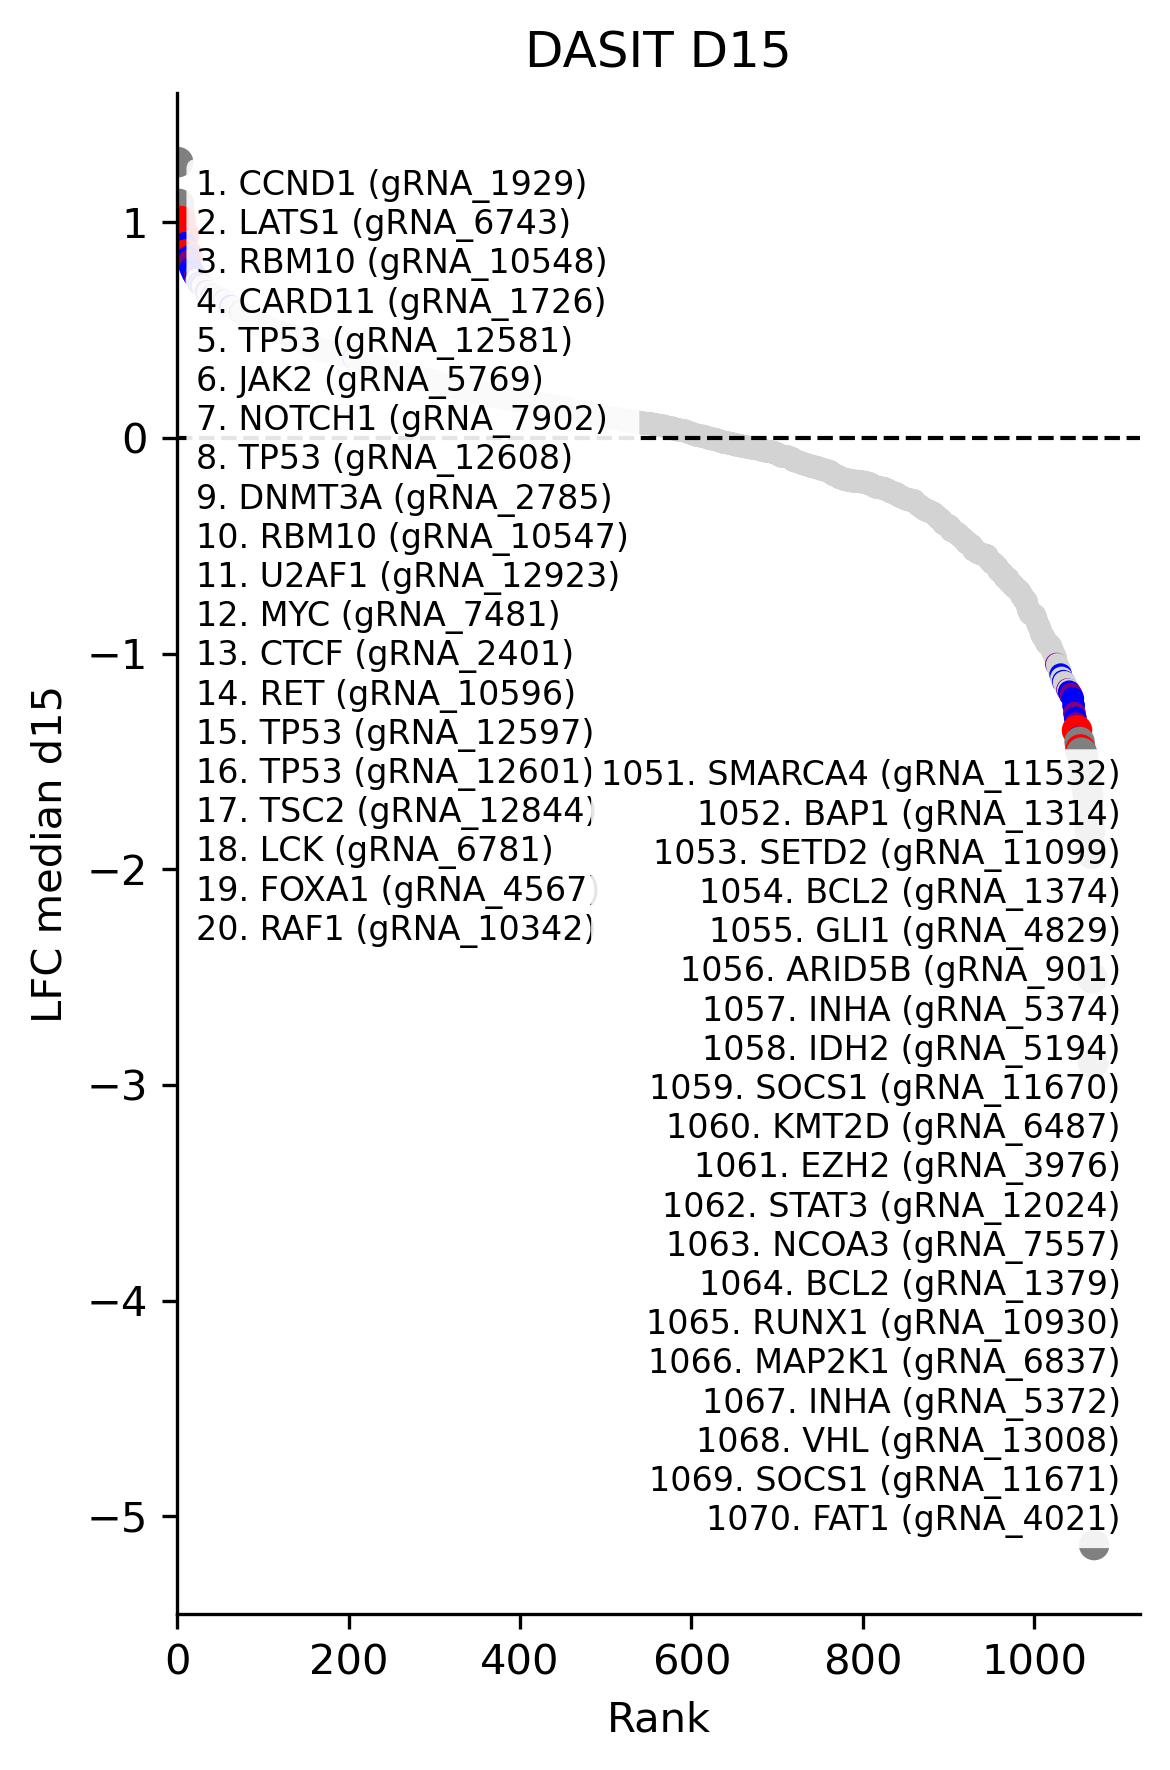

In [37]:
plot_ranked_hits(puro_LFC, metric_col="LFC_median_d15", gene_col="Gene", sgrna_col="gRNA_id", fdr_col="FDR_d15",
    title="DASIT D15")

(<Figure size 1200x1800 with 1 Axes>,
 <Axes: title={'center': 'noPuro D15'}, xlabel='Rank', ylabel='LFC median d15'>)

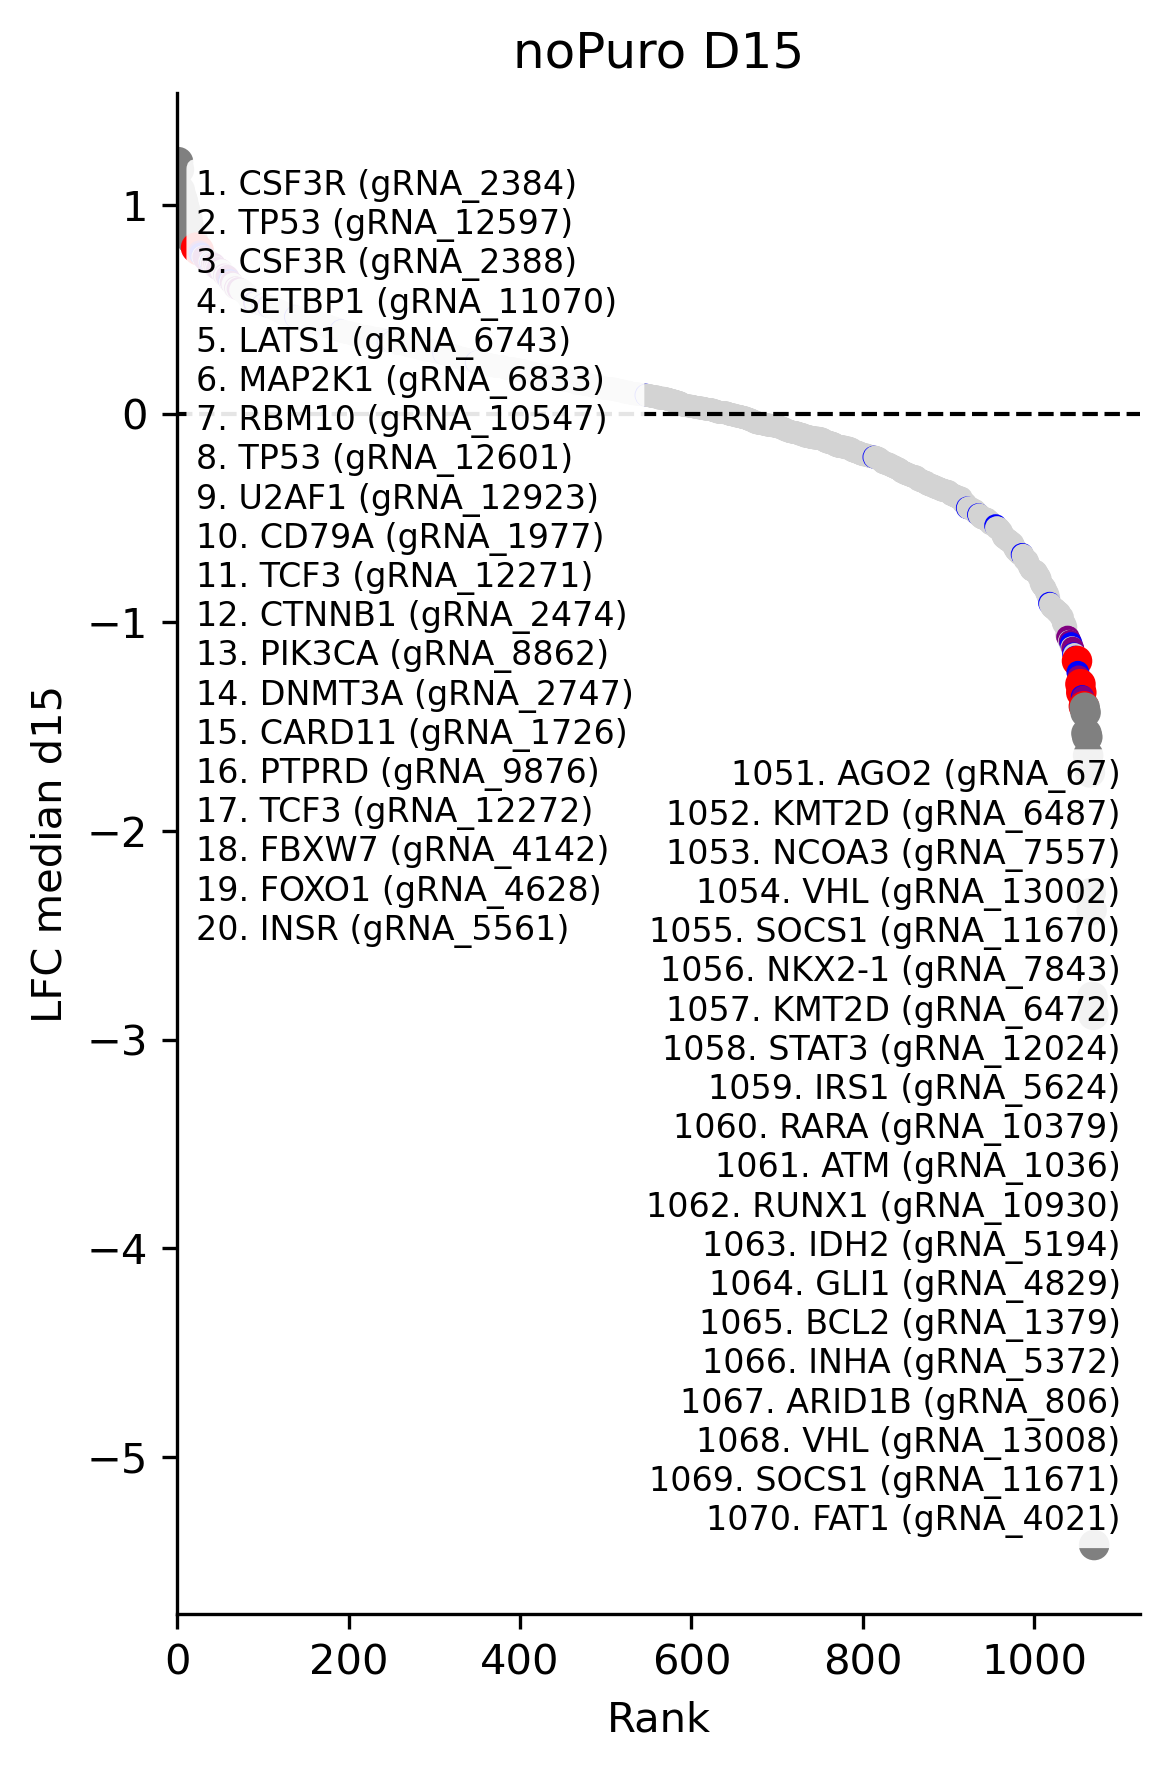

In [38]:
plot_ranked_hits(noPuro_LFC, metric_col="LFC_median_d15", sgrna_col="gRNA_id", gene_col="Gene", fdr_col="FDR_d15",
    title="noPuro D15")

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_ranked_overlap(
    df1,
    df2,
    metric_col,
    gene_col="Gene",
    sgrna_col="sgRNA",
    n=20,
    label1="Dataset 1",
    label2="Dataset 2",
    figsize=(5, 5),
):
    """
    Rank–rank overlap plot for top/bottom N hits between two datasets.
    Text boxes show unique genes with overlapping sgRNA IDs.
    """

    # ---------- prepare ranked dfs ----------
    def prep(df):
        return (
            df
            .sort_values(metric_col, ascending=False)
            .reset_index(drop=True)
            .assign(rank=lambda x: x.index + 1)
        )

    d1 = prep(df1)
    d2 = prep(df2)
    total = len(d1)

    # ---------- select top & bottom ----------
    d1_hits = pd.concat([d1.head(n), d1.tail(n)])
    d2_hits = pd.concat([d2.head(n), d2.tail(n)])

    # ---------- overlap (sgRNA-level) ----------
    overlap = pd.merge(
        d1_hits[[gene_col, sgrna_col, metric_col, "rank"]],
        d2_hits[[gene_col, sgrna_col, metric_col, "rank"]],
        on=[gene_col, sgrna_col],
        suffixes=(f"_{label1}", f"_{label2}")
    )

    # ---------- classify overlap ----------
    def classify(row):
        r1 = row[f"rank_{label1}"]
        r2 = row[f"rank_{label2}"]

        if r1 <= n and r2 <= n:
            return "shared_enriched"
        if r1 > total - n and r2 > total - n:
            return "shared_depleted"
        if r1 <= n and r2 > total - n:
            return "enriched_to_depleted"
        if r1 > total - n and r2 <= n:
            return "depleted_to_enriched"
        return "other"

    overlap["category"] = overlap.apply(classify, axis=1)

    # ---------- plotting ----------
    fig, ax = plt.subplots(figsize=figsize)

    # background
    ax.scatter(
        d1["rank"],
        d2["rank"],
        s=8,
        color="lightgray",
        zorder=1
    )

    # highlighted overlap
    color_map = {
        "shared_enriched": "black",
        "shared_depleted": "black",
        "enriched_to_depleted": "red",
        "depleted_to_enriched": "red",
    }

    ax.scatter(
        overlap[f"rank_{label1}"],
        overlap[f"rank_{label2}"],
        c=overlap["category"].map(color_map),
        s=40,
        zorder=2
    )

    # guides
    ax.axvline(n, linestyle="--", color="gray", lw=1)
    ax.axvline(total - n, linestyle="--", color="gray", lw=1)
    ax.axhline(n, linestyle="--", color="gray", lw=1)
    ax.axhline(total - n, linestyle="--", color="gray", lw=1)

    # diagonal
    ax.plot([0, total], [0, total], color="lightgray", lw=2, zorder=0)

    # axes
    ax.set_xlim(0, total + 20)
    ax.set_ylim(total + 20, 0)
    ax.set_xlabel(f"{label1} rank")
    ax.set_ylabel(f"{label2} rank")
    ax.set_title(f"Ranked overlap (top/bottom {n})")

    # ---------- text box helper ----------
    def make_box(df, title):
        if df.empty:
            return f"{title}\n(none)"

        grouped = df.groupby(gene_col)
        lines = [f"{title} ({grouped.ngroups})"]

        for gene, sub in grouped:
            sgrnas = sorted(sub[sgrna_col].unique())
            lines.append(f"{gene} ({', '.join(sgrnas)})")

        return "\n".join(lines)

    # ---------- annotation boxes ----------
    top_box = make_box(
        overlap[overlap["category"] == "shared_enriched"],
        "Shared enriched"
    )

    bottom_box = make_box(
        overlap[overlap["category"] == "shared_depleted"],
        "Shared depleted"
    )

    ax.text(
        0.02, 0.98,
        top_box,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9)
    )

    ax.text(
        0.98, 0.02,
        bottom_box,
        transform=ax.transAxes,
        va="bottom",
        ha="right",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

    return overlap


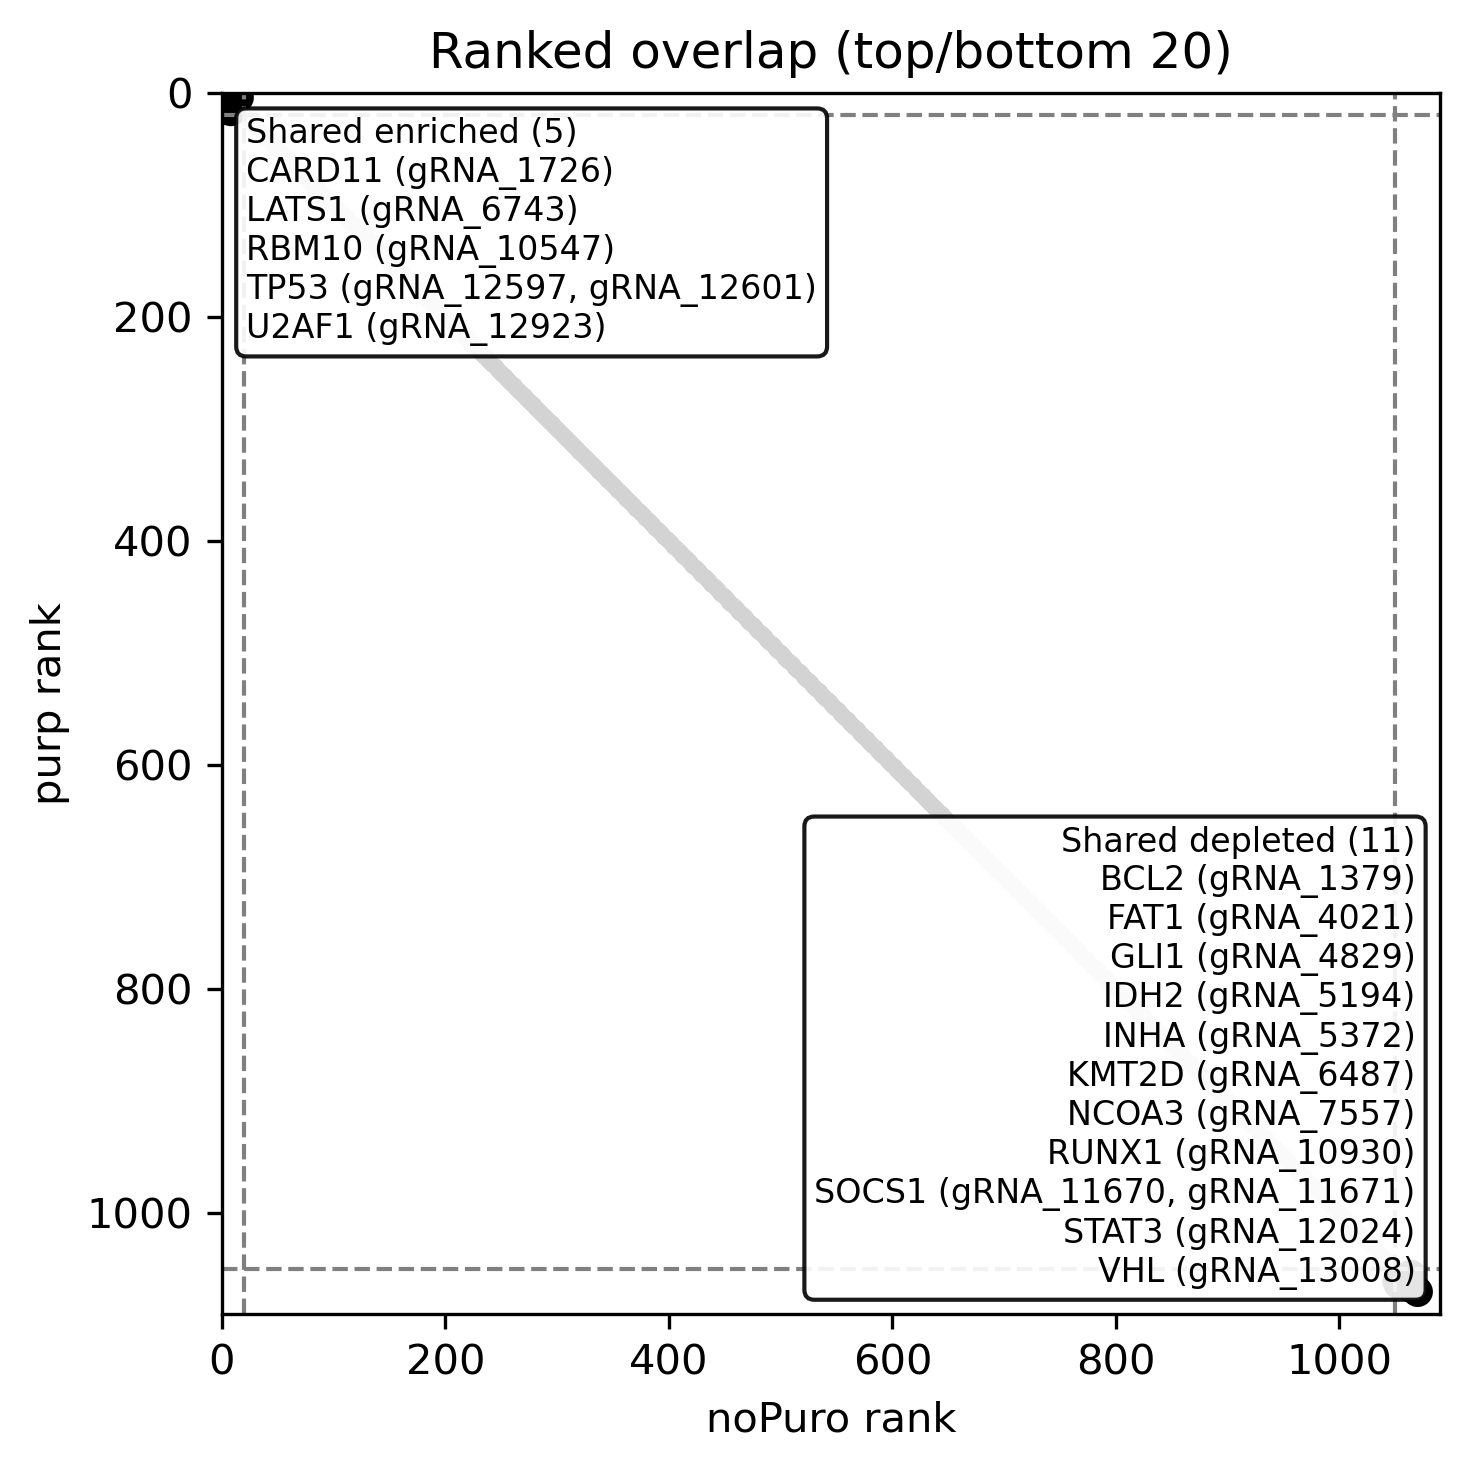

,Gene,gRNA_id,LFC_median_d15_noPuro,rank_noPuro,LFC_median_d15_purp,rank_purp,category
0,TP53,gRNA_12597,1.170432,2,0.794501,15,shared_enriched
1,LATS1,gRNA_6743,1.031502,5,1.084118,2,shared_enriched
2,RBM10,gRNA_10547,1.008652,7,0.849601,10,shared_enriched
3,TP53,gRNA_12601,0.986225,8,0.784452,16,shared_enriched
4,U2AF1,gRNA_12923,0.977054,9,0.846402,11,shared_enriched
5,CARD11,gRNA_1726,0.861562,15,1.004860,4,shared_enriched
6,KMT2D,gRNA_6487,-1.261177,1052,-1.575417,1060,shared_depleted
7,NCOA3,gRNA_7557,-1.287471,1053,-1.661388,1063,shared_depleted
8,SOCS1,gRNA_11670,-1.335769,1055,-1.574980,1059,shared_depleted
9,STAT3,gRNA_12024,-1.401803,1058,-1.635264,1062,shared_depleted


In [40]:
plot_ranked_overlap(noPuro_LFC, puro_LFC, metric_col="LFC_median_d15", gene_col="Gene", sgrna_col="gRNA_id", n = 20, label1="noPuro", label2="purp")

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

def plot_lfc_correlation_with_hits(
    df1,
    df2,
    metric_col="LFC_median_d15",
    gene_col="Gene",
    sgrna_col="sgRNA",
    n=20,
    label1="Dataset 1",
    label2="Dataset 2",
    figsize=(5, 5),
):
    """
    Scatter plot of LFC vs LFC between two datasets at the gRNA level,
    highlighting and labeling overlapping top/bottom N ranked guides.
    """

    # ---- rank guides in each dataset ----
    def prep(df):
        return (
            df
            .sort_values(metric_col, ascending=False)
            .reset_index(drop=True)
            .assign(rank=lambda x: x.index + 1)
        )

    d1 = prep(df1)
    d2 = prep(df2)
    total = len(d1)

    # ---- merge on sgRNA (true guide overlap) ----
    merged = pd.merge(
        d1[[gene_col, sgrna_col, metric_col, "rank"]],
        d2[[gene_col, sgrna_col, metric_col, "rank"]],
        on=[gene_col, sgrna_col],
        suffixes=(f"_{label1}", f"_{label2}")
    )

    # ---- define top/bottom hit overlap ----
    merged["hit_category"] = "background"

    top_mask = (
        (merged[f"rank_{label1}"] <= n) &
        (merged[f"rank_{label2}"] <= n)
    )

    bottom_mask = (
        (merged[f"rank_{label1}"] > total - n) &
        (merged[f"rank_{label2}"] > total - n)
    )

    merged.loc[top_mask, "hit_category"] = "shared_enriched"
    merged.loc[bottom_mask, "hit_category"] = "shared_depleted"

    # ---- correlation ----
    rho, pval = spearmanr(
        merged[f"{metric_col}_{label1}"],
        merged[f"{metric_col}_{label2}"]
    )

    # ---- plotting ----
    fig, ax = plt.subplots(figsize=figsize)

    # background
    ax.scatter(
        merged[f"{metric_col}_{label1}"],
        merged[f"{metric_col}_{label2}"],
        s=12,
        color="lightgray",
        alpha=0.6,
        zorder=1
    )

    # highlighted hits
    palette = sns.color_palette("viridis", 10)

    color_map = {
        "shared_depleted": palette[2],   # dark blue / purple
        "shared_enriched": palette[8],   # yellow-green
    }

    for cat, color in color_map.items():
        sub = merged[merged["hit_category"] == cat]
        ax.scatter(
            sub[f"{metric_col}_{label1}"],
            sub[f"{metric_col}_{label2}"],
            s=40,
            color=color,
            edgecolor="black",
            zorder=2,
            label=cat.replace("_", " ")
        )

    # ---- label highlighted guides only ----
    label_df = merged[merged["hit_category"] != "background"]

    for _, row in label_df.iterrows():
        label = f"{row[gene_col]} ({row[sgrna_col]})"
        ax.text(
            row[f"{metric_col}_{label1}"] + 0.02,
            row[f"{metric_col}_{label2}"] + 0.02,
            label,
            fontsize=6,
            alpha=0.9
        )

    # ---- formatting ----
    ax.axhline(0, color="black", lw=1, linestyle="--")
    ax.axvline(0, color="black", lw=1, linestyle="--")

    ax.set_xlabel(f"{label1} {metric_col}")
    ax.set_ylabel(f"{label2} {metric_col}")
    ax.set_title(
        f"LFC correlation (ρ={rho:.2f})\nTop/bottom {n} shared guides"
    )

    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return merged.sort_values("hit_category")


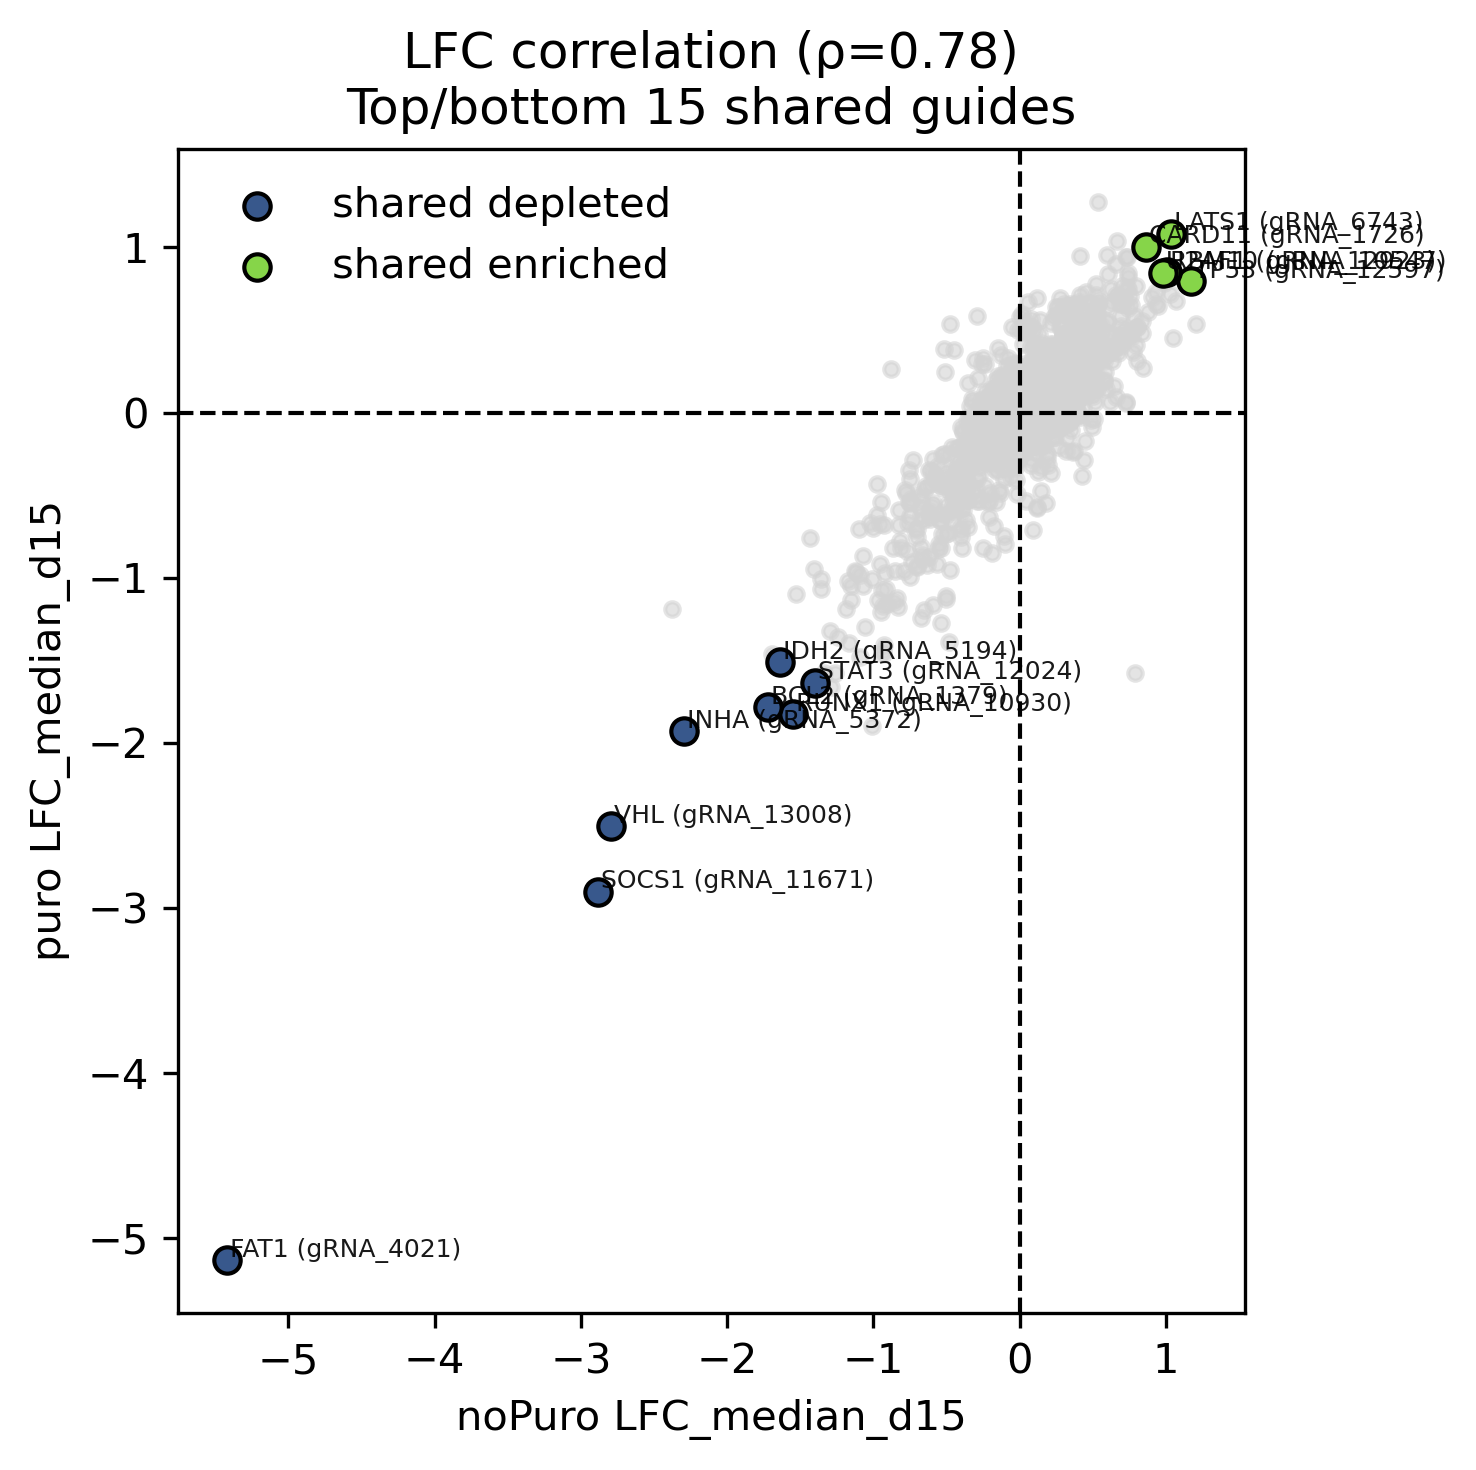

In [48]:
merged = plot_lfc_correlation_with_hits(
    noPuro_LFC,
    puro_LFC,
    metric_col="LFC_median_d15",
    gene_col="Gene",
    sgrna_col="gRNA_id",
    n=15,
    label1="noPuro",
    label2="puro"
)


# REMOVE EDITING CUTOFF WITHOUT PURO AND THE CORRELATION SHOULD BE WORSE SINCE THERE IS LESS EDITING. Main figure should be % library conservation with and without DASIT

But guide counts scale with the numner of reads so if you had 5M reads then would need threshold to be 5000x not 1000x? 

more useful to look at skew ratio

and show correlation with edited guides...no puro should have much less editing and DASIT should have higher editing because it selected for only the actively editing cells 

better to use rpm comparison which Sam's pipeline should output? 

# 2b

Going to read in the guide counts from puto and non puro as well as OG ABE screen and rename the OG dataframe samples to match 

In [48]:
sample_names = ["d0_rep1", "d0_rep2", "d0_rep3", "d5_rep1", "d5_rep2", "d5_rep3", "d15_rep1", "d15_rep2", "d15_rep3"]
puro_counts = pd.read_csv(OUTDIR / 'guide_counts_puro.txt', sep='\t')
noPuro_counts = pd.read_csv(OUTDIR / 'guide_counts_noPuro.txt', sep='\t')

puro_counts = puro_counts[puro_counts.columns[2:]]
noPuro_counts = noPuro_counts[noPuro_counts.columns[2:]]


# read in the ABE counts from original screen and subset to just in vitro samples
# normalize ABE sample names as well 

ABE_counts = pd.read_csv(OUTDIR / 'OG_ABEscreen/ABE_bc_counts.txt', sep='\t')
ABE_counts = ABE_counts[ABE_counts.columns[16:25]]
ABE_counts.columns = sample_names

In [49]:
noPuro_counts


,d0_rep1,d0_rep2,d0_rep3,d5_rep1,d5_rep2,d5_rep3,d15_rep1,d15_rep2,d15_rep3
0,3271.0,4002.0,3449.0,4440.0,4417.0,2419.0,4986.0,3397.0,3280.0
1,963.0,1241.0,879.0,2709.0,2791.0,1449.0,1769.0,1308.0,1100.0
2,1914.0,2102.0,1828.0,3402.0,3432.0,1929.0,3899.0,2042.0,2291.0
3,2147.0,1938.0,2189.0,2443.0,2343.0,1557.0,1357.0,909.0,841.0
4,28663.0,27697.0,7336.0,13262.0,21993.0,11535.0,21964.0,12916.0,13077.0
...,...,...,...,...,...,...,...,...,...
1065,30467.0,30615.0,18579.0,14913.0,22348.0,10267.0,30553.0,13120.0,14259.0
1066,12679.0,13332.0,7547.0,4087.0,7456.0,5165.0,13771.0,4087.0,5664.0
1067,50781.0,53566.0,24407.0,14310.0,29767.0,16994.0,41648.0,22720.0,23874.0
1068,26689.0,26676.0,13389.0,7951.0,13292.0,8560.0,17044.0,9112.0,11379.0


In [50]:
zeros = noPuro_counts["d0_rep1"] < 1000
print(zeros.sum())

8


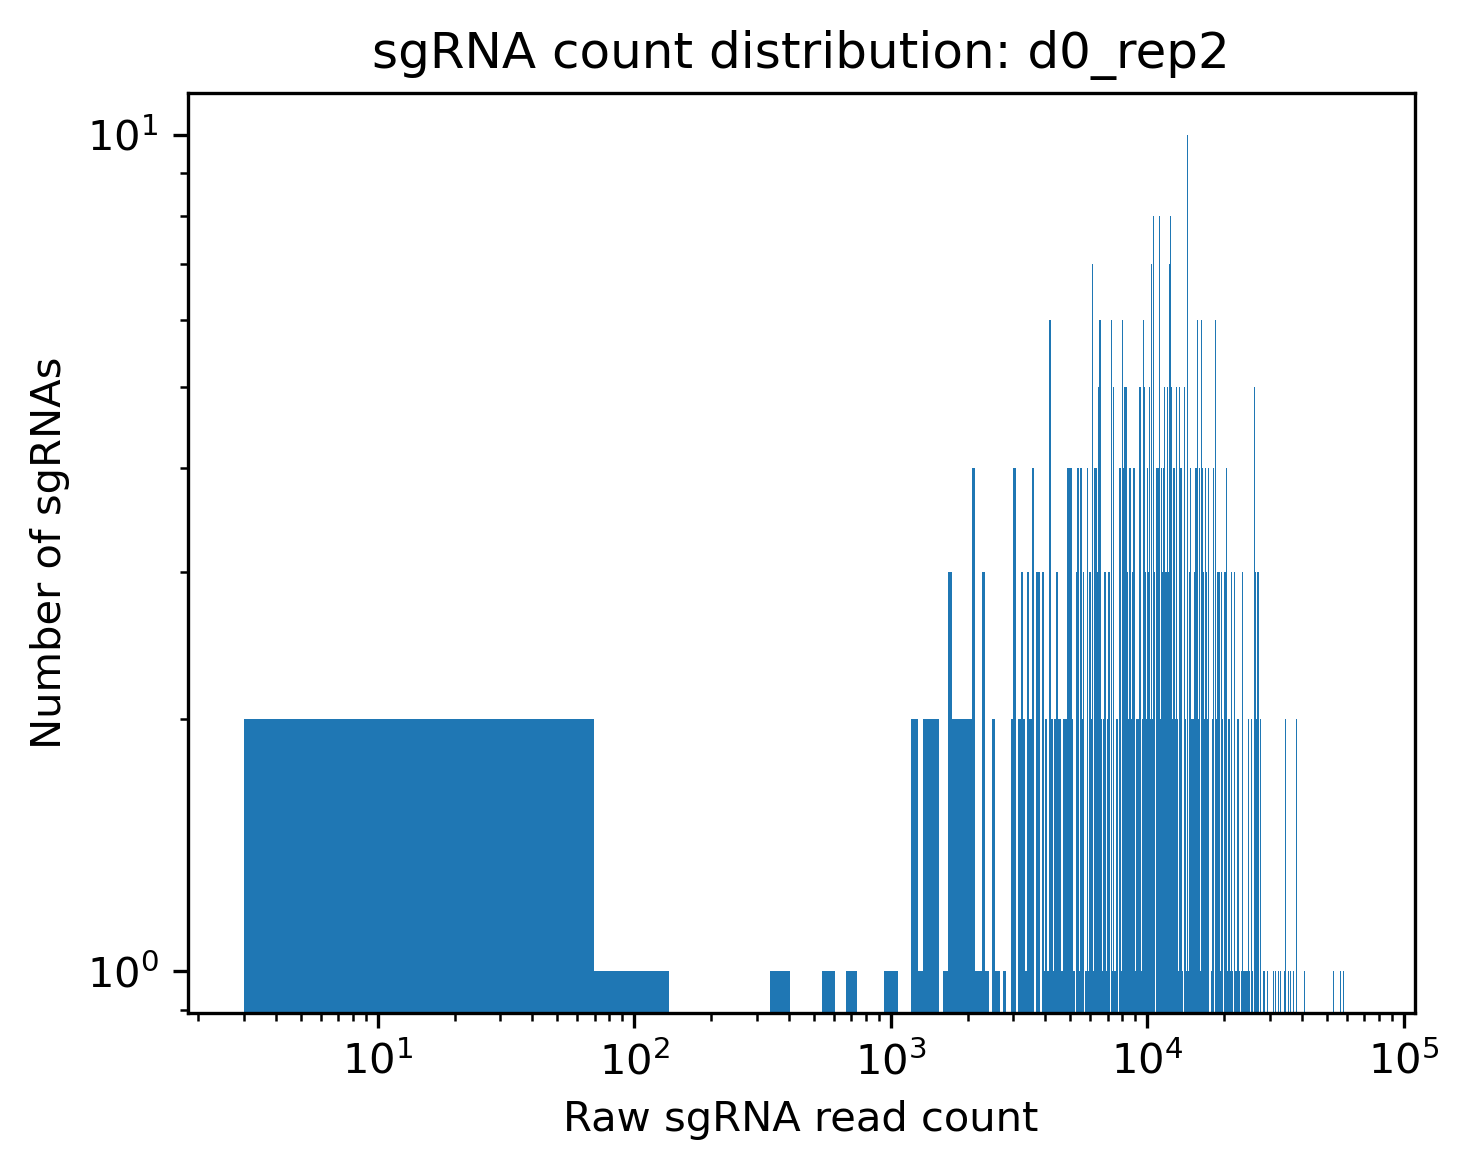

In [51]:
# choose the sample to plot
sample = "d0_rep2"

# extract raw counts
counts = noPuro_counts[sample].values

# optional: remove zeros if you want
#counts = counts[counts > 0]

plt.figure(figsize=(5,4))

plt.hist(
    counts,
    bins=1000,
    log=True,        # log scale on y-axis (VERY important)
)

plt.xscale("log")    # log scale on x-axis

plt.xlabel("Raw sgRNA read count")
plt.ylabel("Number of sgRNAs")
plt.title(f"sgRNA count distribution: {sample}")

plt.tight_layout()
plt.show()

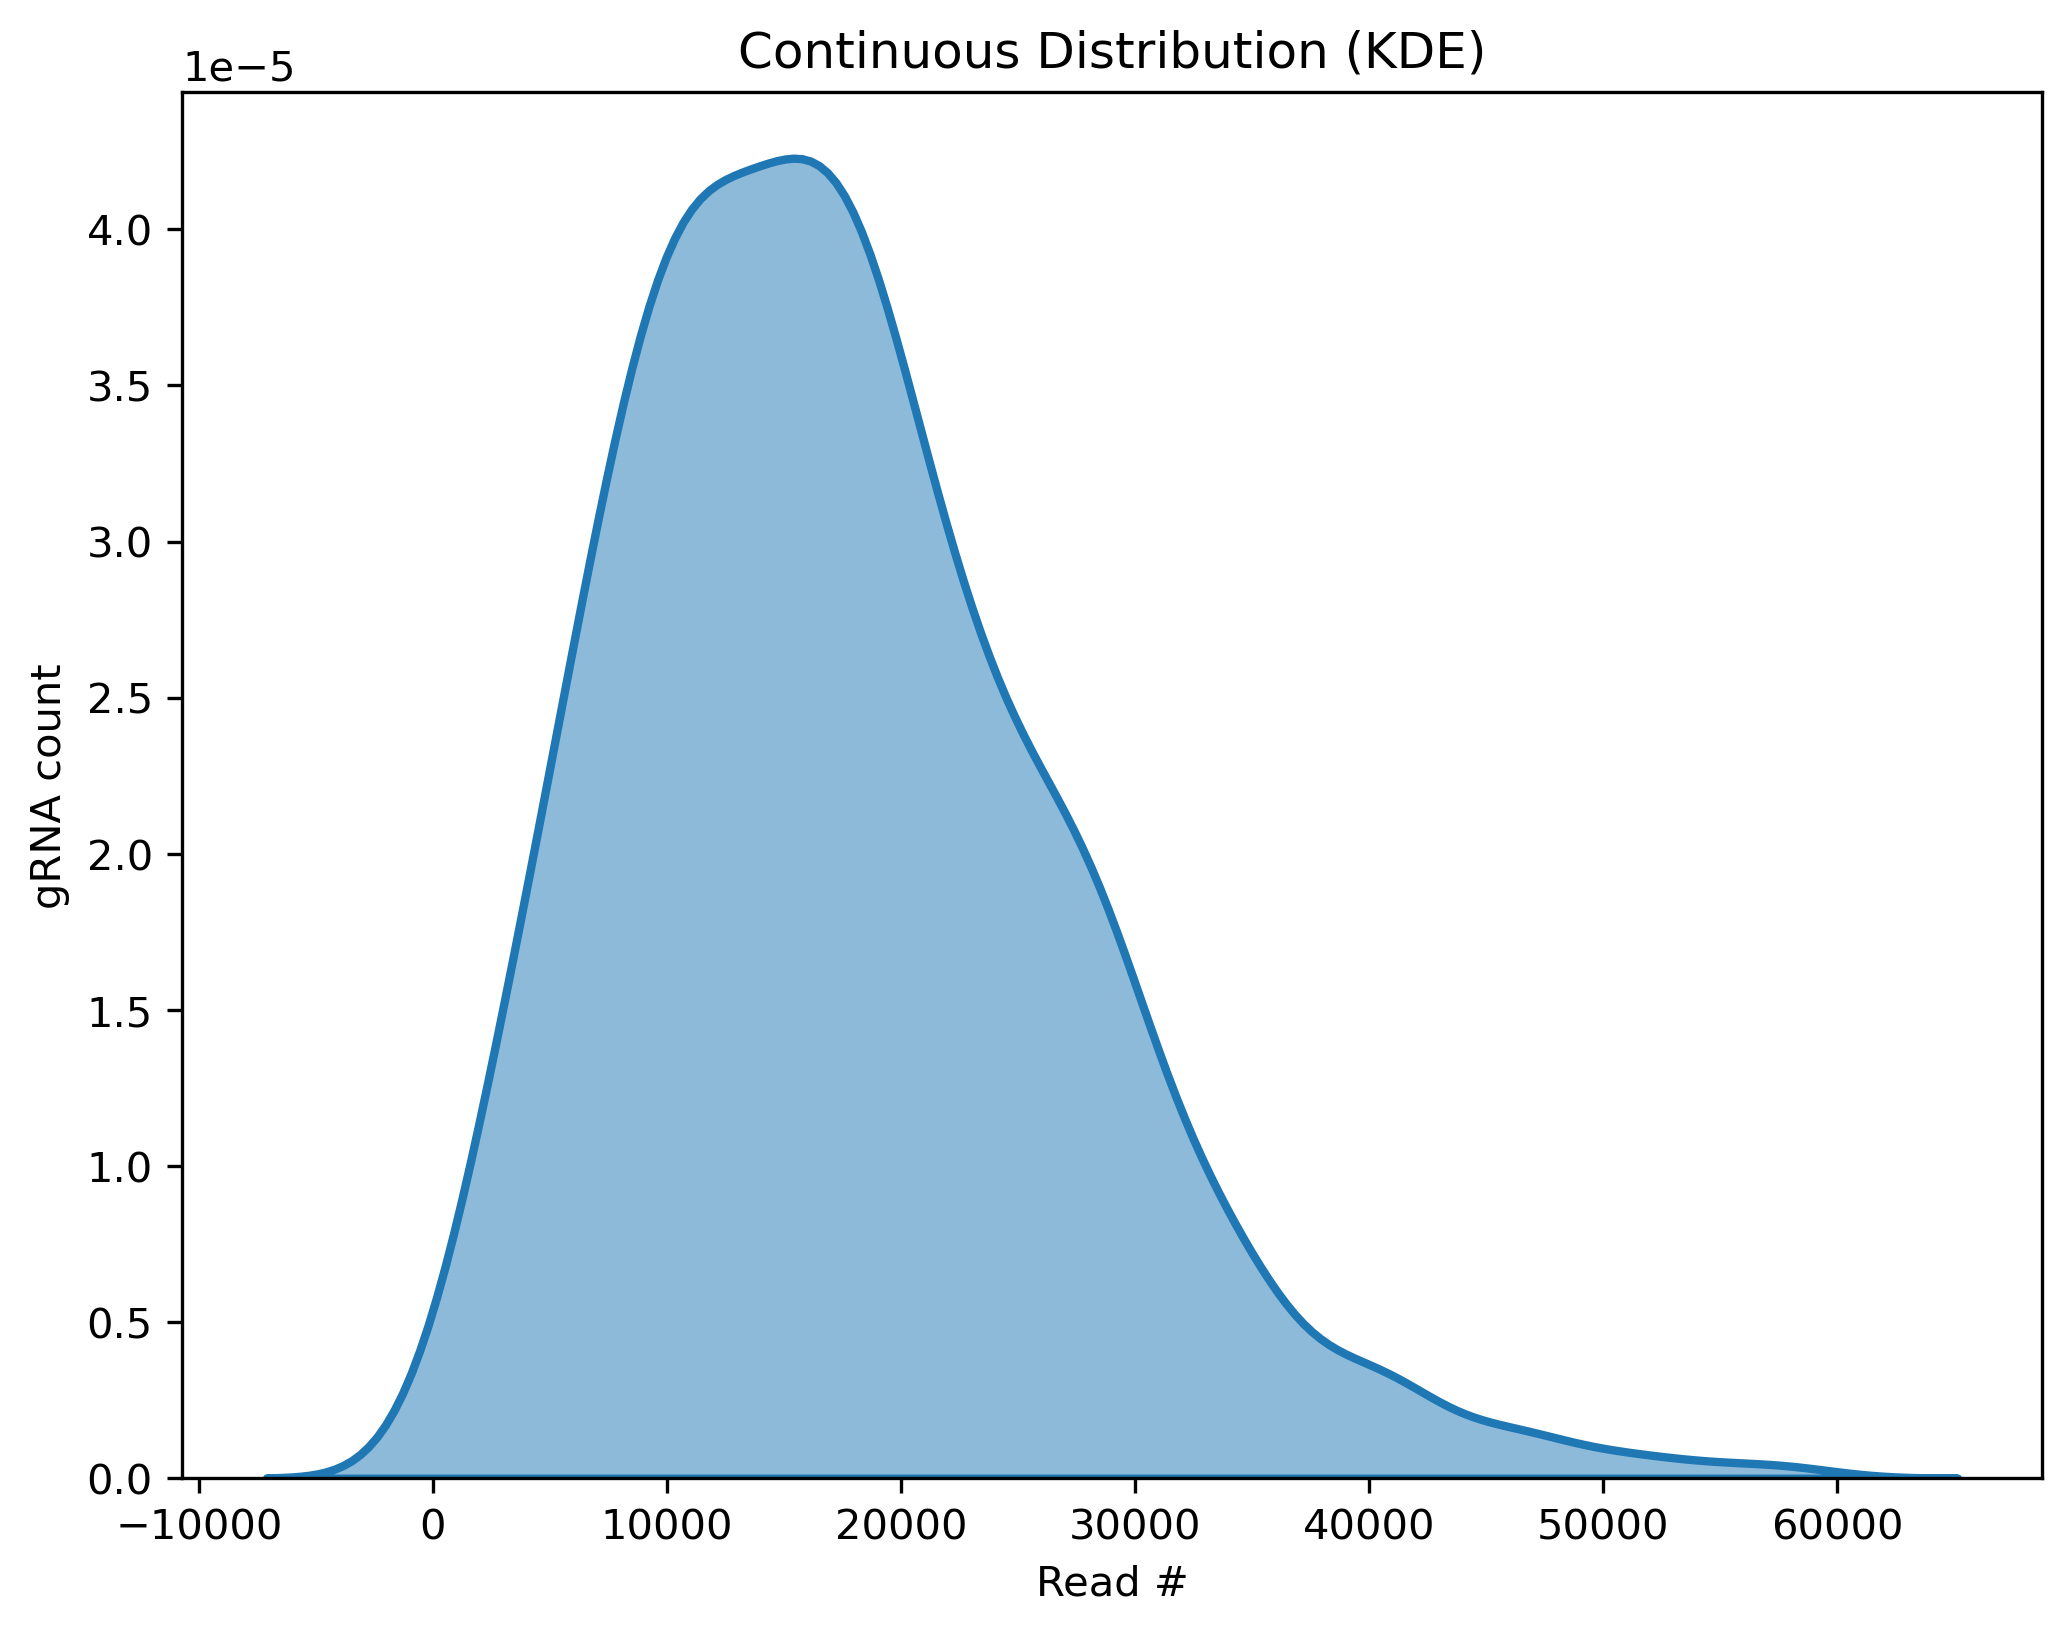

In [52]:
plt.figure(figsize=(8, 6))

# Plot a smooth KDE curve
sns.kdeplot(data=noPuro_counts, x=noPuro_counts["d5_rep2"], fill=True, alpha=0.5, linewidth=2) # 'data' can also be a pandas Series/DataFrame column

plt.title('Continuous Distribution (KDE)')
plt.xlabel('Read #')
plt.ylabel('gRNA count')
plt.show()

# DO PCA ON THE FULL COUNTS FILE SO IT SHOWS DIFFERENT CLUSTERS FOR DASIT VS NO PURO VS ORIGINAL 

Do spearman correlation between DASIT and original 

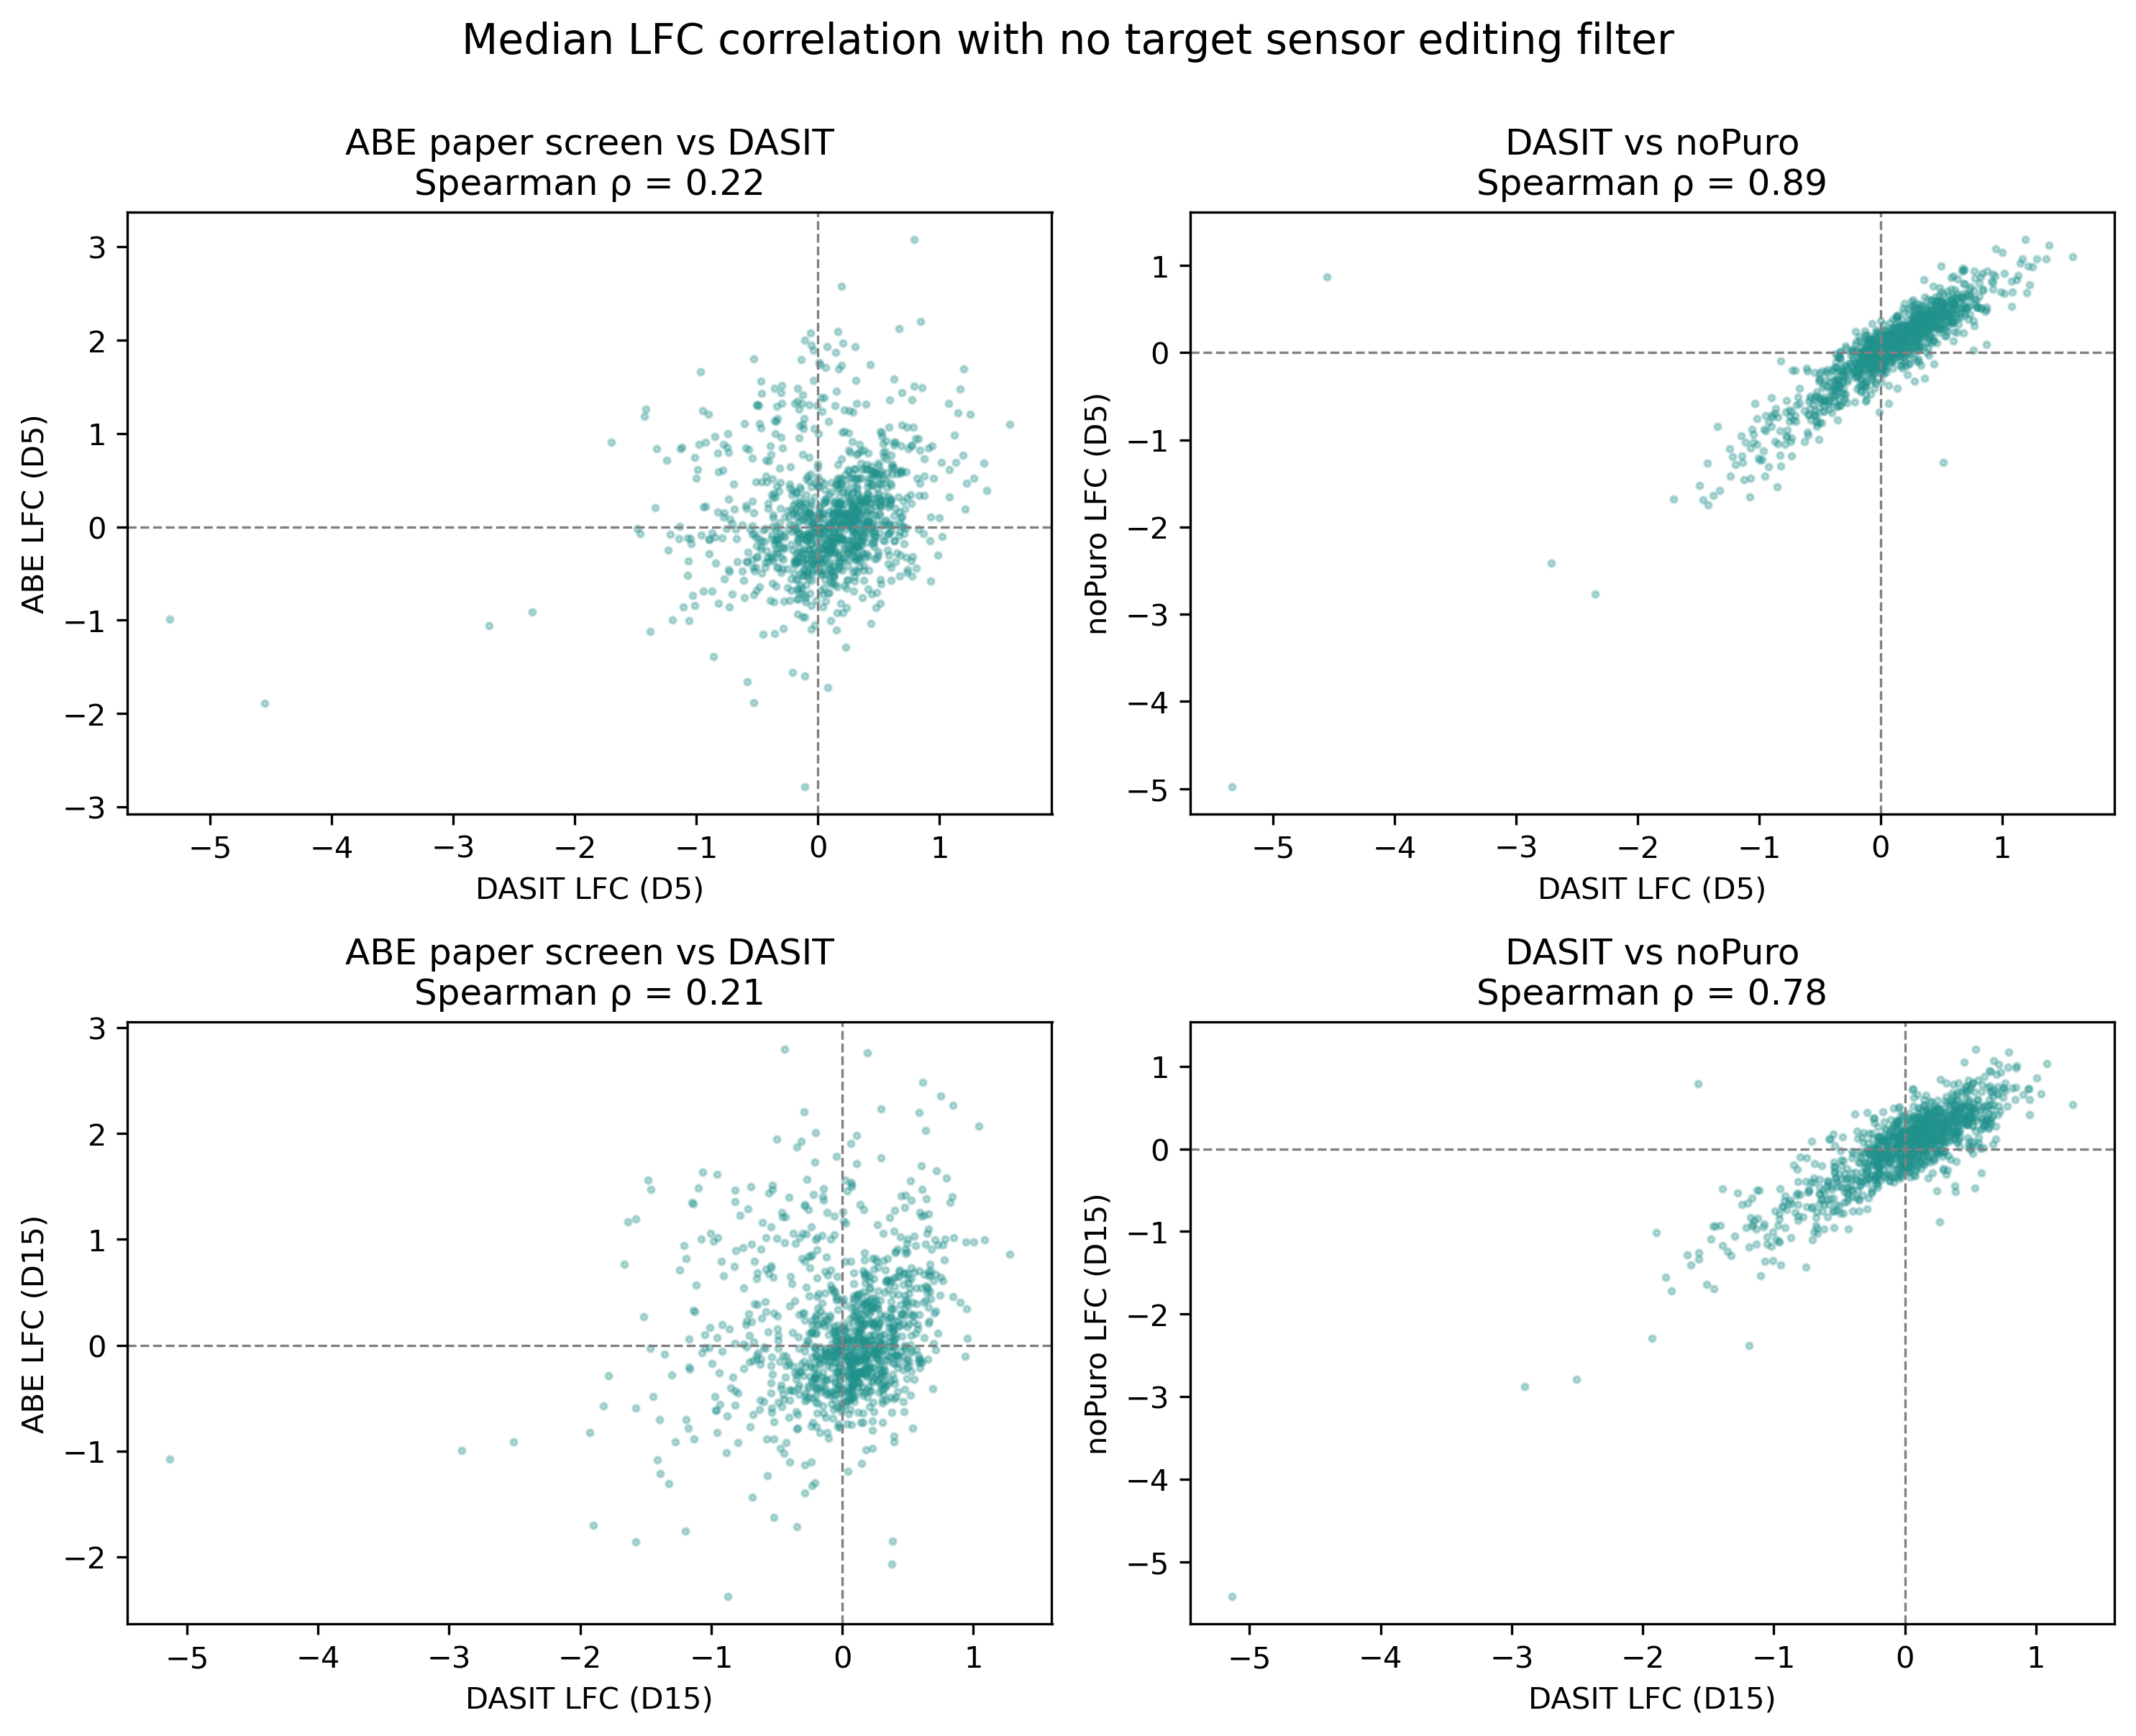

In [82]:
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10,8),
    sharex=False, sharey=False
)

# ---------- D5 ----------
plot_corr(
    axes[0,0],
    puro["LFC_median_d5"],
    abe["LFC_median_d5"],
    "DASIT LFC (D5)",
    "ABE LFC (D5)",
    "ABE paper screen vs DASIT"
)

plot_corr(
    axes[0,1],
    puro["LFC_median_d5"],
    noPuro["LFC_median_d5"],
    "DASIT LFC (D5)",
    "noPuro LFC (D5)",
    "DASIT vs noPuro"
)

# ---------- D15 ----------
plot_corr(
    axes[1,0],
    puro["LFC_median_d15"],
    abe["LFC_median_d15"],
    "DASIT LFC (D15)",
    "ABE LFC (D15)",
    "ABE paper screen vs DASIT"
)

plot_corr(
    axes[1,1],
    puro["LFC_median_d15"],
    noPuro["LFC_median_d15"],
    "DASIT LFC (D15)",
    "noPuro LFC (D15)",
    "DASIT vs noPuro"
)
fig.suptitle(
    "Median LFC correlation with no target sensor editing filter",
    fontsize=14,
    y=1
)
plt.tight_layout()
plt.show()


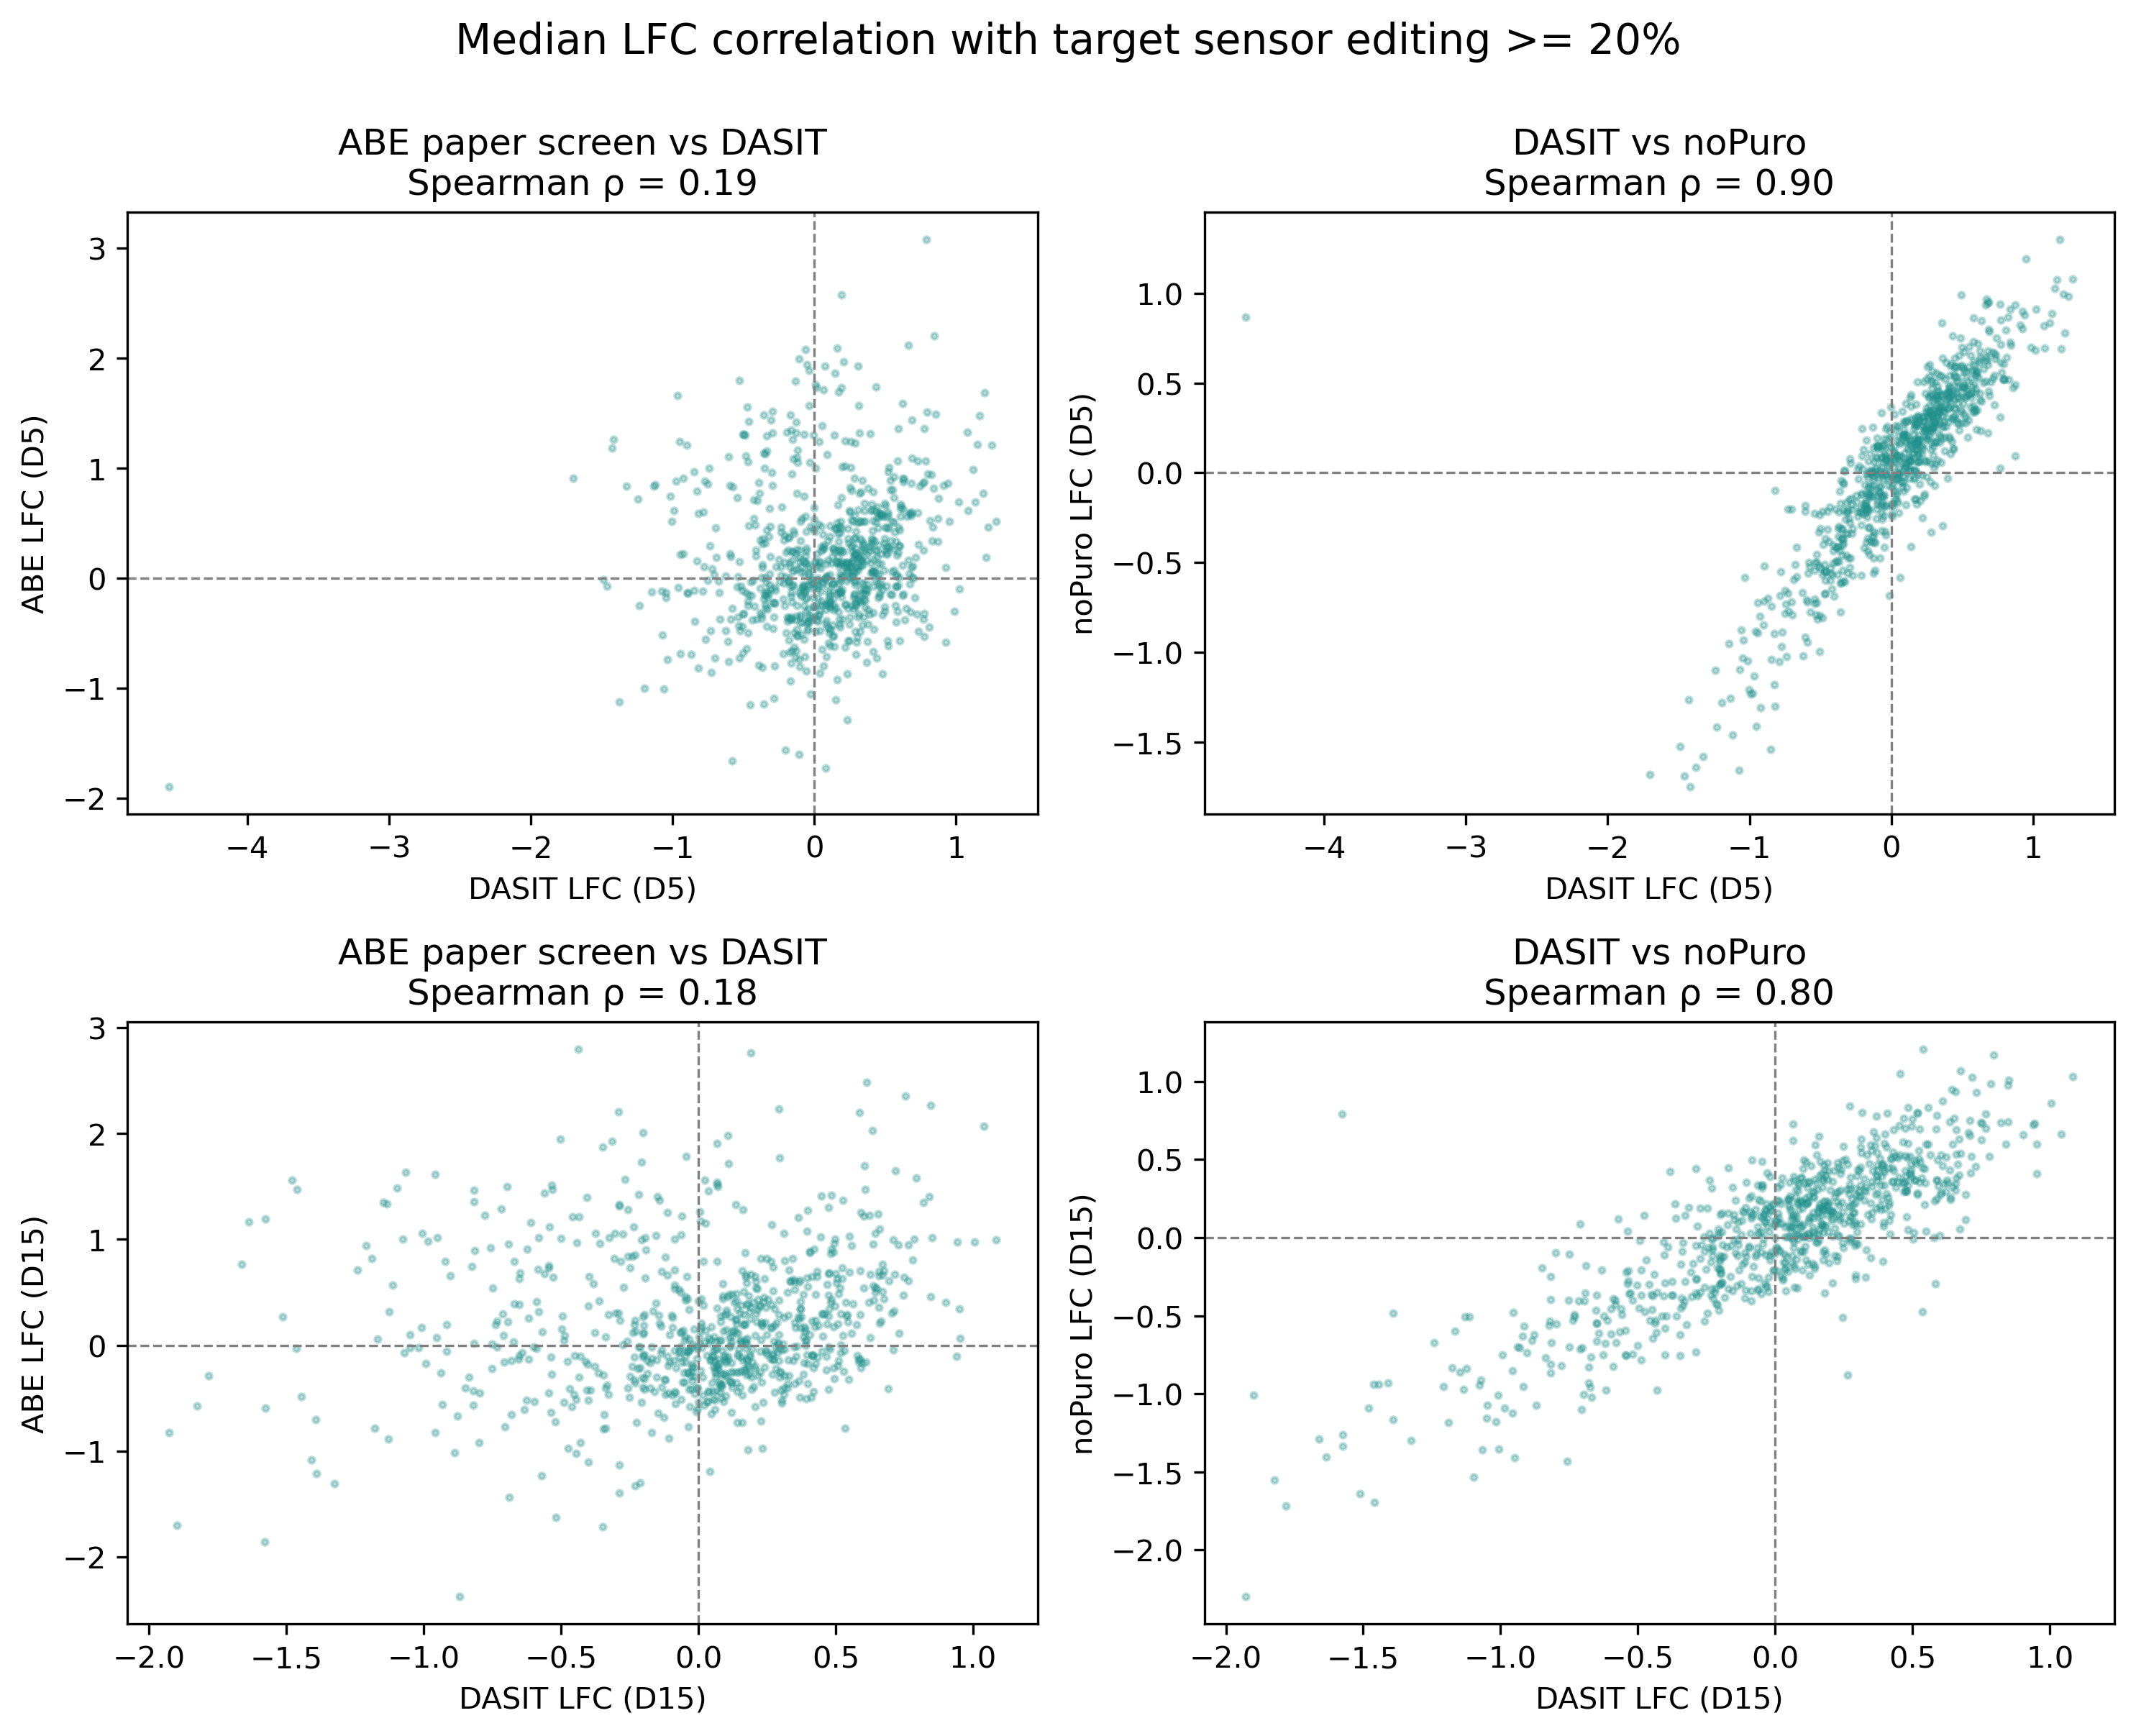

In [81]:
# do this again but now filtering for target base editing percentage > 20

mask_edit20 = abe["target_base_edit_perc"] >= 20

puro_filt   = puro.loc[mask_edit20]
abe_filt    = abe.loc[mask_edit20]
noPuro_filt = noPuro.loc[mask_edit20]

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(10,8),
    sharex=False, sharey=False
)

# ---------- D5 ----------
plot_corr(
    axes[0,0],
    puro_filt["LFC_median_d5"],
    abe_filt["LFC_median_d5"],
    "DASIT LFC (D5)",
    "ABE LFC (D5)",
    "ABE paper screen vs DASIT"
)

plot_corr(
    axes[0,1],
    puro_filt["LFC_median_d5"],
    noPuro_filt["LFC_median_d5"],
    "DASIT LFC (D5)",
    "noPuro LFC (D5)",
    "DASIT vs noPuro"
)

# ---------- D15 ----------
plot_corr(
    axes[1,0],
    puro_filt["LFC_median_d15"],
    abe_filt["LFC_median_d15"],
    "DASIT LFC (D15)",
    "ABE LFC (D15)",
    "ABE paper screen vs DASIT"
)

plot_corr(
    axes[1,1],
    puro_filt["LFC_median_d15"],
    noPuro_filt["LFC_median_d15"],
    "DASIT LFC (D15)",
    "noPuro LFC (D15)",
    "DASIT vs noPuro"
)

fig.suptitle(
    "Median LFC correlation with target sensor editing >= 20%",
    fontsize=14,
    y=1
)
plt.tight_layout()
plt.show()


# Guide correlation
Doing correlation on the guide counts files using counts per million to see if puro messed with the guide representation 

comparing the same time point by computing the mean guide count for that time point and then normalizing for sequencing depth with CPM

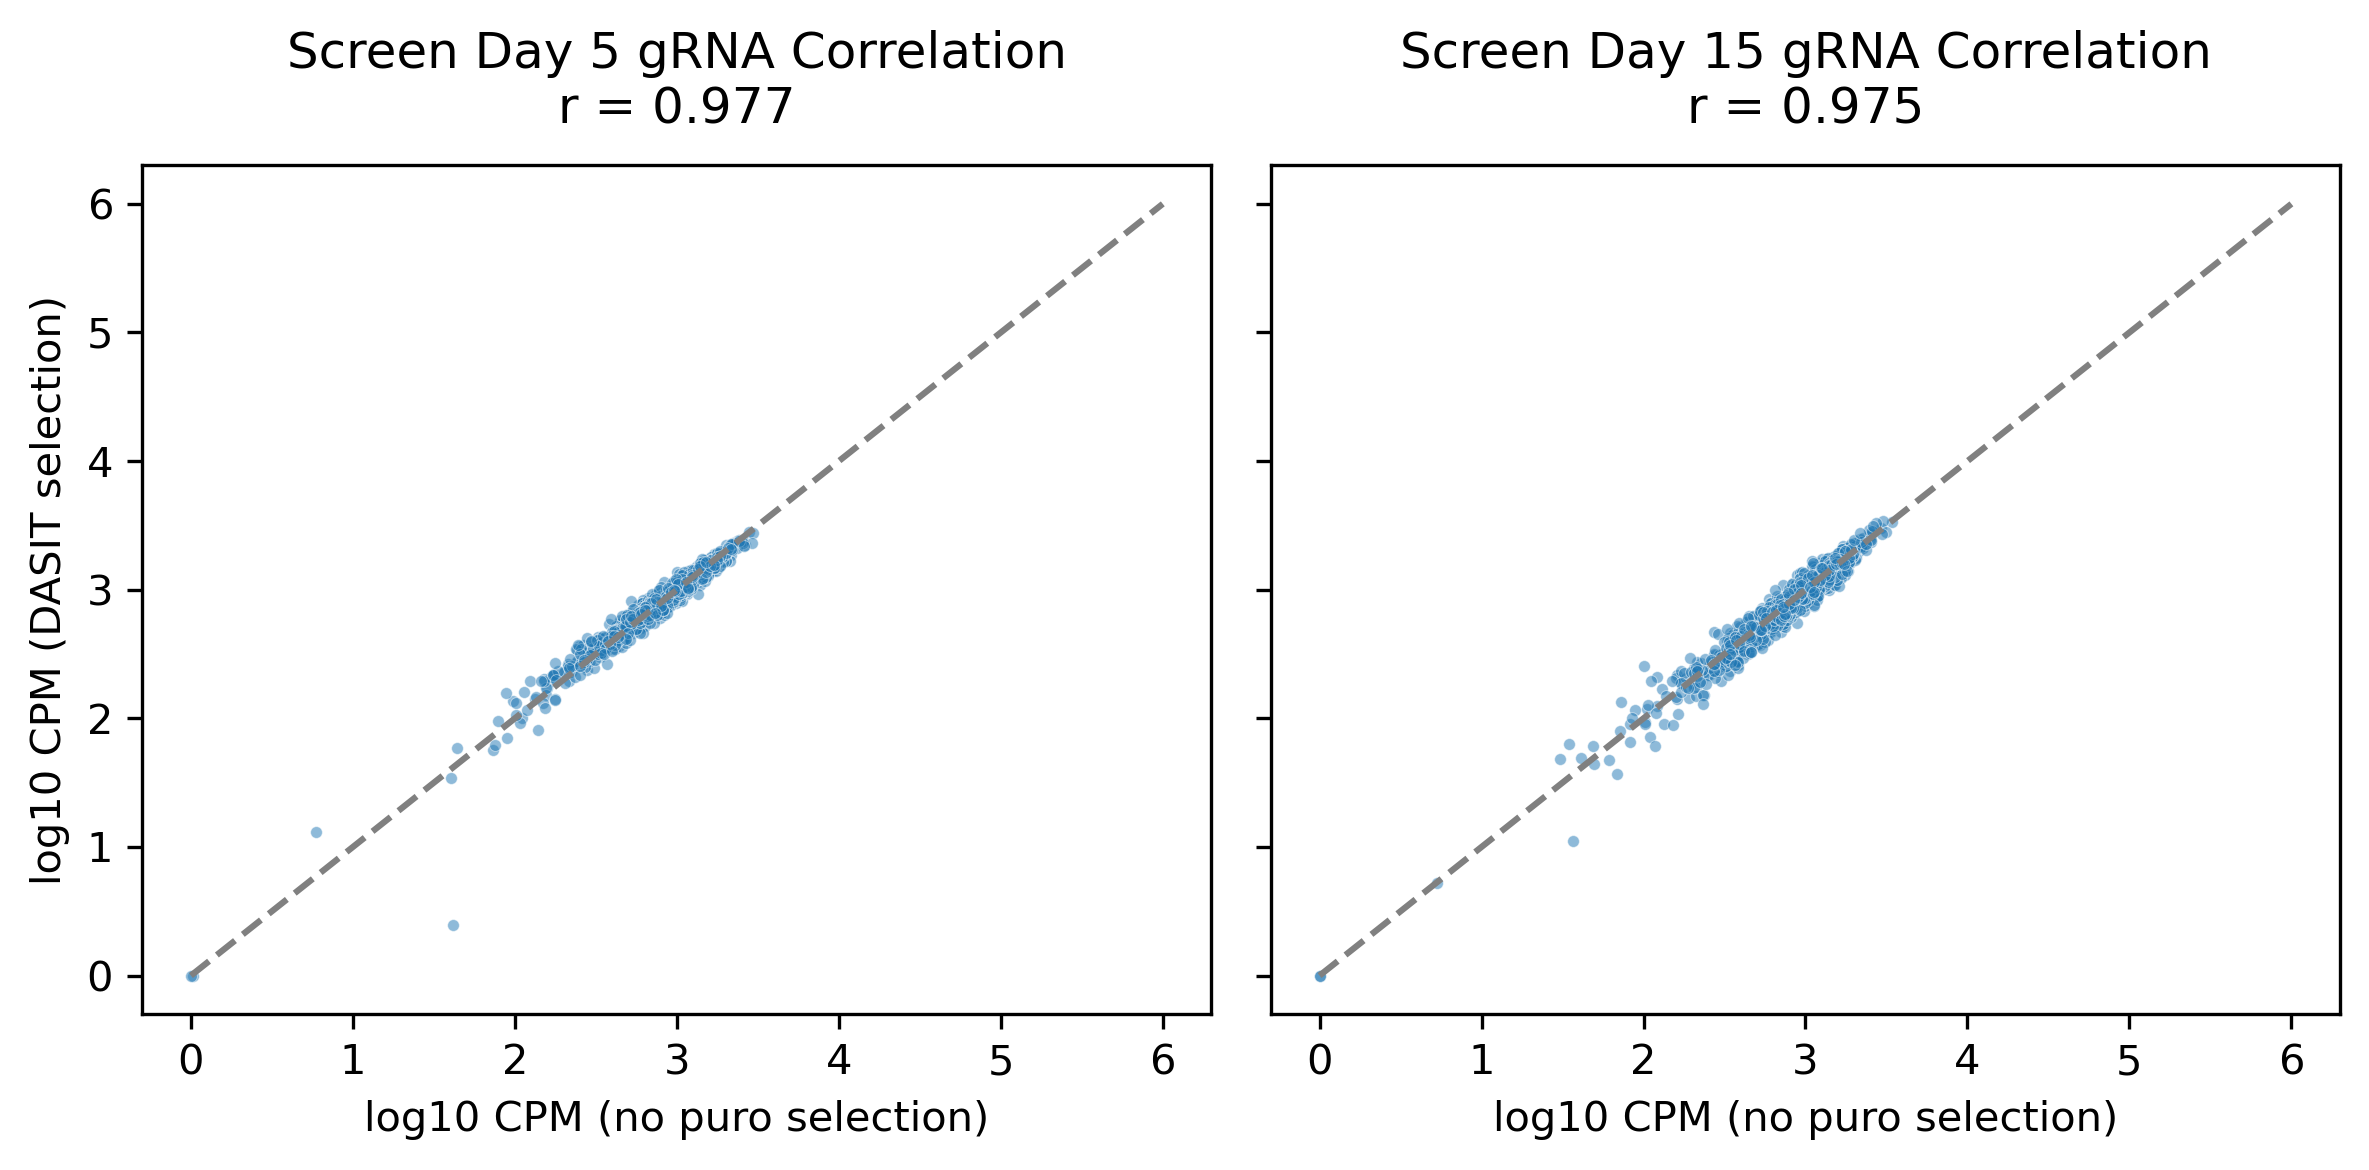

In [54]:

# Load data
no_puro = pd.read_csv(OUTDIR / "guide_counts_noPuro.txt", sep="\t")
puro = pd.read_csv(OUTDIR / "guide_counts_puro.txt", sep="\t")

# Sanity check to make sure the guides are in the same order
assert all(no_puro.sgRNA == puro.sgRNA)

# helper function 
def prep(df, reps):
    x = df[reps].mean(axis=1)
    return np.log10((x / x.sum()) * 1e6 + 1)

# Compute logCPM for D5 and D15
no_puro["D5"]  = prep(no_puro,  ["d5_rep1","d5_rep2","d5_rep3"])
puro["D5"]     = prep(puro,     ["d5_rep1","d5_rep2","d5_rep3"])
no_puro["D15"] = prep(no_puro,  ["d15_rep1","d15_rep2","d15_rep3"])
puro["D15"]    = prep(puro,     ["d15_rep1","d15_rep2","d15_rep3"])

# Correlations 
r_d5  = pearsonr(no_puro["D5"],  puro["D5"])[0]
r_d15 = pearsonr(no_puro["D15"], puro["D15"])[0]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

title_map = {
    "D5": "Screen Day 5 gRNA Correlation",
    "D15": "Screen Day 15 gRNA Correlation"
}

for ax, tp, r in zip(axes, ["D5", "D15"], [r_d5, r_d15]):
    sns.scatterplot(
        x=no_puro[tp],
        y=puro[tp],
        s=8,
        alpha=0.5,
        ax=ax
    )
    ax.plot([0,6], [0,6], ls="--", color="gray")
    
    ax.set_title(
        f"{title_map[tp]}\nr = {r:.3f}",
        fontsize=12,
        pad=10
    )
    
    ax.set_xlabel("log10 CPM (no puro selection)")
    ax.set_ylabel("log10 CPM (DASIT selection)")
plt.tight_layout()
plt.show()

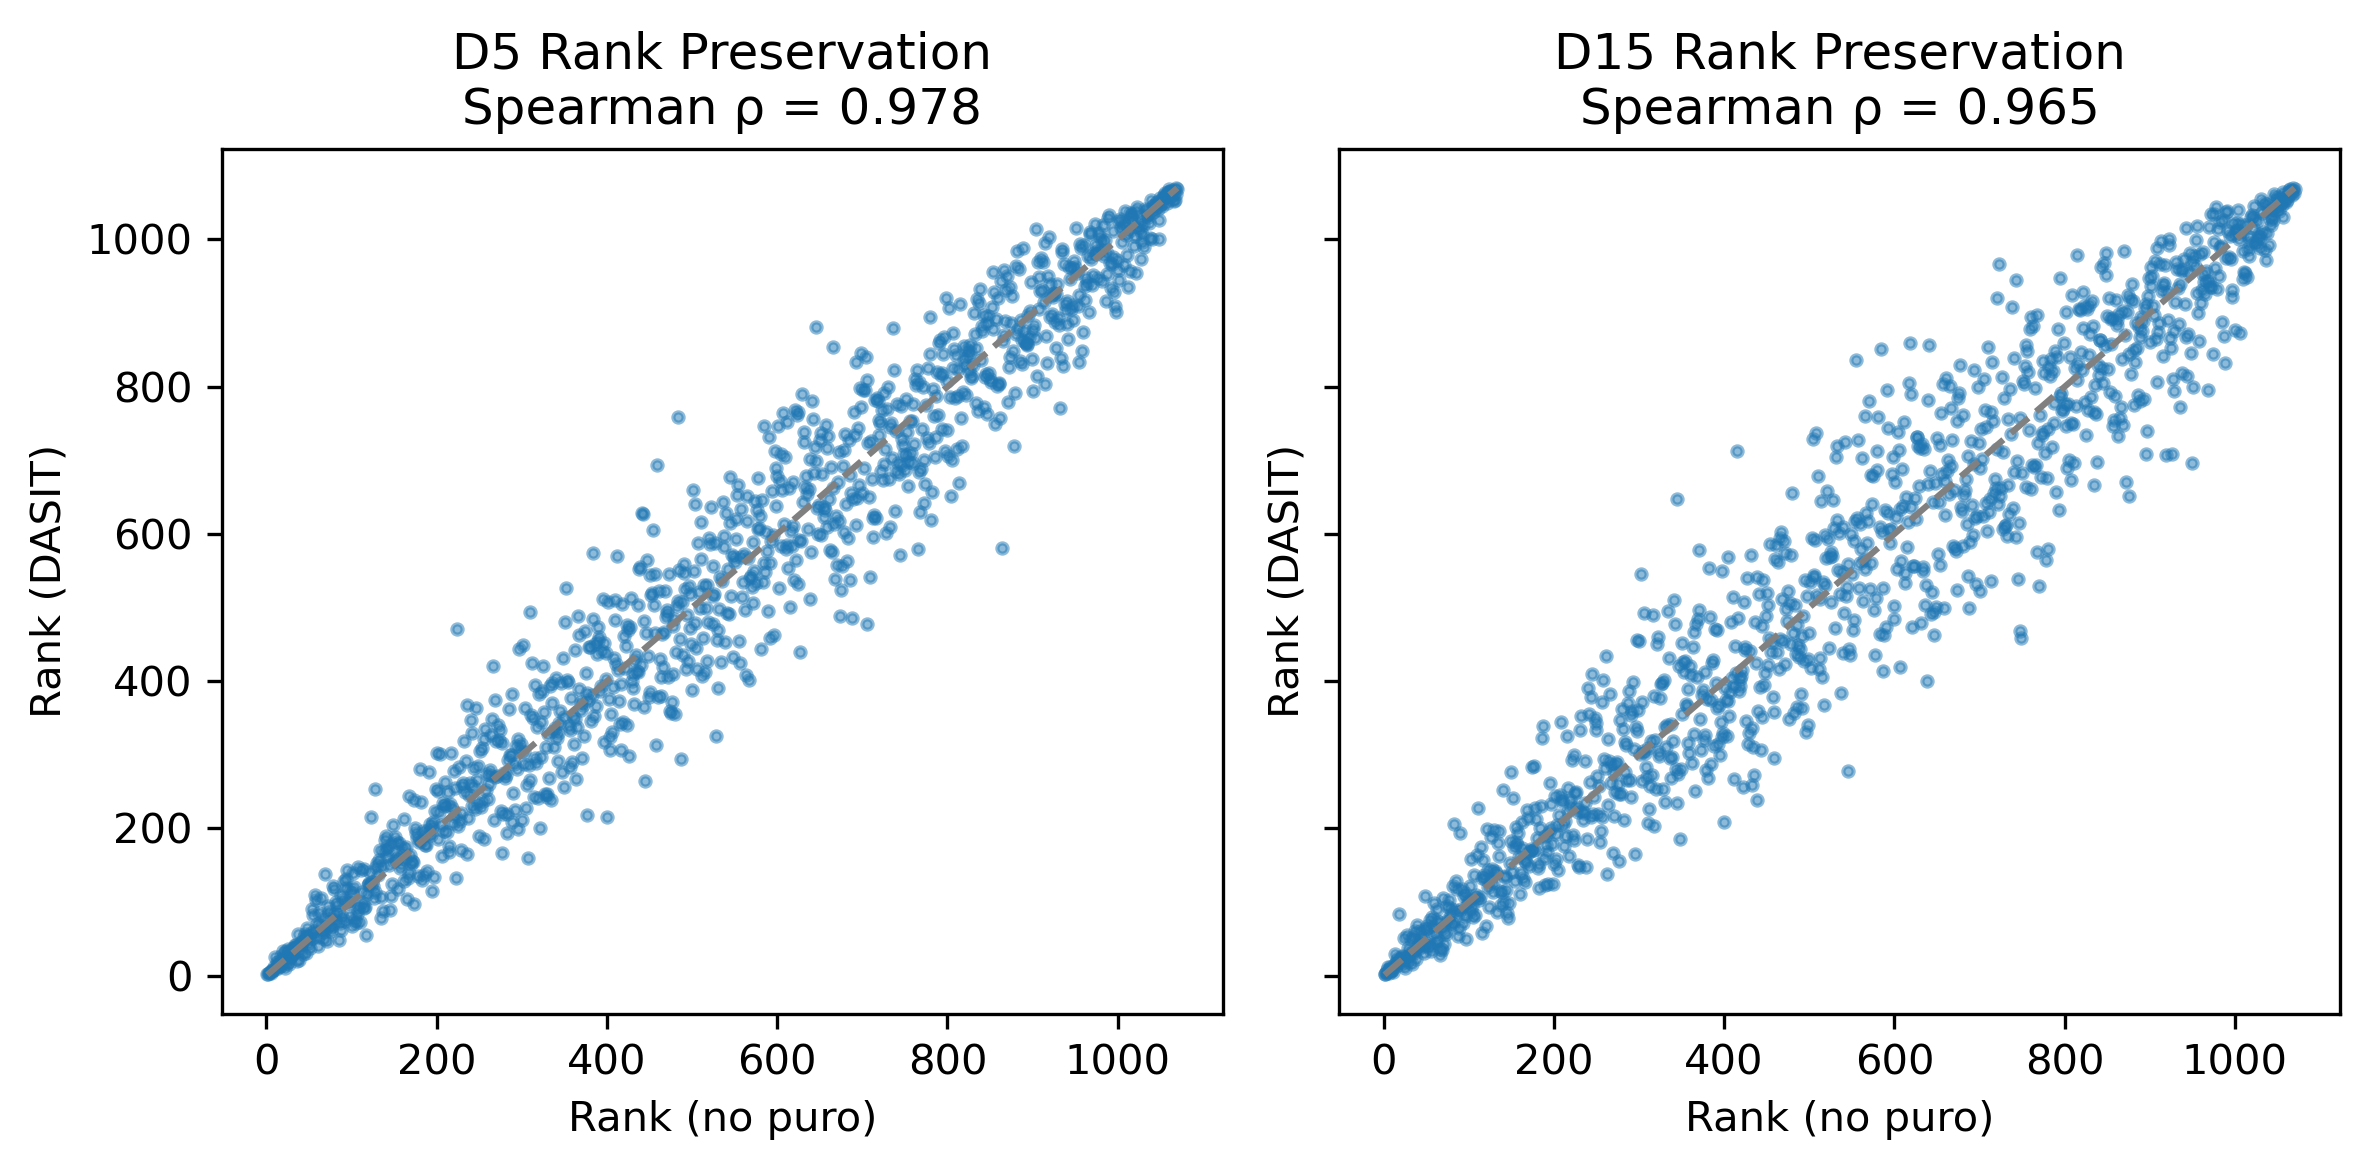

In [57]:
# looking at relative ordering of guides after DASIT selection

# D5 ranks
no_puro["rank_D5"] = no_puro["logCPM_D5"].rank(method="average")
puro["rank_D5"]    = puro["logCPM_D5"].rank(method="average")

# D15 ranks
no_puro["rank_D15"] = no_puro["logCPM_D15"].rank(method="average")
puro["rank_D15"]    = puro["logCPM_D15"].rank(method="average")

rho_D5, _  = spearmanr(no_puro["rank_D5"],  puro["rank_D5"])
rho_D15, _ = spearmanr(no_puro["rank_D15"], puro["rank_D15"])

rho_D5, rho_D15

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

for ax, tp, rho in zip(
    axes,
    ["D5", "D15"],
    [rho_D5, rho_D15]
):
    ax.scatter(
        no_puro[f"rank_{tp}"],
        puro[f"rank_{tp}"],
        s=6,
        alpha=0.5
    )
    ax.plot(
        [1, len(no_puro)],
        [1, len(no_puro)],
        ls="--",
        color="gray"
    )
    ax.set_title(f"{tp} Rank Preservation\nSpearman ρ = {rho:.3f}")
    ax.set_xlabel("Rank (no puro)")
    ax.set_ylabel("Rank (DASIT)")

plt.tight_layout()
plt.show()



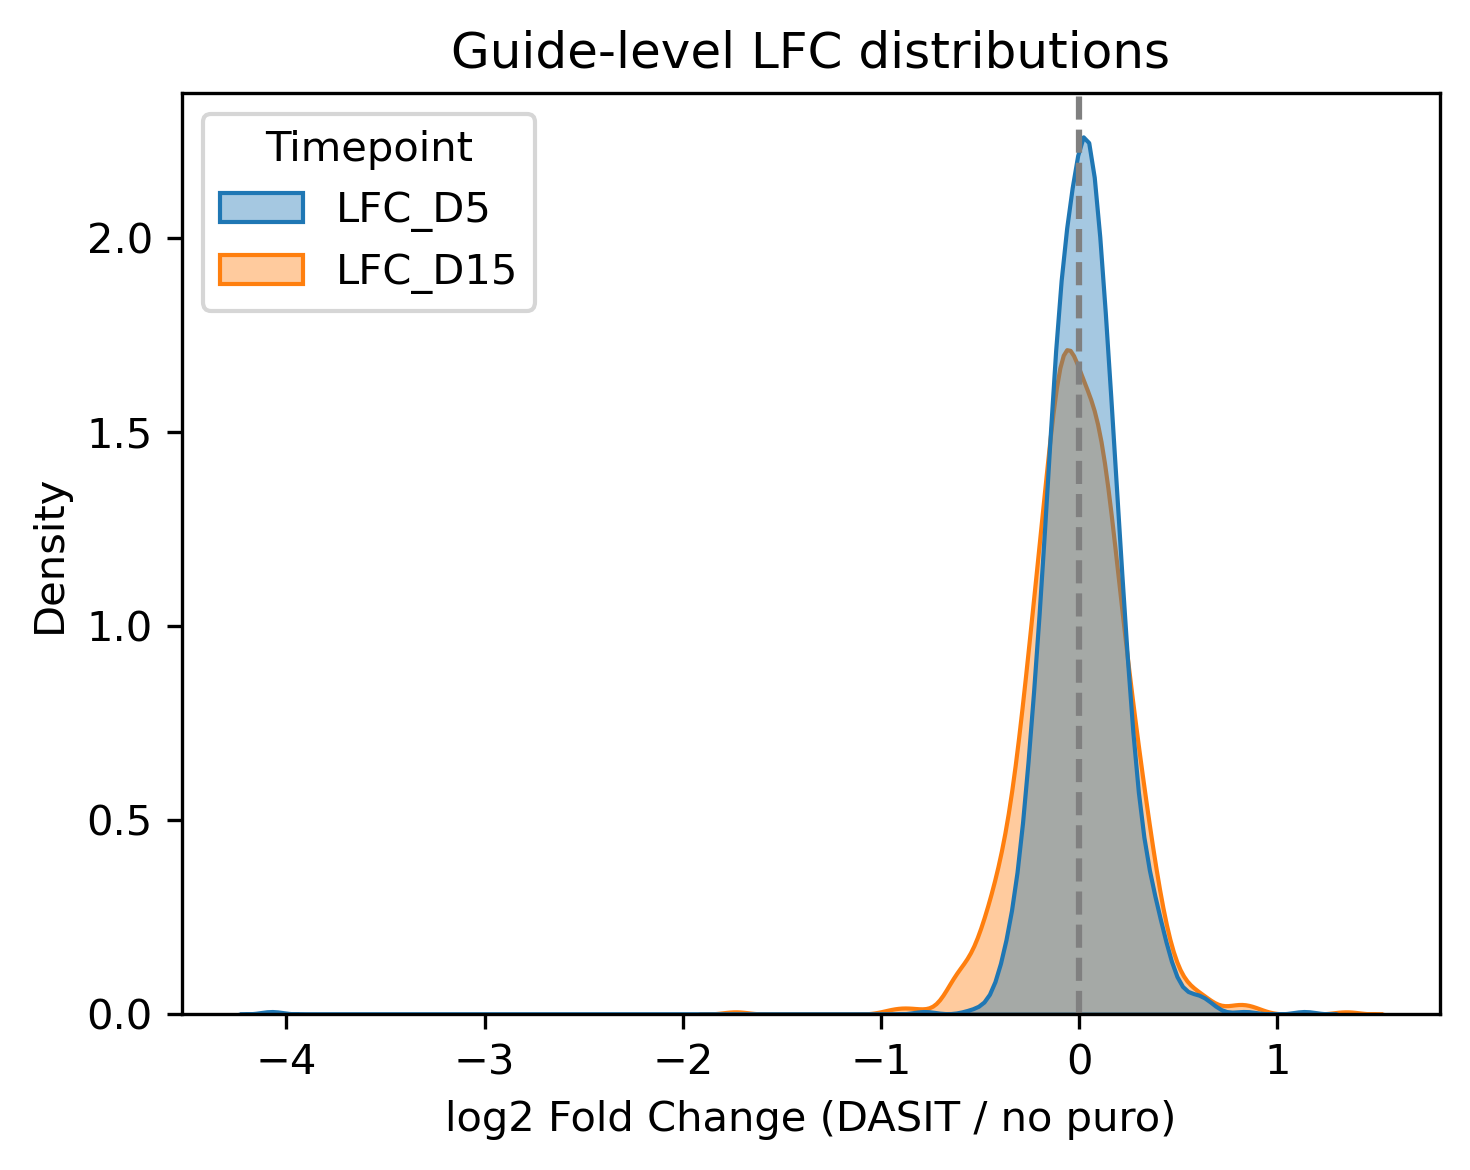

In [56]:
# doing some of my own LFC stuff 

# Pseudocount to stabilize low CPM guides
eps = 1

# Mean counts across replicates
no_puro["D5_mean"]  = no_puro[["d5_rep1","d5_rep2","d5_rep3"]].mean(axis=1)
no_puro["D15_mean"] = no_puro[["d15_rep1","d15_rep2","d15_rep3"]].mean(axis=1)

puro["D5_mean"]  = puro[["d5_rep1","d5_rep2","d5_rep3"]].mean(axis=1)
puro["D15_mean"] = puro[["d15_rep1","d15_rep2","d15_rep3"]].mean(axis=1)

def to_cpm(x):
    return (x / x.sum()) * 1e6

# CPM normalization
no_puro["CPM_D5"]  = to_cpm(no_puro["D5_mean"])
no_puro["CPM_D15"] = to_cpm(no_puro["D15_mean"])

puro["CPM_D5"]  = to_cpm(puro["D5_mean"])
puro["CPM_D15"] = to_cpm(puro["D15_mean"])

no_puro["logCPM_D5"]  = np.log10(no_puro["CPM_D5"]  + 1)
no_puro["logCPM_D15"] = np.log10(no_puro["CPM_D15"] + 1)

puro["logCPM_D5"]  = np.log10(puro["CPM_D5"]  + 1)
puro["logCPM_D15"] = np.log10(puro["CPM_D15"] + 1)



# LFCs
lfc = pd.DataFrame({
    "sgRNA": no_puro["sgRNA"],
    "gene": no_puro["gene"],
    "LFC_D5":  np.log2((puro["CPM_D5"]  + eps) / (no_puro["CPM_D5"]  + eps)),
    "LFC_D15": np.log2((puro["CPM_D15"] + eps) / (no_puro["CPM_D15"] + eps)),
})

lfc_long = lfc.melt(
    id_vars=["sgRNA", "gene"],
    value_vars=["LFC_D5", "LFC_D15"],
    var_name="Timepoint",
    value_name="LFC"
)
# Distribution check
lfc[["LFC_D5","LFC_D15"]].describe()

# Means should be ~0
lfc[["LFC_D5","LFC_D15"]].mean()


plt.figure(figsize=(5,4))
sns.kdeplot(
    data=lfc_long,
    x="LFC",
    hue="Timepoint",
    common_norm=False,
    fill=True,
    alpha=0.4
)
plt.axvline(0, ls="--", color="gray")
plt.xlabel("log2 Fold Change (DASIT / no puro)")
plt.title("Guide-level LFC distributions")
plt.tight_layout()
plt.show()


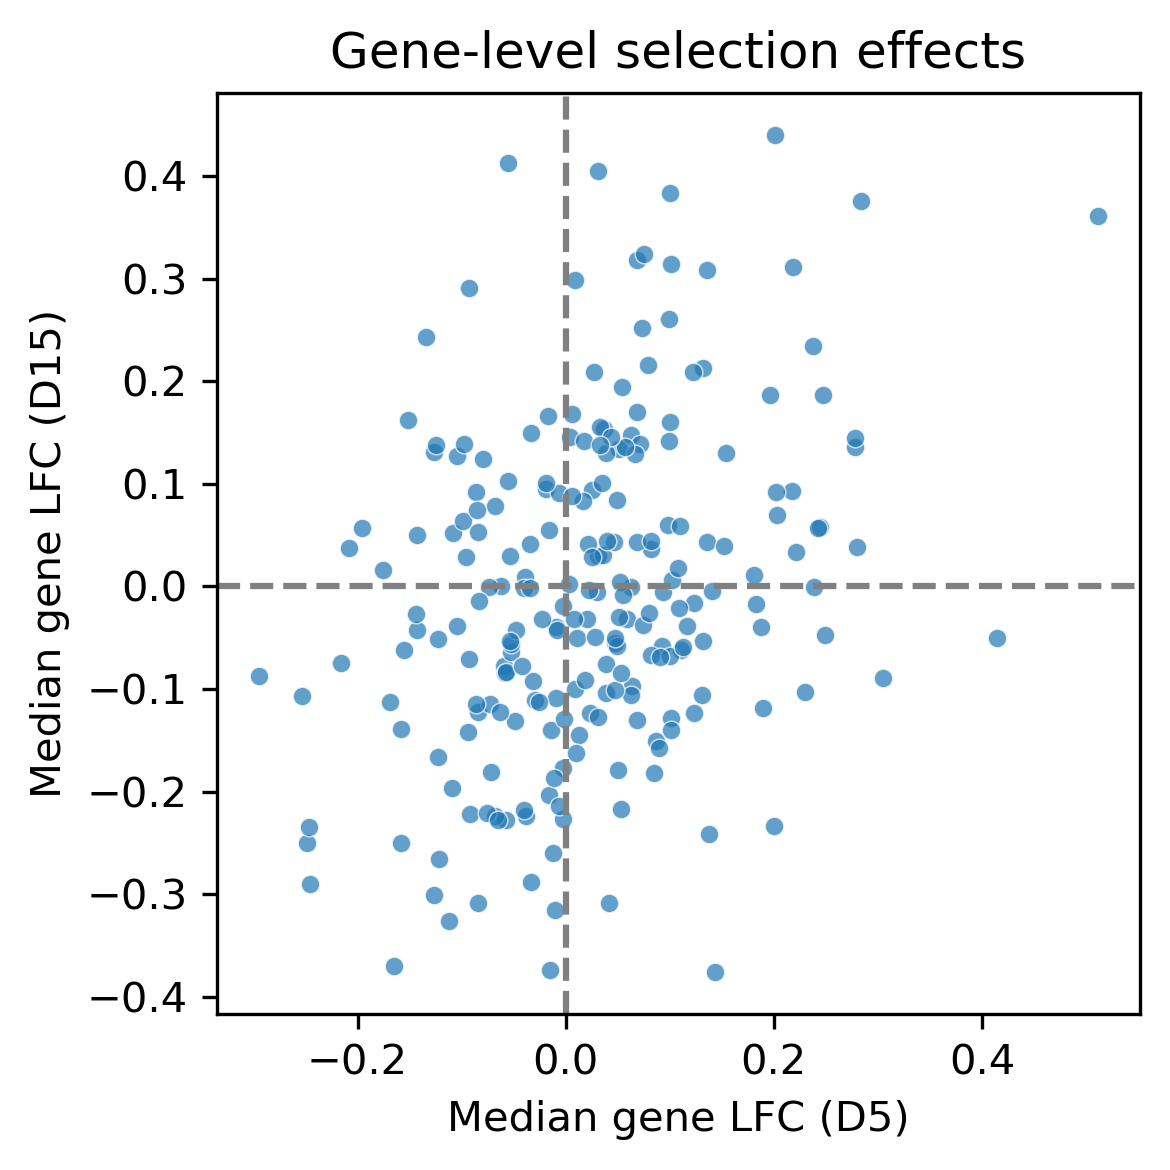

,gene,LFC_D5,LFC_D15
51,DOT1L,0.201029,0.440069
124,MAX,-0.055865,0.412661
109,KDR,0.030976,0.404733
99,INPPL1,0.100128,0.383262
193,SH2B3,0.283507,0.376021
31,CCND1,0.511545,0.361047
104,JAK1,0.075225,0.324305
85,FYN,0.068287,0.318384
53,DTX1,0.100981,0.313991
184,RNF43,0.218721,0.310800


In [58]:
gene_lfc = (
    lfc
    .groupby("gene")[["LFC_D5", "LFC_D15"]]
    .median()
    .reset_index()
)

plt.figure(figsize=(4,4))
sns.scatterplot(
    data=gene_lfc,
    x="LFC_D5",
    y="LFC_D15",
    s=20,
    alpha=0.7
)
plt.axhline(0, ls="--", color="gray")
plt.axvline(0, ls="--", color="gray")
plt.xlabel("Median gene LFC (D5)")
plt.ylabel("Median gene LFC (D15)")
plt.title("Gene-level selection effects")
plt.tight_layout()
plt.show()

r_gene = pearsonr(gene_lfc["LFC_D5"], gene_lfc["LFC_D15"])[0]
r_gene

gene_lfc_sorted = gene_lfc.sort_values("LFC_D15", ascending=False)
gene_lfc_sorted.head(10)



In [59]:
def skew_ratio(lfc, q=0.1):
    lower = abs(lfc.quantile(q))
    upper = lfc.quantile(1 - q)
    return lower / upper

skew_ratio(puro["LFC_median_d5"])


KeyError: 'LFC_median_d5'

Text(0, 0.5, 'Density')

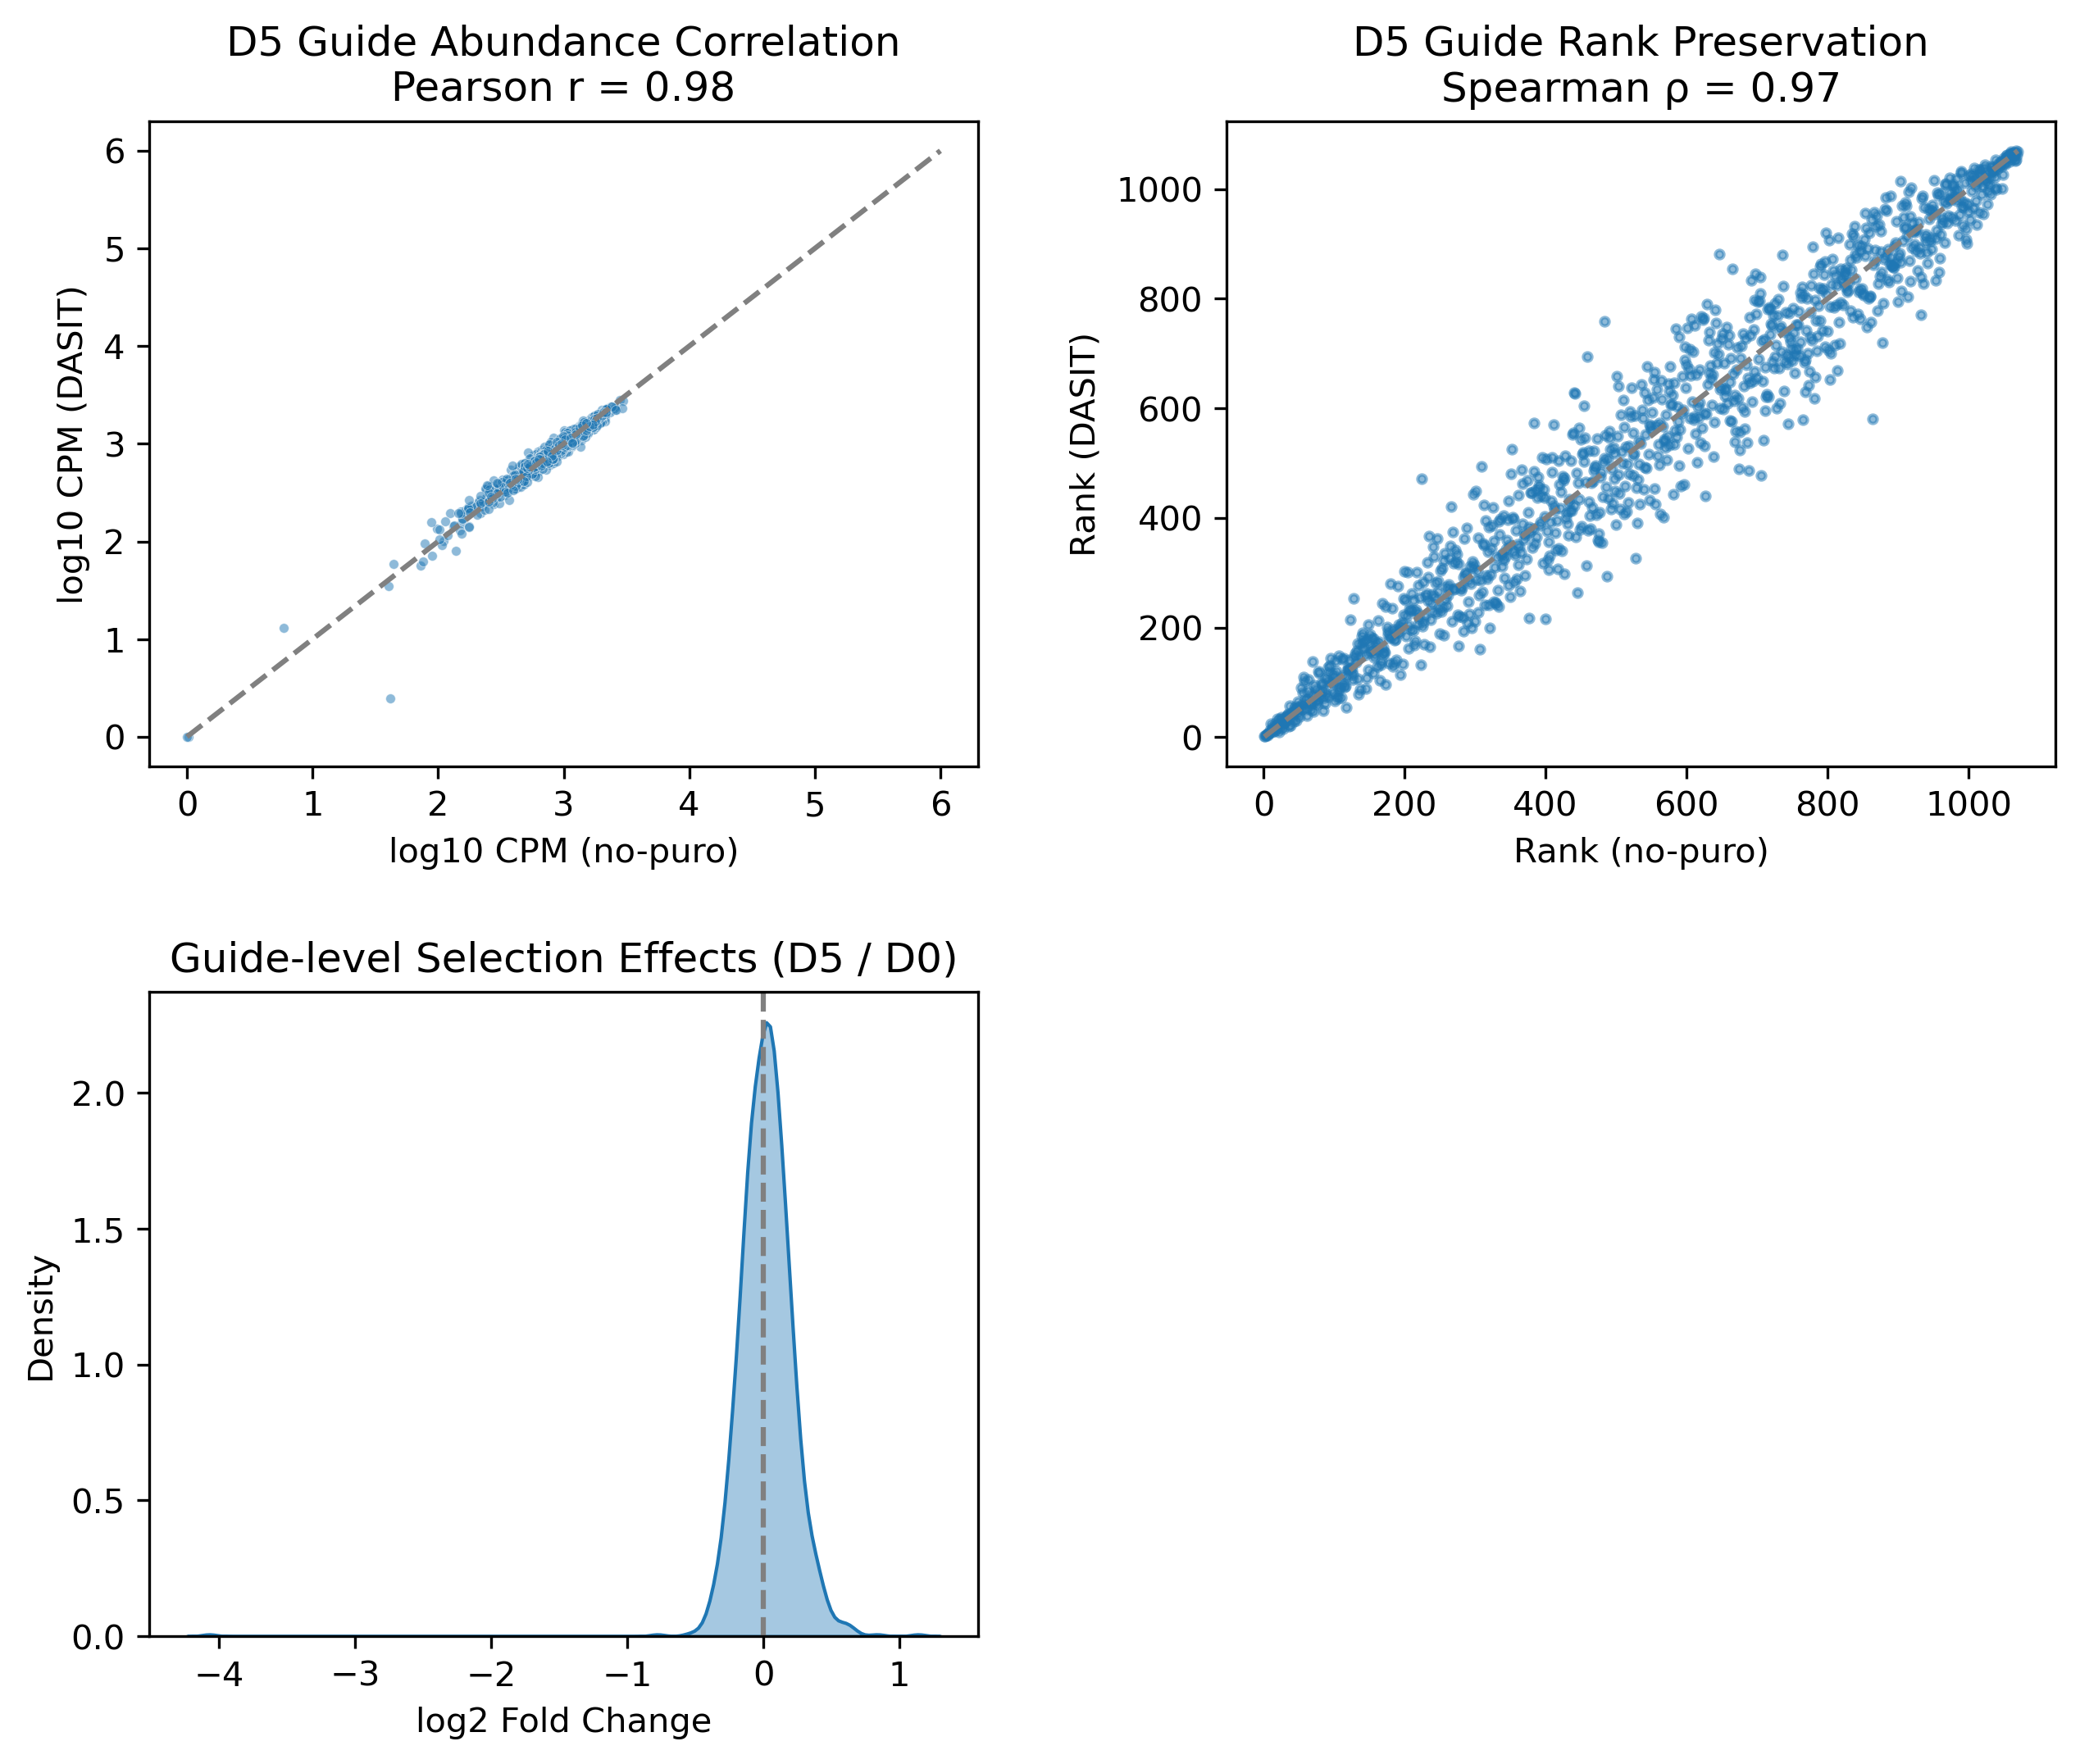

In [60]:
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])


sns.scatterplot(
    x=no_puro["logCPM_D5"],
    y=puro["logCPM_D5"],
    s=8,
    alpha=0.5,
    ax=axA
)
axA.plot([0,6], [0,6], ls="--", color="gray")
axA.set_title("D5 Guide Abundance Correlation\nPearson r = 0.98")
axA.set_xlabel("log10 CPM (no-puro)")
axA.set_ylabel("log10 CPM (DASIT)")

axB.scatter(
    no_puro["rank_D5"],
    puro["rank_D5"],
    s=6,
    alpha=0.5
)
axB.plot([1, len(no_puro)], [1, len(no_puro)], ls="--", color="gray")
axB.set_title("D5 Guide Rank Preservation\nSpearman ρ = 0.97")
axB.set_xlabel("Rank (no-puro)")
axB.set_ylabel("Rank (DASIT)")

sns.kdeplot(
    lfc["LFC_D5"],
    fill=True,
    alpha=0.4,
    ax=axC
)
axC.axvline(0, ls="--", color="gray")
axC.set_title("Guide-level Selection Effects (D5 / D0)")
axC.set_xlabel("log2 Fold Change")
axC.set_ylabel("Density")





In [61]:
lfc = puro["LFC_median_d5"]

print("Bottom 10% median:", lfc.quantile(0.10))
print("Top 10% median:",    lfc.quantile(0.90))


KeyError: 'LFC_median_d5'

0        True
1       False
2        True
3        True
4        True
        ...  
1065     True
1066     True
1067     True
1068     True
1069     True
Name: d0_rep1, Length: 1070, dtype: bool
99.25233644859813
0       True
1       True
2       True
3       True
4       True
        ... 
1065    True
1066    True
1067    True
1068    True
1069    True
Name: d0_rep2, Length: 1070, dtype: bool
99.34579439252337
0        True
1       False
2        True
3        True
4        True
        ...  
1065     True
1066     True
1067     True
1068     True
1069     True
Name: d0_rep3, Length: 1070, dtype: bool
98.97196261682242
0       True
1       True
2       True
3       True
4       True
        ... 
1065    True
1066    True
1067    True
1068    True
1069    True
Name: d5_rep1, Length: 1070, dtype: bool
98.97196261682242
0       True
1       True
2       True
3       True
4       True
        ... 
1065    True
1066    True
1067    True
1068    True
1069    True
Name: d5_rep2, Length: 1070

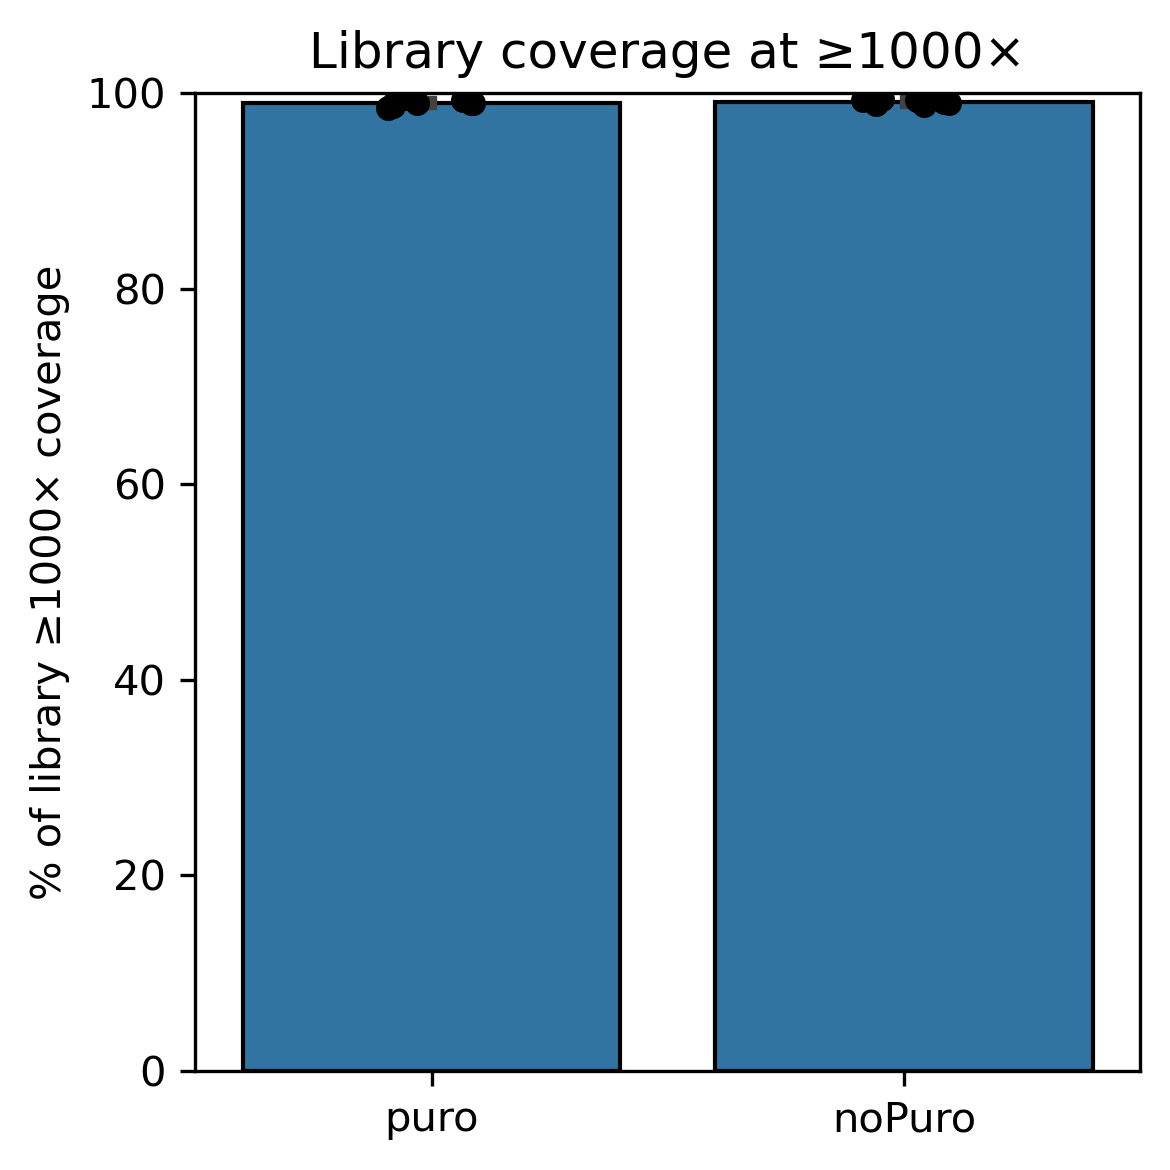

In [62]:


# Load counts
puro_counts = pd.read_csv(OUTDIR / "guide_counts_puro.txt", sep="\t")
noPuro_counts = pd.read_csv(OUTDIR / "guide_counts_noPuro.txt", sep="\t")

# Drop metadata columns (adjust if needed)
puro_counts = puro_counts[puro_counts.columns[2:]]
noPuro_counts = noPuro_counts[noPuro_counts.columns[2:]]

threshold = 1000

def percent_above_threshold(count_df, condition):
    records = []
    for sample in count_df.columns:
        pct = (count_df[sample] >= threshold).mean() * 100
        print(count_df[sample] >= threshold)
        print(pct)
        records.append({
            "Sample": sample,
            "Condition": condition,
            "Percent_1000x": pct
        })
    return pd.DataFrame(records)

puro_pct = percent_above_threshold(puro_counts, "puro")
noPuro_pct = percent_above_threshold(noPuro_counts, "noPuro")

pct_df = pd.concat([puro_pct, noPuro_pct], ignore_index=True)

print(pct_df)

plt.figure(figsize=(4,4))

sns.barplot(
    data=pct_df,
    x="Condition",
    y="Percent_1000x",
    edgecolor="black",
    ci="sd"
)

sns.stripplot(
    data=pct_df,
    x="Condition",
    y="Percent_1000x",
    color="black",
    size=6,
    jitter=True
)

plt.ylabel("% of library ≥1000× coverage")
plt.xlabel("")
plt.title("Library coverage at ≥1000×")
plt.ylim(0, 100)[]
plt.tight_layout()
plt.show()



Guides passing edit filter: 836
Guides passing edit filter: 849
Counts after filtering:
puro: (849, 10)
noPuro: (836, 10)


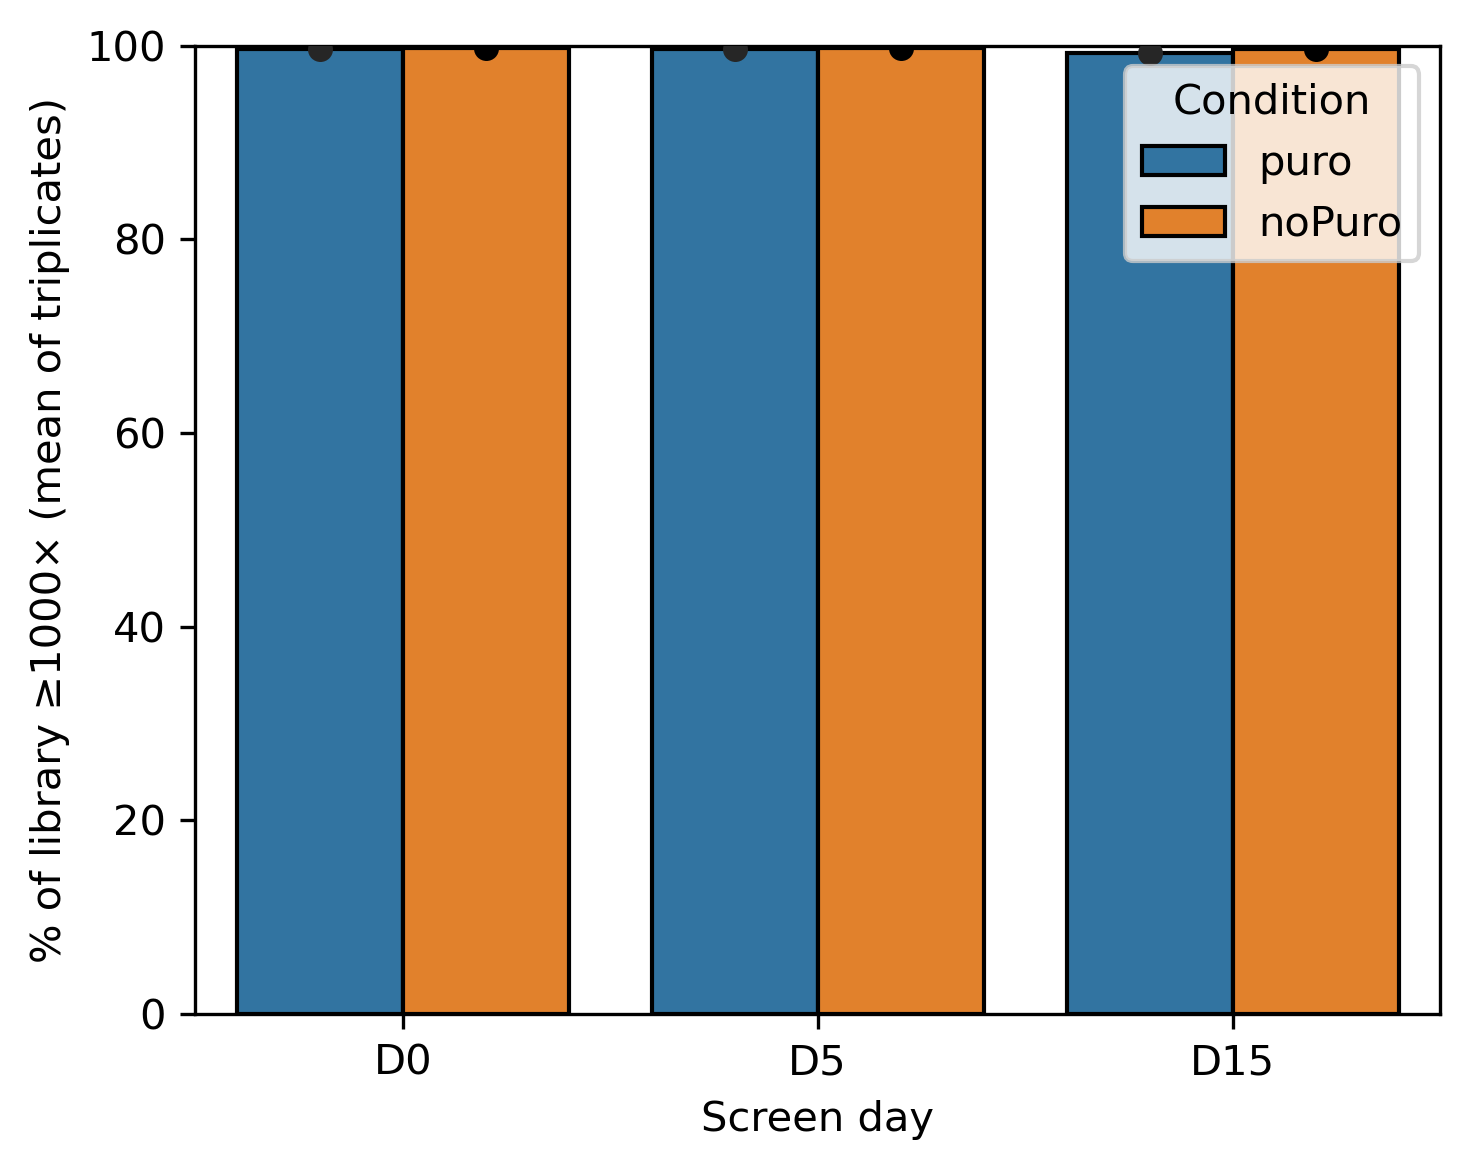

In [93]:
# load editing information
edit_df_puro = pd.read_csv(OUTDIR / "puro_LFC_FDR_df.csv", sep=",")
edit_df_nopuro = pd.read_csv(OUTDIR / "noPuro_LFC_FDR_df.csv", sep=",")

# keep only guides with >=20% target base editing
edit_guides_nopuro = (
    edit_df_nopuro
    .loc[edit_df_nopuro["target_base_edit_perc"] >= 20, "gRNA_id"]
    .astype(str)
)
edit_guides_nopuro = set(edit_guides_nopuro)
print(f"Guides passing edit filter: {len(edit_guides_nopuro)}")

edit_guides_puro = (
    edit_df_puro
    .loc[edit_df_puro["target_base_edit_perc"] >= 20, "gRNA_id"]
    .astype(str)
)
edit_guides_puro = set(edit_guides_puro)
print(f"Guides passing edit filter: {len(edit_guides_puro)}")

puro_counts = pd.read_csv(OUTDIR / "guide_counts_puro.txt", sep="\t", index_col=0)
noPuro_counts = pd.read_csv(OUTDIR / "guide_counts_noPuro.txt", sep="\t", index_col=0)

puro_counts_filt = puro_counts.loc[puro_counts.index.isin(edit_guides_puro)]
noPuro_counts_filt = noPuro_counts.loc[noPuro_counts.index.isin(edit_guides_nopuro)]

print("Counts after filtering:")
print("puro:", puro_counts_filt.shape)
print("noPuro:", noPuro_counts_filt.shape)

rep_groups = {
    "D0":  ["d0_rep1", "d0_rep2", "d0_rep3"],
    "D5":  ["d5_rep1", "d5_rep2", "d5_rep3"],
    "D15": ["d15_rep1", "d15_rep2", "d15_rep3"],
}

threshold = 1000

def percent_above_threshold_by_day(count_df, condition):
    records = []

    for day, reps in rep_groups.items():
        # mean coverage per guide across triplicates
        mean_cov = count_df[reps].mean(axis=1)

        pct = (mean_cov >= threshold).mean() * 100

        records.append({
            "Day": day,
            "Condition": condition,
            "Percent_1000x": pct
        })

    return pd.DataFrame(records)

puro_pct = percent_above_threshold_by_day(puro_counts_filt, "puro")
noPuro_pct = percent_above_threshold_by_day(noPuro_counts_filt, "noPuro")

pct_df = pd.concat([puro_pct, noPuro_pct], ignore_index=True)

plt.figure(figsize=(5,4))

sns.barplot(
    data=pct_df,
    x="Day",
    y="Percent_1000x",
    hue="Condition",
    order=["D0", "D5", "D15"],
    edgecolor="black",
    ci=None
)

sns.stripplot(
    data=pct_df,
    x="Day",
    y="Percent_1000x",
    hue="Condition",
    order=["D0", "D5", "D15"],
    dodge=True,
    color="black",
    size=6,
    legend=False
)

plt.ylabel("% of library ≥1000× (mean of triplicates)")
plt.xlabel("Screen day")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()



In [63]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Sample": ["d0_rep1", "d5_rep2", "d15_rep3"]
})

df["Timepoint"] = (
    df["Sample"]
    .str.lower()
    .str.extract("(d0|d5|d15)")
    .str.upper()
)

df


AttributeError: 'DataFrame' object has no attribute 'str'

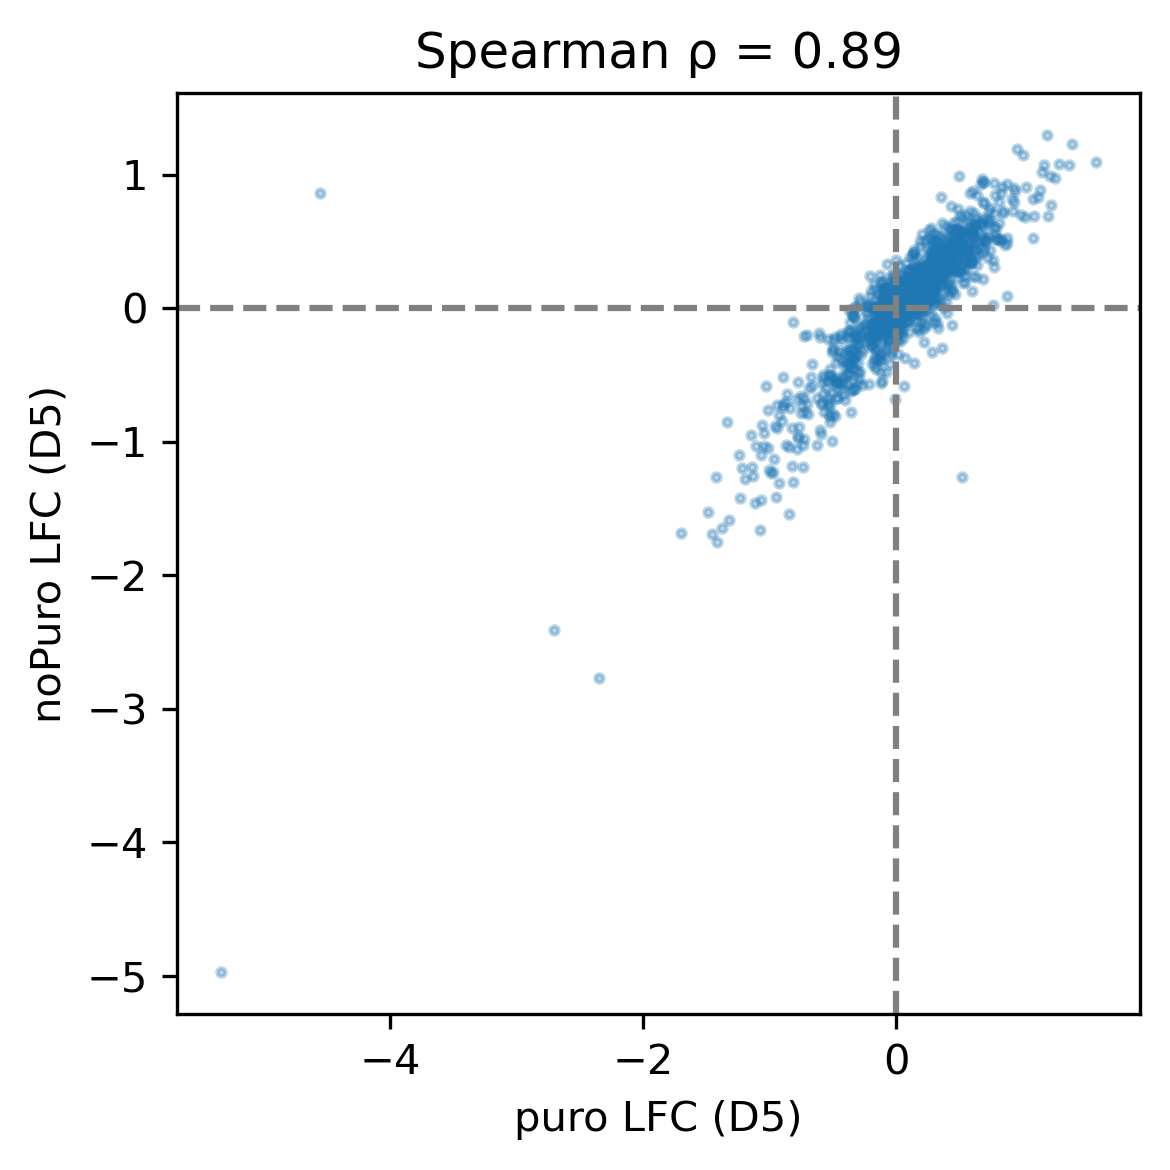

In [64]:
# set index once
puro = puro_LFC.set_index("gRNA_id")
noPuro = noPuro_LFC.set_index("gRNA_id")
abe = ABE_LFC.set_index("gRNA_id")

# keep only common gRNAs
puro, noPuro = puro.align(noPuro, join="inner", axis=0)
puro, abe = puro.align(abe, join="inner", axis=0)

x = puro["LFC_median_d5"]
y = noPuro["LFC_median_d5"]

rho = x.corr(y, method="spearman")

plt.figure(figsize=(4,4))
plt.scatter(x, y, s=4, alpha=0.3)
plt.axhline(0, ls="--", c="grey")
plt.axvline(0, ls="--", c="grey")
plt.xlabel("puro LFC (D5)")
plt.ylabel("noPuro LFC (D5)")
plt.title(f"Spearman ρ = {rho:.2f}")
plt.tight_layout()
plt.show()


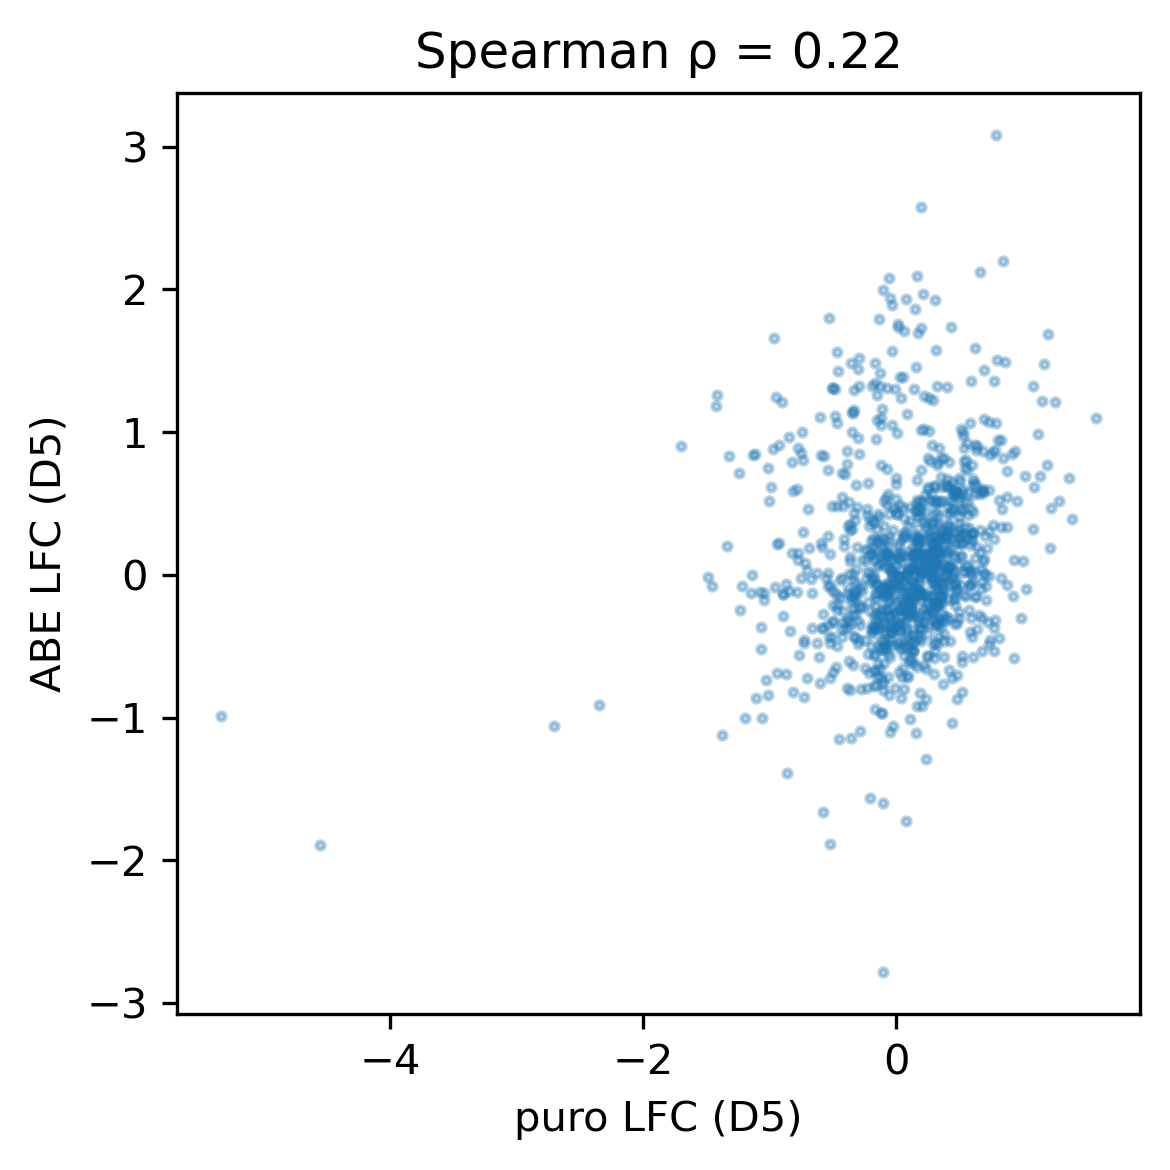

In [65]:
x = puro["LFC_median_d5"]
y = abe["LFC_median_d5"]

rho = x.corr(y, method="spearman")

plt.figure(figsize=(4,4))
plt.scatter(x, y, s=4, alpha=0.3)
plt.xlabel("puro LFC (D5)")
plt.ylabel("ABE LFC (D5)")
plt.title(f"Spearman ρ = {rho:.2f}")
plt.tight_layout()
plt.show()


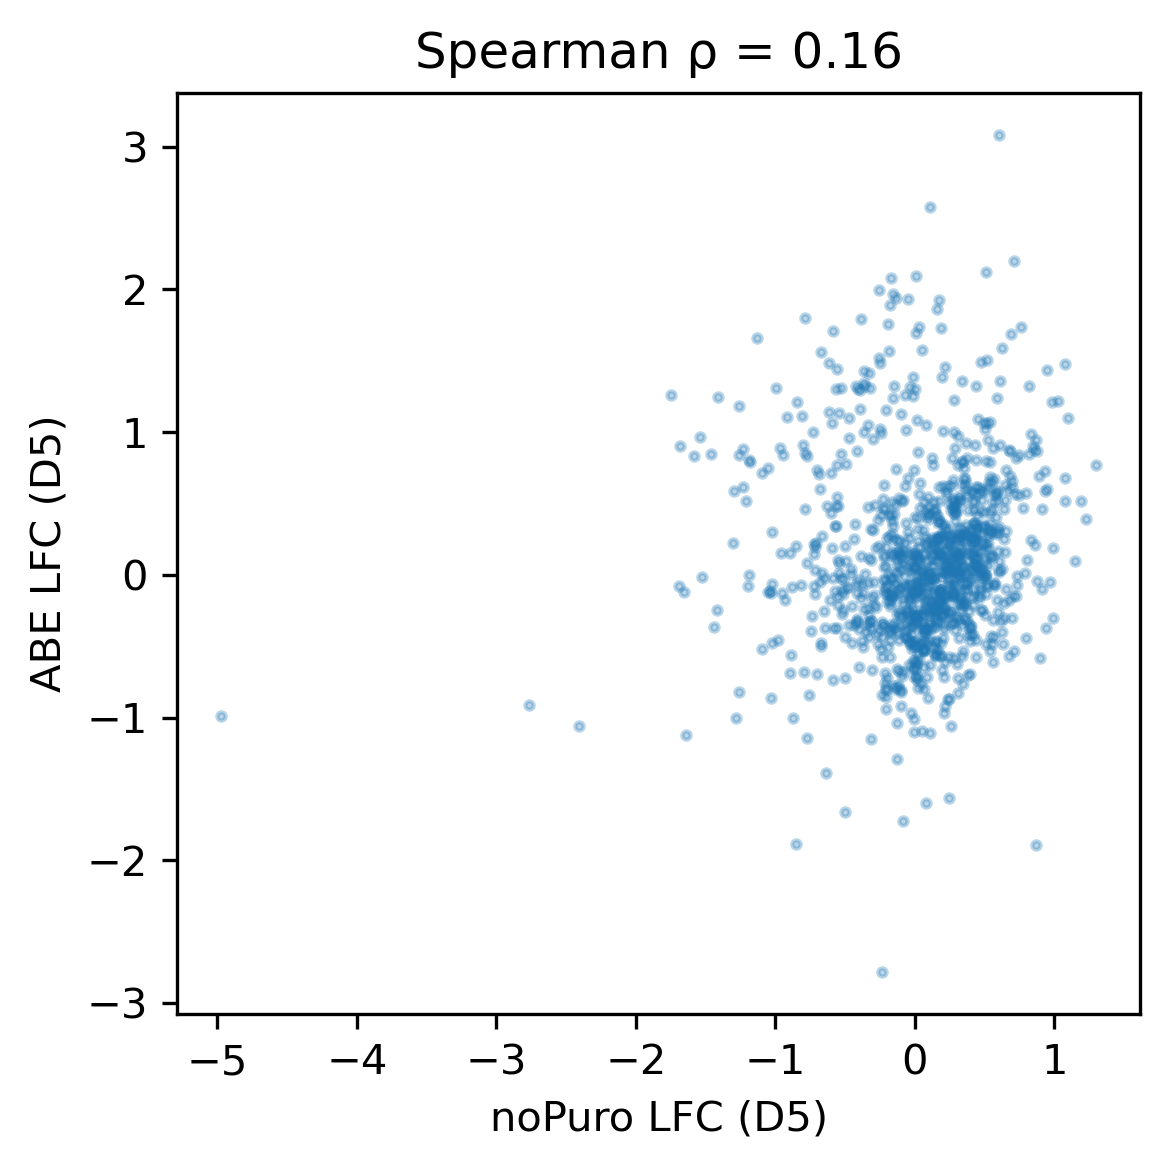

In [66]:
x = noPuro["LFC_median_d5"]
y = abe["LFC_median_d5"]

rho = x.corr(y, method="spearman")

plt.figure(figsize=(4,4))
plt.scatter(x, y, s=4, alpha=0.3)
plt.xlabel("noPuro LFC (D5)")
plt.ylabel("ABE LFC (D5)")
plt.title(f"Spearman ρ = {rho:.2f}")
plt.tight_layout()
plt.show()


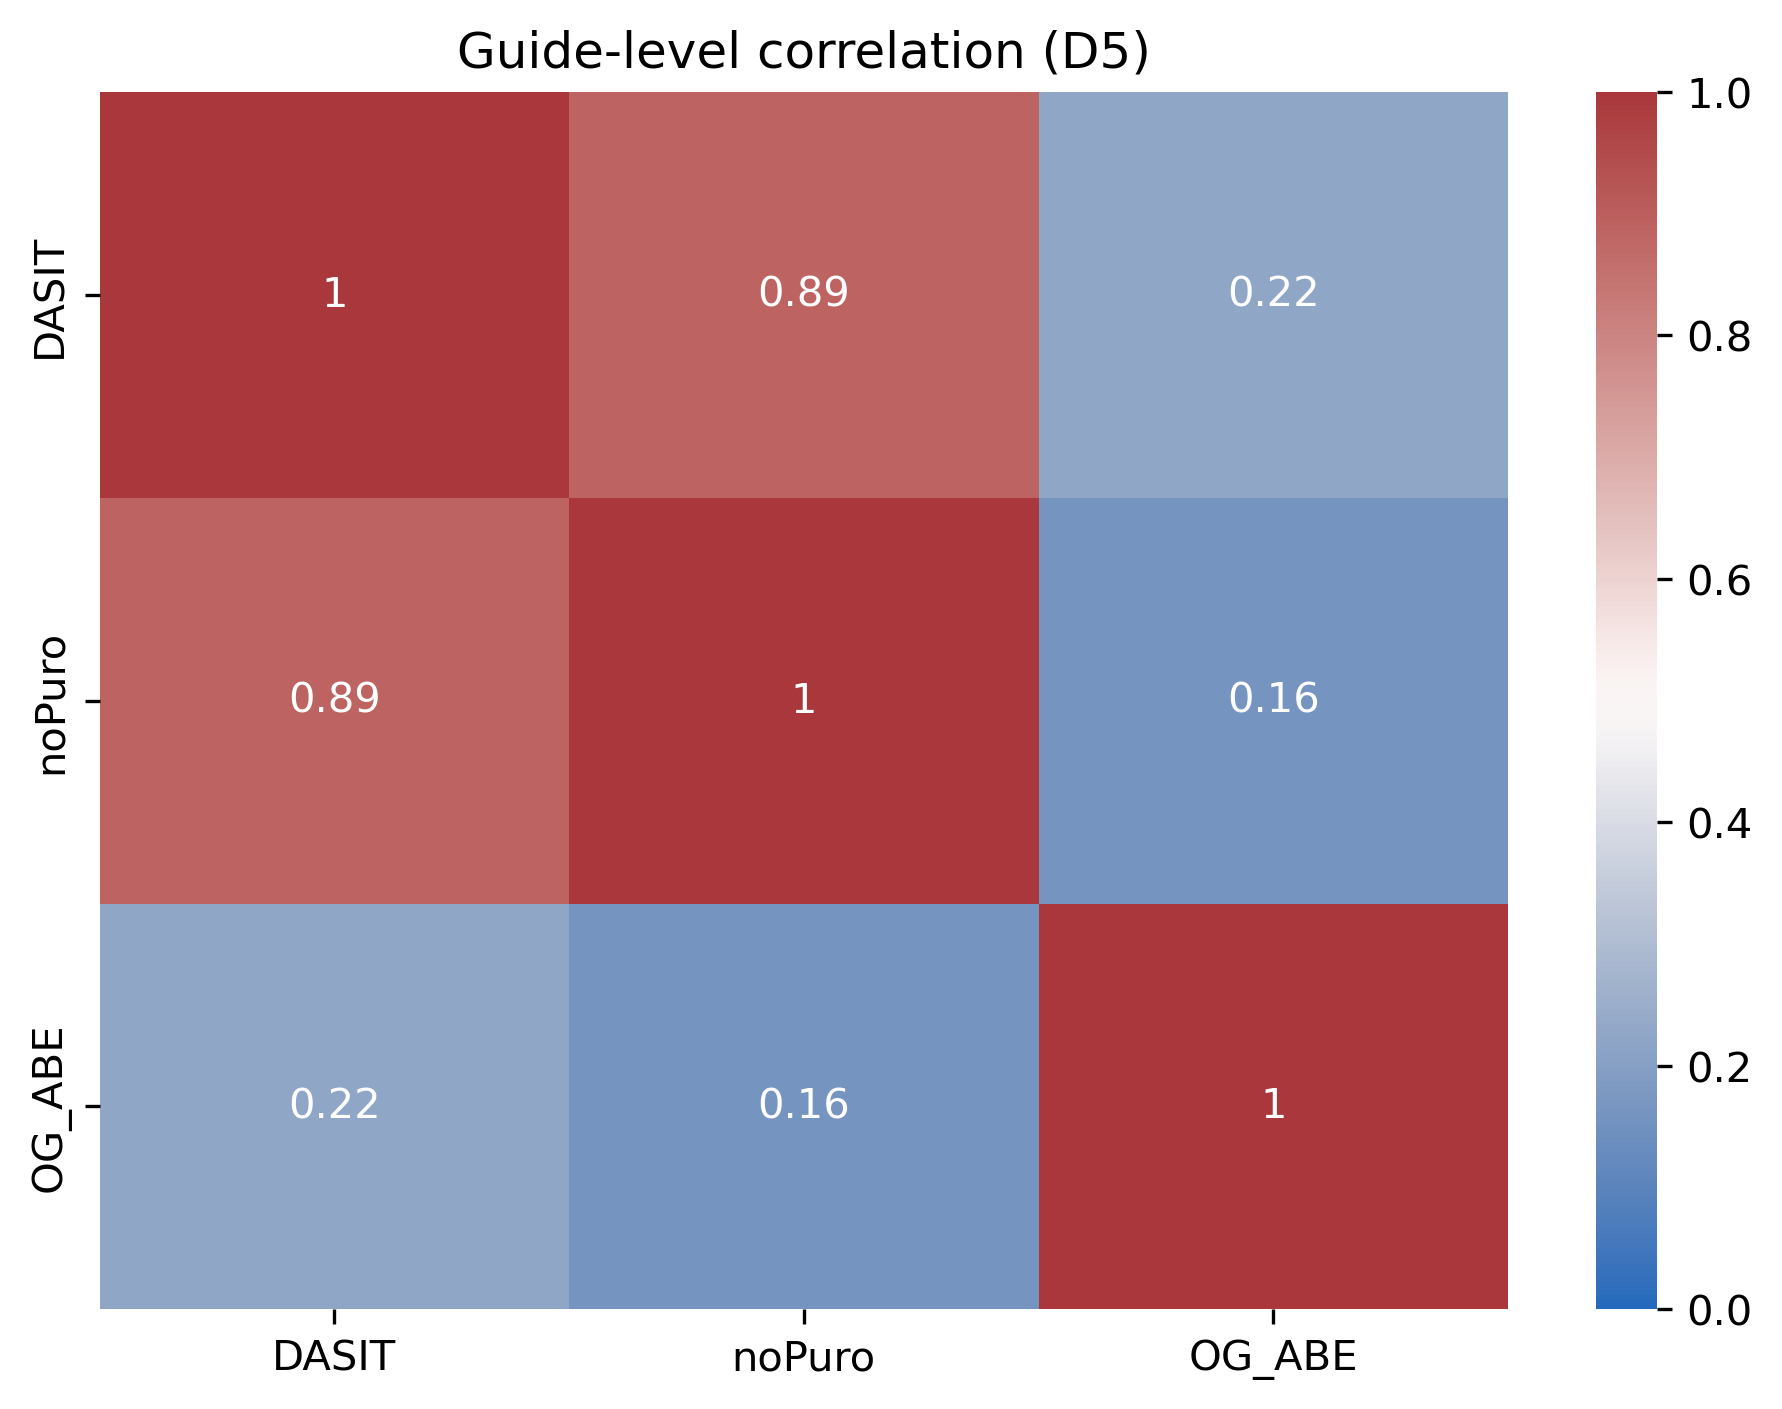

In [67]:
corr_df = pd.DataFrame({
    "DASIT": puro["LFC_median_d5"],
    "noPuro": noPuro["LFC_median_d5"],
    "OG_ABE": abe["LFC_median_d5"]
})

corr = corr_df.corr(method="spearman")

sns.heatmap(corr, annot=True, cmap="vlag", vmin=0, vmax=1)
plt.title("Guide-level correlation (D5)")
plt.tight_layout()
plt.show()


In [ ]:
#DOES THE CORRELATION IMPROVE WITH HIGHER EDITING EFFICIENCY GUIDES?

abe["target_base_edit_perc"].describe()

abe_filt = abe[abe["target_base_edit_perc"] >= 30]
puro_filt = puro.loc[abe_filt.index]

abe_filt["LFC_median_d5"].corr(
    puro_filt["LFC_median_d5"],
    method="spearman"
)



[65.48068669 12.12124584]


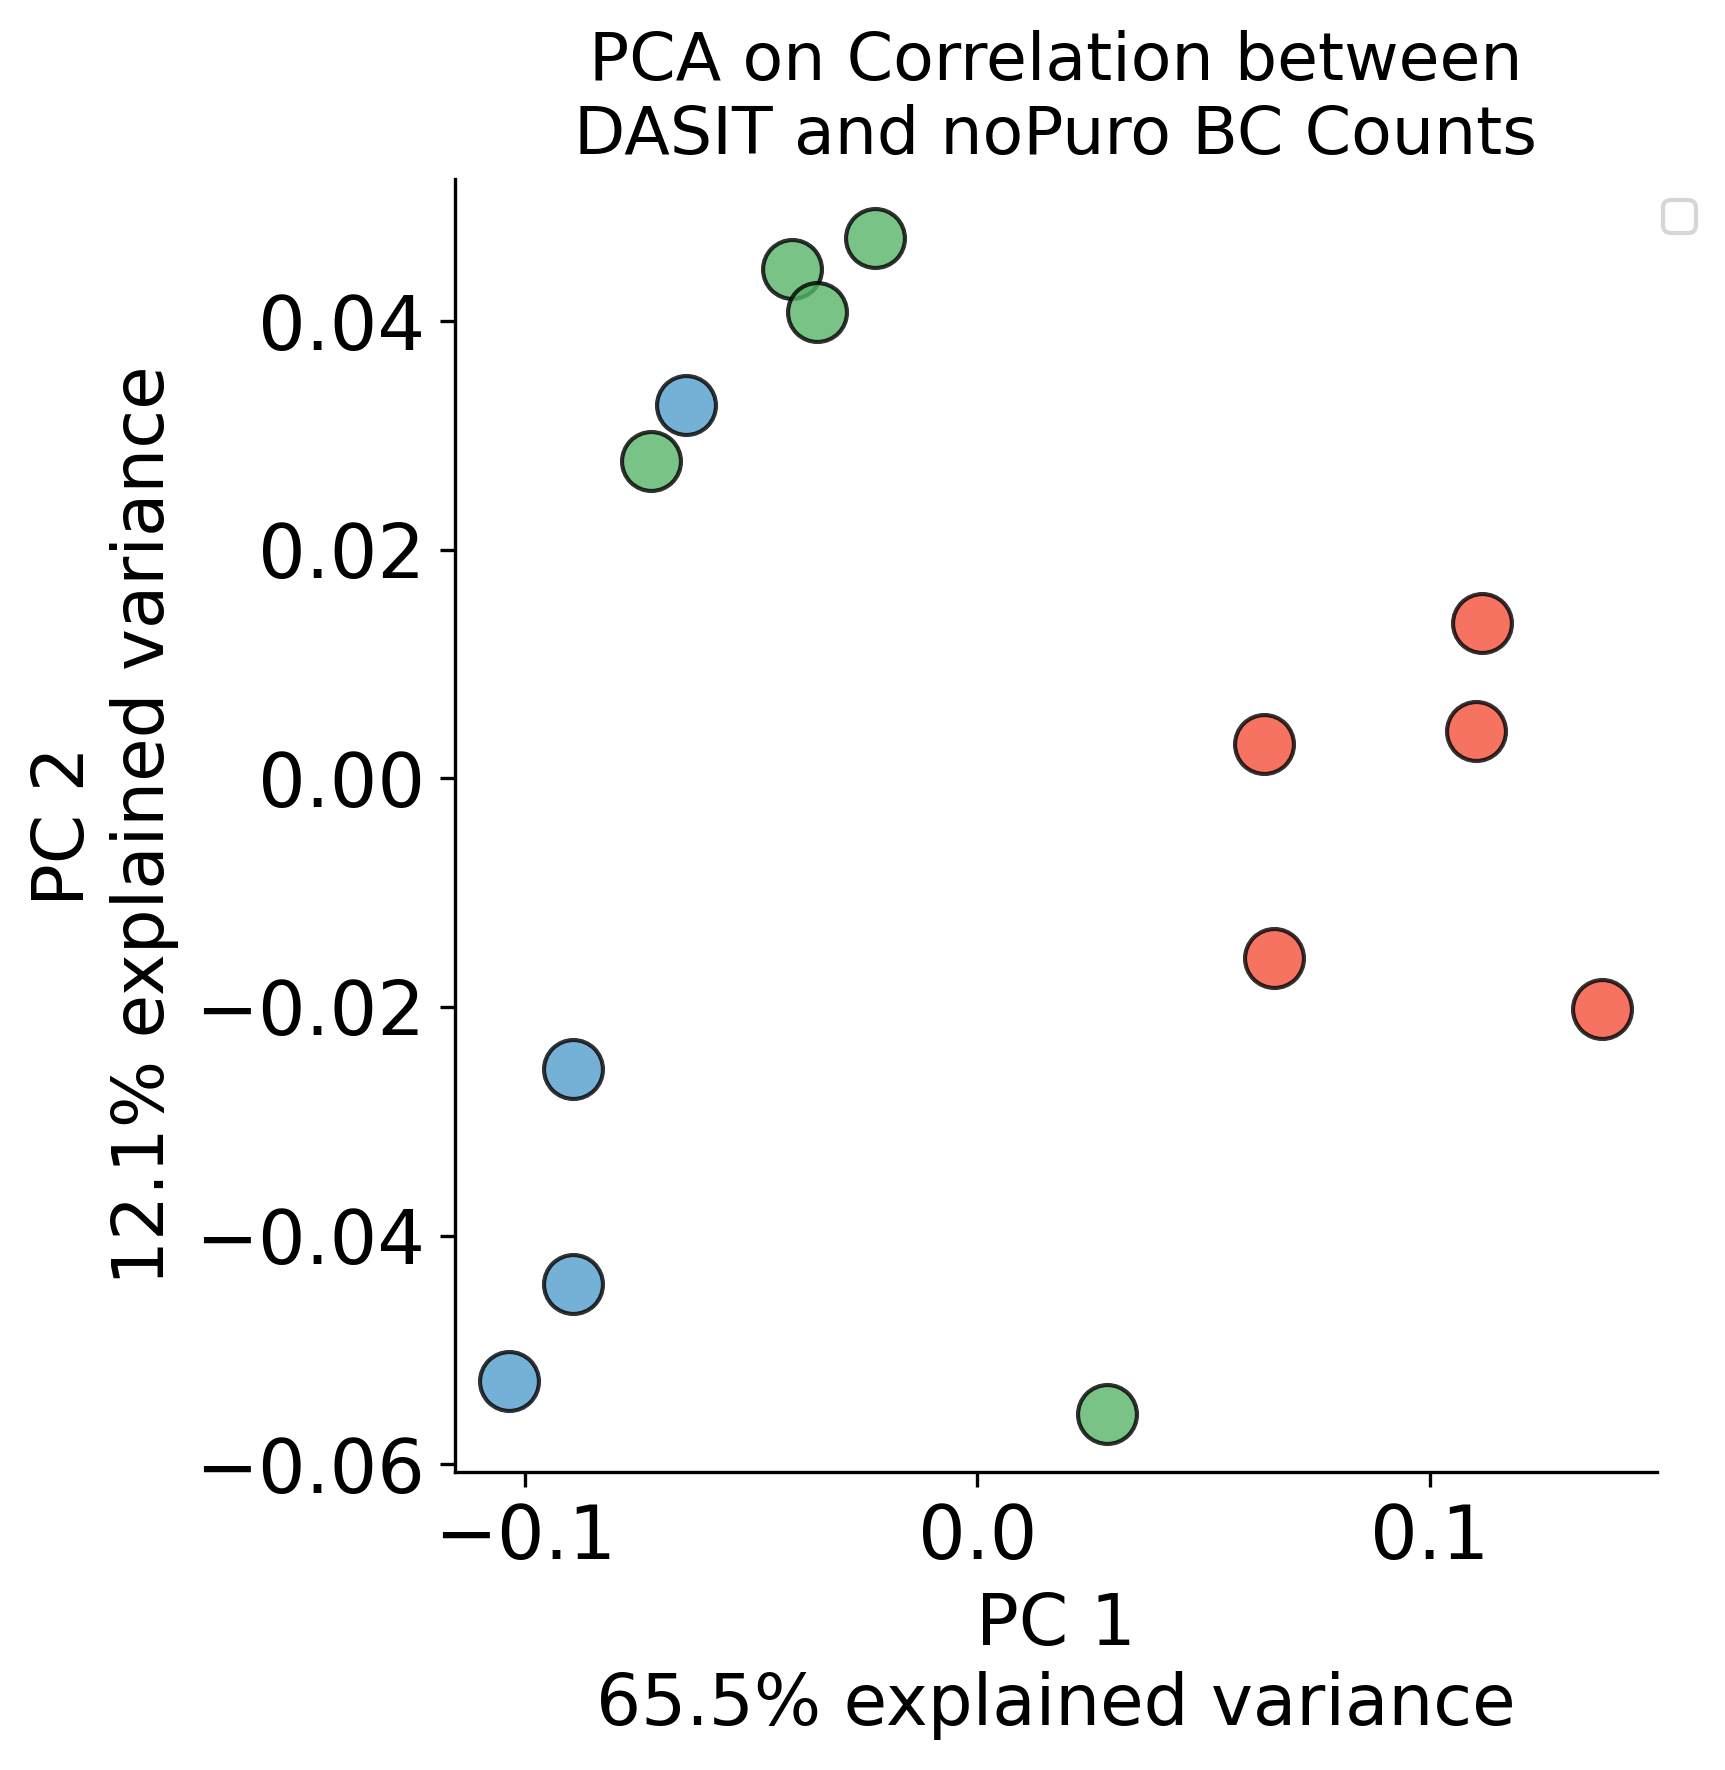

In [68]:
from sklearn.decomposition import PCA

all_counts = pd.read_csv(OUTDIR / 'guide_counts_ABE_DASIT.txt', sep='\t')
all_counts = all_counts[all_counts.columns[5:]]

pca = PCA(n_components=2)
Xt = pca.fit_transform(all_counts.corr(method='spearman'))
fig, ax = plt.subplots(figsize=(6,6))

blues = sns.color_palette('Blues')
greens = sns.color_palette('Greens')
reds = sns.color_palette('Reds')
yellows = sns.color_palette('Oranges')
purples = sns.color_palette('Purples')


blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = [blues[0], blues[2], blues[3], blues[5], greens[1], greens[2], greens[3], greens[4], greens[5],  reds[1], reds[2], reds[3], reds[4], reds[5],
           yellows[1], yellows[2], yellows[3], purples[0], purples[1], purples[2], purples[3], purples[4], purples[5], 'black']



palette = [blues[3], blues[3], blues[3], blues[3], greens[3], greens[3], greens[3], greens[3], greens[3],  reds[3], reds[3], reds[3], reds[3], reds[3],
           yellows[3], yellows[3], yellows[3], purples[2], purples[2], purples[2], purples[5], purples[5], purples[5], 'black']

for i in range(len(Xt)):
    ax.scatter(Xt[i][0], Xt[i][1], edgecolor='black', s=200, alpha=.8,c=palette[i]) #label=list(noPuro_counts.columns)[i])

ax.legend(loc='best')

var = pca.explained_variance_ratio_
print(var*100)
ax.set_xlabel(f'PC 1\n{np.round(var[0]*100, 1)}% explained variance', fontsize=17)
ax.set_ylabel(f'PC 2\n{np.round(var[1]*100, 1)}% explained variance', fontsize=17)
ax.legend(bbox_to_anchor=(1.05, 1.))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=18,)
ax.set_title('PCA on Correlation between\nDASIT and noPuro BC Counts', fontsize=16)
fig.tight_layout()

# 2c

In [69]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Xt = pca.fit_transform(puro_counts.corr(method='spearman'))
fig, ax = plt.subplots(figsize=(6,6))

blues = sns.color_palette('Blues')
greens = sns.color_palette('Greens')
reds = sns.color_palette('Reds')
yellows = sns.color_palette('Oranges')
purples = sns.color_palette('Purples')


blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = [blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], 
           greens[3], greens[3], greens[3], greens[3], greens[3], greens[3], greens[3], greens[3], greens[3], greens[3],
           reds[3], reds[3], reds[3], reds[3], reds[3], reds[3],reds[3], reds[3], reds[3], reds[3],
           yellows[3], yellows[3], yellows[3], 
           purples[2], purples[2], purples[2], purples[5], purples[5], purples[5], 
           'black']


for i in range(len(Xt)):
    ax.scatter(Xt[i][0], Xt[i][1], edgecolor='black', s=200, alpha=.8,c=palette[i]) , label=list(CBE_counts.columns)[i])

ax.legend(loc='best')

var = pca.explained_variance_ratio_
print(var*100)
ax.set_xlabel(f'PC 1\n{np.round(var[0]*100, 1)}% explained variance', fontsize=17)
ax.set_ylabel(f'PC 2\n{np.round(var[1]*100, 1)}% explained variance', fontsize=17)
ax.legend(bbox_to_anchor=(1.05, 1.25), fontsize=7)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=18,)
ax.set_title('PCA on Correlation between\npuro sample BC Counts', fontsize=16)
fig.tight_layout()

SyntaxError: cannot assign to function call (1178480075.py, line 27)

# 2d

In [70]:
puro_counts = pd.read_csv(OUTDIR / 'guide_counts_puro.txt', sep='\t')
noPuro_counts = pd.read_csv(OUTDIR / 'guide_counts_noPuro.txt', sep='\t')

puro_counts = puro_counts[puro_counts.columns[2:]]
noPuro_counts = noPuro_counts[noPuro_counts.columns[2:]]

puro_samps = list(puro_counts.columns)
noPuro_samps = list(noPuro_counts.columns)
print(puro_samps)
print(noPuro_samps)

puro_skew = []
noPuro_skew = []

# sort all guides and compare the skew between the 10th percentile and 90th percentile
for i in puro_samps:
    d = sorted(np.asarray(puro_counts[i]))
    ten = int(.1*len(d))
    ninety = int(.9*len(d))
    puro_skew.append(d[ninety]/d[ten])

for i in noPuro_samps:
    d = sorted(np.asarray(noPuro_counts[i]))
    ten = int(.1*len(d))
    ninety = int(.9*len(d))
    noPuro_skew.append(d[ninety]/d[ten])

puro_skew_df = pd.DataFrame(dict(zip(['Sample', '90/10 Skew Ratio'], [puro_samps, puro_skew])))
noPuro_skew_df = pd.DataFrame(dict(zip(['Sample', '90/10 Skew Ratio'], [noPuro_samps, noPuro_skew])))
puro_skew_df["Name"] = (
    puro_skew_df["Sample"]
    .str.extract("(d0|d5|d15)")
    .str.upper()
)

noPuro_skew_df["Name"] = (
    noPuro_skew_df["Sample"]
    .str.extract("(d0|d5|d15)")
    .str.upper()
)

""" ax_dict_puro = dict(zip(["d0_rep1", "d0_rep2", "d0_rep3", "d5_rep1", "d5_rep2", "d5_rep3", "d15_rep1", "d15_rep2", "d15_rep3"], 
       [4,4,4,4,4,4,4,4,4,
        5,5,5,5,5,5,5,5,5,5,
        6,6,6,6,6,6,6,6,6,6,
        1,1,1,
        2,2,2,
        3,3,3,
        0]))

ax_dict_noPuro = dict(zip(["d0_rep1", "d0_rep2", "d0_rep3", "d5_rep1", "d5_rep2", "d5_rep3", "d15_rep1", "d15_rep2", "d15_rep3"], 
       [4,4,4,4,
        5,5,5,5,5,
        6,6,6,6,6,
        1,1,1,
        2,2,2,
        3,3,3,
        0])) """

d2 = dict(zip([0,1,2,3,4,5,6],['D5', 'D15']))

print(type(d2))
print(d2)
print(s2)

puro_name = []
noPuro_name = []
for i, val in puro_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict_puro[s]
    s3 = d2[s2]
    puro_name.append(s3)

for i, val in noPuro_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict_noPuro[s]
    s3 = d2[s2]
    noPuro_name.append(s3)

noPuro_skew_df['Name'] = noPuro_name
puro_skew_df['Name'] = puro_name


fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True, sharex=True)

blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3], reds[3]]
order = ["D0", "D5", "D15"]

sns.barplot(data = noPuro_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order)
sns.barplot(data = puro_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette,order=order)

sns.stripplot(data = noPuro_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
sns.stripplot(data = puro_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[0].set_ylabel('')
ax[1].set_ylabel('')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_title('noPuro', fontsize=16)
ax[1].set_title('puro', fontsize=16)
ax[0].set_xlabel('90/10 Skew Ratio', fontsize=16)
ax[1].set_xlabel('90/10 Skew Ratio', fontsize=16)

fig.tight_layout()

['d0_rep1', 'd0_rep2', 'd0_rep3', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'd15_rep1', 'd15_rep2', 'd15_rep3']
['d0_rep1', 'd0_rep2', 'd0_rep3', 'd5_rep1', 'd5_rep2', 'd5_rep3', 'd15_rep1', 'd15_rep2', 'd15_rep3']


AttributeError: 'DataFrame' object has no attribute 'str'

# 2e

In [71]:
MBES = pd.read_csv(OUTDIR /'MBESv2_ABE_only.csv')
ABE = MBES[(MBES['Editor']=='ABE') & (MBES['classification']=='targeting guide')]
#CBE_non_leg = MBES[(MBES['Editor']=='puro') & (MBES['legacy']==False) & (MBES['classification']=='targeting guide')]

puro = MBES[(MBES['Editor']=='CBE') & (MBES['classification']=='targeting guide')]


ABE_raw = os.listdir('noPuro_editing/raw')
CBE_raw = os.listdir('CBE_editing_UPDATED/raw')

#remove spleen 5 do to almost zero reads
ABE_raw.remove('spleen_rep5_ABE.csv')


#set filters for minimum number of sensor reads
min_sensor_reads = 10

t = []
corr = []
name = []

name_dict = {'meninges':'Meninges', 'spleen':'Spleen', 'bonemarrow':'Bone Marrow', 'd5':'D5', 'd15':'D15', 'plasmidlib':'Plasmid', 'input':'Input'}

for i in ABE_raw:
    g = pd.read_csv(f'ABE_editing/raw/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, ABE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t.append(np.average(g2['target_base_edit_perc']))
    corr.append(np.average(g2['corr_perc']))
    name.append(name_dict[i.split('_')[0]])


t2 = []
corr2 = []
name2 = []

for i in CBE_raw:
    g = pd.read_csv(f'CBE_editing_UPDATED/raw/{i}').rename(columns = {'Guide_ID':'gRNA_id'})
    g2 = pd.merge(g, CBE, on='gRNA_id')
    g2 = g2[g2['Reads_aligned_all_amplicons']>=min_sensor_reads]
    t2.append(np.average(g2['target_base_edit_perc']))
    corr2.append(np.average(g2['corr_perc']))
    name2.append(name_dict[i.split('_')[0]])


CBE_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name2, t2,])))
CBE_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name2, corr2])))
CBE_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
CBE_editing2['Edit Type'] = 'Pure Correct Editing'
CBE_editing = pd.concat((CBE_editing1, CBE_editing2))


ABE_editing1 = pd.DataFrame(dict(zip(['Sample', 'Editing %',], [name, t,])))
ABE_editing2 = pd.DataFrame(dict(zip(['Sample', 'Editing %'], [name, corr])))
ABE_editing1['Edit Type'] = 'Target Editing (w/ Bystanders)'
ABE_editing2['Edit Type'] = 'Pure Correct Editing'
ABE_editing = pd.concat((ABE_editing1, ABE_editing2))


FileNotFoundError: [Errno 2] No such file or directory: 'noPuro_editing/raw'

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True, sharex=True)

sns.barplot(data = ABE_editing, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'], order=order)
sns.barplot(data = CBE_editing, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'],order=order)#), legend=False)


sns.stripplot(data = ABE_editing, y='Sample', x='Editing %', hue='Edit Type', ax=ax[0], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'], order=order, dodge=True, s=10)
sns.stripplot(data = CBE_editing, y='Sample', x='Editing %', hue='Edit Type', ax=ax[1], edgecolor='black', linewidth=1, palette = ['tab:blue', 'tab:purple'],order=order, dodge=True, s=10)#), legend=False)

#sns.stripplot(data = ABE_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
#sns.stripplot(data = CBE_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)

ax[0].set_ylabel('')
ax[1].set_ylabel('')
ax[0].set_xticks([0,10,20,30,40,50,60])
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_title('ABE', fontsize=16)
ax[1].set_title('CBE', fontsize=16)
ax[0].set_xlabel('Editing %', fontsize=16)
ax[1].set_xlabel('Editing %', fontsize=16)
ax[0].legend([],[], frameon=False)
ax[1].legend([],[], frameon=False)

fig.tight_layout()
#fig.savefig('figures/fig2e.pdf')


# 2f

In [ ]:
d5_ABE = pd.read_csv('ABE_editing/MLE/d5_ABE_MLE.csv').rename(columns = {'Guide_ID':'gRNA_id'})
d5_CBE = pd.read_csv('CBE_editing_UPDATED/MLE/d5_CBE_MLE.csv').rename(columns = {'Guide_ID':'gRNA_id'})

ABE = MBES[(MBES['Editor']=='ABE') & (MBES['classification']=='targeting guide')]
CBE_non_leg = MBES[(MBES['Editor']=='CBE') & (MBES['classification']=='targeting guide')]

ABE_edits = pd.merge(d5_ABE, ABE, on='gRNA_id')
CBE_edits = pd.merge(d5_CBE, CBE_non_leg, on='gRNA_id')

fig, ax = plt.subplots(2,2,figsize=(8,5), sharex=True, sharey=False)

ax[0][0].hist(ABE_edits['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color='tab:blue', edgecolor='black')
ax[1][0].hist(ABE_edits['corr_perc'], bins=np.linspace(0,100,51), linewidth=1, color='tab:purple', edgecolor='black')

ax[0][1].hist(CBE_edits['target_base_edit_perc'], bins=np.linspace(0,100,51), color='tab:blue', linewidth=1, edgecolor='black')
ax[1][1].hist(CBE_edits['corr_perc'], bins=np.linspace(0,100,51), linewidth=1, color='tab:purple', edgecolor='black')

ax[0][0].spines[['top', 'right']].set_visible(False)
ax[0][0].tick_params(axis='both', which='major', labelsize=16,)
ax[1][0].spines[['top', 'right']].set_visible(False)
ax[1][0].tick_params(axis='both', which='major', labelsize=16,)
ax[0][1].spines[['top', 'right']].set_visible(False)
ax[0][1].tick_params(axis='both', which='major', labelsize=16,)
ax[1][1].spines[['top', 'right']].set_visible(False)
ax[1][1].tick_params(axis='both', which='major', labelsize=16,)
ax[0][0].set_ylabel('No. of gRNAs', fontsize=16)
ax[1][0].set_ylabel('No. of gRNAs', fontsize=16)
ax[1][1].set_xlabel('Editing %', fontsize=16)
ax[1][0].set_xlabel('Editing %', fontsize=16)

ax[0][0].set_title('ABE D5', fontsize=18)
ax[0][1].set_title('CBE D5', fontsize=18)

fig.tight_layout()
#fig.savefig('figures/fig2f.pdf')

# 2g-h

In [8]:
noPuro_LFC_FDR = pd.read_csv(OUTDIR /'noPuro_LFC_FDR_df.csv')
puro_LFC_FDR = pd.read_csv(OUTDIR /'puro_LFC_FDR_df.csv')


cosmic = pd.read_csv(OUTDIR /'Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')

t_dict = {'TSG':'TSG', 'TSG, fusion':'TSG', 'Undefined':'Undefined', 'fusion':'Undefined', 'oncogene':'Oncogene',
       'oncogene, TSG':'Oncogene/TSG', 'oncogene, TSG, fusion':'Oncogene/TSG', 'oncogene, fusion': 'Oncogene'}

gene_type = []
for i, val in noPuro_LFC_FDR.iterrows():
    v = val['gene_name_h']
    subset = cosmic[cosmic['Gene Symbol']==v]
    if len(subset)==0:
        gene_type.append('Undefined')
    else:
        v2 = subset['Role in Cancer'].values[0]

        gene_type.append(t_dict[v2])

noPuro_LFC_FDR['Role in Cancer']=gene_type

gene_type = []
for i, val in puro_LFC_FDR.iterrows():
    v = val['gene_name_h']
    subset = cosmic[cosmic['Gene Symbol']==v]
    if len(subset)==0:
        gene_type.append('Undefined')
    else:
        v2 = subset['Role in Cancer'].values[0]

        gene_type.append(t_dict[v2])

puro_LFC_FDR['Role in Cancer']=gene_type

In [ ]:
puro_LFC_FDR

In [ ]:
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects

min_edit = 20
FDR_cutoff = .1
min_input_counts = 2

noPuro_targ = noPuro_LFC_FDR[(noPuro_LFC_FDR['classification']=='targeting guide')& (noPuro_LFC_FDR['target_base_edit_perc']>=min_edit) & (noPuro_LFC_FDR['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['D15']

color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = CBE_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, CBE_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = noPuro_targ.sort_values(by=f'LFC_median_{val}_noPuro', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]



    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}_noPuro'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) &(cc2[f'FDR_{val}']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}_noPuro'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==0:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}']<FDR_cutoff]
    top = cc3[:10]
    bottom = cc3[-10:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}_noPuro'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (human)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')

    #top

    for idx, j in enumerate(ns[:10]):
        ax[k].text(300,4-idx*.3, j, color=c[idx])
        print(f'{j}')

    for idx, j in enumerate(ns[10:]):
        if k==0:
            ax[k].text(10,-1.5 -(idx*.3), j, color=c[idx+10])
            print(f'{j}')
        else:
            ax[k].text(10,-2.5 -(idx*.3), j, color=c[idx+10])
            print(f'{j}')


    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)

ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('D15', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)

#fig.savefig('figures/2g_UPDATED.png', dpi=300, transparent=True)

In [ ]:
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects

min_edit = 20
FDR_cutoff = .1
min_input_counts = 2

puro_targ = puro_LFC_FDR[(puro_LFC_FDR['classification']=='targeting guide')& (puro_LFC_FDR['target_base_edit_perc']>=min_edit) & (puro_LFC_FDR['Input_median']>=min_input_counts)]

#-----and plotting--------
names2 = ['D15']

color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple', 'TSG':'tab:blue', 'Undefined':'tab:grey'}

fig, ax = plt.subplots(1,4,figsize=(12,8), sharey=True)

for k, val in enumerate(names2):
    #cc = puro_mageck_dict[val].rename(columns={'sgrna':'gRNA_id'})
    #cc2 = pd.merge(cc, puro_targ, on='gRNA_id')
    #cc2 = cc2.sort_values(by='LFC', ascending=False)

    cc2 = puro_targ.sort_values(by=f'LFC_median_{val}_puro', ascending=False)

    cc2['Rank'] = range(1, len(cc2)+1)
    cc2['color'] = [color_dict[i] for i in cc2['Role in Cancer']]



    #split by significance level

    cc2_other = cc2[cc2[f'FDR_{val}']>=FDR_cutoff]
    ax[k].scatter(cc2_other['Rank'], cc2_other[f'LFC_median_{val}_puro'], color=cc2_other['color'], s=1, alpha=.01)

    #FDR_cutoffs = [10**-4, 10**-3, 10**-2, 10**-1]

    FDR_cutoffs = [10**-1, 10**-2, 10**-3, 10**-4]

    size_dict = dict(zip(FDR_cutoffs, [10,40,80,160]))
    label_dict = dict(zip(FDR_cutoffs, ['FDR < $10^{-1}$', 'FDR < $10^{-2}$', 'FDR < $10^{-3}$', 'FDR < $10^{-4}$']))

   # for id1, cut in enumerate(FDR_cutoffs):
     #   if id1==0:
     #       cc2_sig = cc2[cc2[f'FDR_{val}']<cut]
            
     #   else:
     #       cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) & (cc2[f'FDR_{val}']>=FDR_cutoffs[id1-1])]

      #  ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}_puro'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut])

    for id1, cut in enumerate(FDR_cutoffs):
        if id1==3:
            cc2_sig = cc2[(cc2[f'FDR_{val}']<cut)]
            
        else:
            cc2_sig = cc2[(cc2[f'FDR_{val}']<cut) &(cc2[f'FDR_{val}']>=FDR_cutoffs[id1+1])]

        ax[k].scatter(cc2_sig['Rank'], cc2_sig[f'LFC_median_{val}_puro'],color=cc2_sig['color'], s=size_dict[cut], label=label_dict[cut], linewidth=.2, edgecolor='black', alpha=.7)

    if k==0:
        ax[k].legend(loc='lower left')

    #------making plot pretty------

    ax[k].spines[['top', 'right']].set_visible(False)
    ax[k].tick_params(axis='both', which='major', labelsize=16,)
    ax[k].plot([1, len(cc2)+1], [0,0], linestyle='dashed', color='black')
    ax[k].set_xlabel('gRNA Rank', fontsize=16)

    #and annotate top and bottom 5 variant
    cc3 = cc2[cc2[f'FDR_{val}']<FDR_cutoff]
    top = cc3[:10]
    bottom = cc3[-10:]
    tb = pd.concat((top, bottom))

    t = []
    x = []
    y = []
    c = []

    ns = []
    print(val)
    for i, val2 in tb.iterrows():
        y.append(val2[f'LFC_median_{val}_puro'])
        x.append(val2['Rank'])
        c.append(val2['color'])
        a = val2['HGVSp_m']
        if a=='Not calculated (legacy)':
            a = val2['HGVSp_h'] + ' (H)'
        b = val2['gene_name_m_corrected']
        t.append(f'{b} {a}')

        ns.append(f'{val2["Rank"]}. {b} {a}')
        print(f'{val2["Rank"]} {b} {a} {val2["color"]}')

    #top
    #specific modifications for puro
    if k==0:
        for idx, j in enumerate(ns[:10]):
            ax[k].text(2000,3.7-idx*.3, j, color=c[idx])
            print(f'{j}')

    elif k==3:
        for idx, j in enumerate(ns[:10]):
            ax[k].text(2000,3.7-idx*.3, j, color=c[idx])
            print(f'{j}')

    else: 
        for idx, j in enumerate(ns[:10]):

            ax[k].text(2000,3.7-idx*.3, j, color=c[idx])
            print(f'{j}')



    for idx, j in enumerate(ns[10:]):
        if k==0:
            continue
            #ax[k].text(10,-1.5 -(idx*.3), j, color=c[idx+10])
            #print(f'{j}')
        else:
            ax[k].text(10,-4.5 -(idx*.3), j, color=c[idx+10])
            print(f'{j}')


    #for idx, j in enumerate(ns[5:]):
        #ax[k].text()

    #texts = [ax[k].text(x[i], y[i], t[i], fontsize=12, color=c[i], path_effects=[PathEffects.withStroke(linewidth=3,foreground="w")]) for i in range(len(x))] #bbox = dict(boxstyle = 'round,pad=0.5', fc = 'white', alpha = .9)

    #adjust_text(texts, only_move={'points':'xy', 'texts':'xy'}, ax=ax[k], arrowprops=dict(arrowstyle="-", linewidth=1, alpha=1, color='black'))


#ax.set_ylim(0,20)

ax[0].set_ylabel('Median LFC (vs. Input)', fontsize=18)
ax[0].set_title('D15', fontsize=16)
ax[1].set_title('Spleen', fontsize=16)
ax[2].set_title('Bone Marrow', fontsize=16)
ax[3].set_title('Meninges', fontsize=16)

#fig.savefig('figures/2h_UPDATED.png', dpi=300, transparent=True)